# Google Drive

In [1]:
# # G D R I V E
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


# Installations

In [2]:
!pip install python-igraph

     |████████████████████████████████| 3.2 MB 7.1 MB/s 
  Created wheel for python-igraph: filename=python_igraph-0.9.8-py3-none-any.whl size=9070 sha256=f451ee458232f2e69cdaa5592365bfc6318572c089b573fd2753e39b7b108a96
  Stored in directory: /root/.cache/pip/wheels/15/86/ef/b8bcdfbcb1c489771ad256c7cd1eb4971cdb7f3f670938b798
Successfully built python-igraph


In [3]:
!pip install cairocffi

     |████████████████████████████████| 88 kB 4.0 MB/s 
  Created wheel for cairocffi: filename=cairocffi-1.3.0-py3-none-any.whl size=89667 sha256=e31d7a35cd80d52d90b090e3da36e044e84ce2fb2f9a000e2b76fd6b98585747
  Stored in directory: /root/.cache/pip/wheels/4e/ca/e1/5c8a9692a27f639a07c949044bec943f26c81cd53d3805319f
Successfully built cairocffi


In [4]:
!pip install chart-studio

     |████████████████████████████████| 64 kB 2.0 MB/s 


In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from collections import Counter
from tqdm import tqdm
import plotly
import chart_studio.plotly as py
import plotly.graph_objects as go
import igraph as ig
from igraph import Graph
import random
from pathlib import Path
import string
import sklearn as sk
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer 

random.seed(1234) # Makes it replicable

ModuleNotFoundError: No module named 'seaborn'

# 1) Number of papers per year

In [ ]:
# Data Import
data_file = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Metadata/Metadata_2020.csv"
col_list = ['pubmed_id','title','publication_year']
data_df = pd.read_csv(data_file,usecols=col_list)
data_df

,pubmed_id,title,publication_year
0,29784759,Of what use is connectomics? A personal perspe...,2018
1,31256864,Connectomics in Brain Malformations: How Is th...,2019
2,30268923,The emergent connectome in Caenorhabditis eleg...,2018
3,31703899,The human connectome from an evolutionary pers...,2019
4,29962025,Static and dynamic connectomics differentiate ...,2017
...,...,...,...
6077,24989351,Brain network informed subject community detec...,2014
6078,24860494,Tai Chi Chuan optimizes the functional organiz...,2014
6079,24719857,Surface-based regional homogeneity in first-ep...,2013
6080,23585869,Can Taichi reshape the brain? A brain morphome...,2012


In [ ]:
len(data_df)

6082

In [ ]:
year_counts = dict(Counter(data_df['publication_year'])) # Counts repeated elements in a list
year_counts

{2005: 1,
 2008: 3,
 2009: 10,
 2010: 30,
 2011: 73,
 2012: 166,
 2013: 402,
 2014: 505,
 2015: 648,
 2016: 779,
 2017: 938,
 2018: 1132,
 2019: 921,
 2020: 474}

In [ ]:
lists = sorted(year_counts.items()) # sorted by key, return a list of tuples
x, y = zip(*lists) # unpack a list of pairs into two tuples

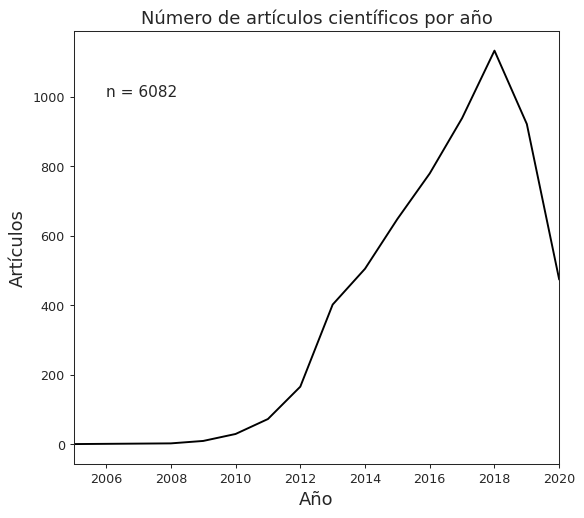

In [ ]:
# Figure
my_dpi = 92
sns.set_style("ticks")
fig = plt.figure(figsize=(550/my_dpi,500/my_dpi),dpi=my_dpi)

fontStyle = {'fontname':'Times New Roman'}
plt.plot(x, y, 'k')
plt.title('Número de artículos científicos por año',fontsize=14)#, **fontStyle)
plt.ylabel('Artículos',fontsize=14)#, **fontStyle)
plt.xlabel('Año',fontsize=14)#, **fontStyle)

# Text legend
s = len(data_df)
txt = "n = " + str(s)
plt.text(2006, 1000, txt, fontsize=12)

plt.subplots_adjust(wspace=0, hspace=1)
fig.tight_layout(pad=0) # If ignored, it's possible to define space between subplots
#plt.grid()
plt.xlim([2005, 2020])
plt.show()
fig.savefig('Papers_per_year',dpi=my_dpi * 10, bbox_inches='tight')

# Does the associated corpus behave like a vocabulary?

In [ ]:
# Directories
folder_path = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Metadata"
filenames = os.listdir(folder_path)
filenames = [x for x in filenames if ".ipynb_checkpoints" not in x]
filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
filenames

['Metadata_2005.csv',
 'Metadata_2008.csv',
 'Metadata_2009.csv',
 'Metadata_2010.csv',
 'Metadata_2011.csv',
 'Metadata_2012.csv',
 'Metadata_2013.csv',
 'Metadata_2014.csv',
 'Metadata_2015.csv',
 'Metadata_2016.csv',
 'Metadata_2017.csv',
 'Metadata_2018.csv',
 'Metadata_2019.csv',
 'Metadata_2020.csv',
 'Metadata_2021_raw.csv',
 'Metadata_2021.csv']

In [ ]:
path_results = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Figures/Vocabulary_size/"
vocabulary_size = []
for index in range(0,14):
  filename = folder_path + "/" + filenames[index]
  data_df = pd.read_csv(filename,index_col=0)
  cv = CountVectorizer()
  matrix = cv.fit_transform(data_df["abstract_without_stopwords"])
  x,y = matrix.shape
  vocabulary_size.append(y)
# Save object
open_file = open(path_results + "Vocabulary_wo_stopwords_per_year.pkl", "wb")
pickle.dump(vocabulary_size, open_file)
open_file.close()

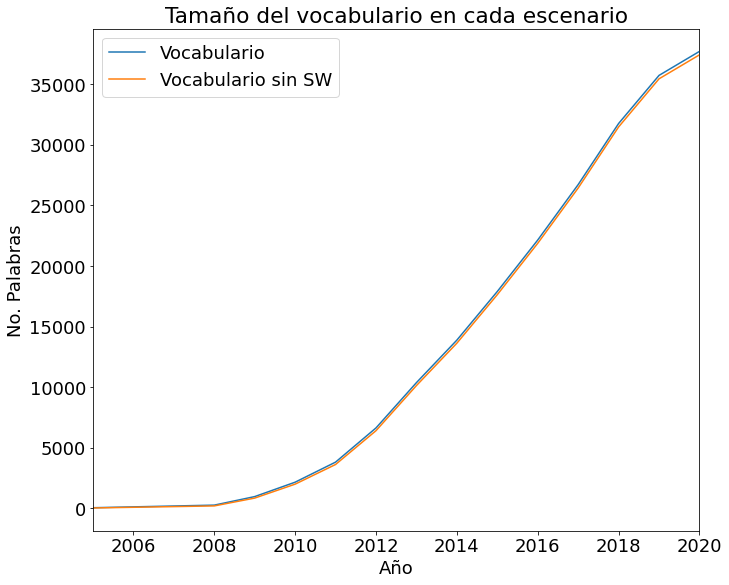

In [ ]:
# Figure vocabulary size
# Open clustering
path_corpus = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Figures/Vocabulary_size/Vocabulary_per_year.pkl"
path_corpus_wo_sw = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Figures/Vocabulary_size/Vocabulary_wo_stopwords_per_year.pkl"

year_list = [2005,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020]

with open(path_corpus, 'rb') as f:
    corpus = pickle.load(f)
#print(corpus)
with open(path_corpus_wo_sw, 'rb') as f:
    corpus_wo_sw = pickle.load(f)
#print(corpus_wo_sw)

dic = {"Año": year_list, "Vocabulario": corpus, "Vocabulario sin SW": corpus_wo_sw}
DF = pd.DataFrame(dic)
#print(DF)

DF.to_csv("Vocabulary_per_year.csv")
DF.set_index('Año', inplace=True)
my_dpi = 92 
plt.rcParams.update({'font.size': 18}) # must set in top
plot = DF.plot(figsize=(1000/my_dpi,850/my_dpi), xlim=(2005,2020),
            xlabel=('Año'), ylabel='No. Palabras',
            
            title='Tamaño del vocabulario en cada escenario')
fig = plot.get_figure()
fig.savefig("Vocabulary_per_year.png")


In [ ]:
# Data import(without SW)
data_file = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Metadata/Metadata_2020.csv"
data_df = pd.read_csv(data_file,index_col=0)

cv = CountVectorizer()
matrix = cv.fit_transform(data_df["abstract_without_stopwords"])

words = cv.get_feature_names()
freq = matrix.sum(axis=0).tolist()[0]
freq_matrix = list(zip(words, freq))    
vocabulary = pd.DataFrame(freq_matrix, columns=["Words","Frequency"])
vocabulary.sort_values(by="Frequency",axis=0,inplace=True,ascending=False)
vocabulary.reset_index(inplace=True,drop=True)
vocabulary

,Words,Frequency
0,brain,12238
1,connectivity,11197
2,functional,9838
3,networks,4866
4,data,4481
...,...,...
37394,nonoverlap,1
37395,nonorthographic,1
37396,nonorthogonality,1
37397,nonorthogonal,1


In [ ]:
# Get rank
rank = np.arange(1,37400,1)
vocabulary['Rank'] = rank
vocabulary = vocabulary[["Rank", "Frequency", "Words"]]
vocabulary

,Rank,Frequency,Words
0,1,12238,brain
1,2,11197,connectivity
2,3,9838,functional
3,4,4866,networks
4,5,4481,data
...,...,...,...
37394,37395,1,nonoverlap
37395,37396,1,nonorthographic
37396,37397,1,nonorthogonality
37397,37398,1,nonorthogonal


In [ ]:
frequency = np.array(vocabulary['Frequency'].values, dtype=float)
word_counts = frequency 
counter_of_counts = Counter(word_counts)
word_counts = np.array(list(counter_of_counts.keys()))
freq_of_word_counts = np.array(list(counter_of_counts.values()))

In [ ]:
x = np.log(word_counts)
y = np.log(freq_of_word_counts)

In [ ]:
# Linear regression y-data
y_reg1 = y[x <= 6]
y_reg1 = np.sort(y_reg1)[::-1]
x_reg1 = x[x <= 6]
x_reg1 = np.sort(x_reg1)

Estimated coefficients:
b_0 = 9.87865717827211            
b_1 = -1.6160384183986067


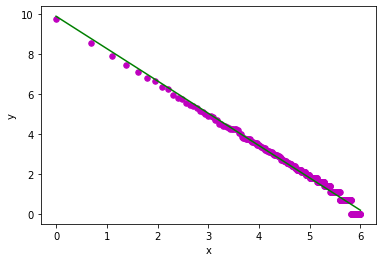

In [ ]:
def estimate_coef(x, y):
    # number of observations/points
    n = np.size(x)
 
    # mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)
 
    # calculating cross-deviation and deviation about x
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x
 
    # calculating regression coefficients
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x
 
    return (b_0, b_1)
 
def plot_regression_line(x, y, b):
    # plotting the actual points as scatter plot
    plt.scatter(x, y, color = "m",
               marker = "o", s = 30)
 
    # predicted response vector
    y_pred = b[0] + b[1]*x
 
    # plotting the regression line
    plt.plot(x, y_pred, color = "g")
 
    # putting labels
    plt.xlabel('x')
    plt.ylabel('y')
 
    # function to show plot
    plt.show()
 
def main():
    # observations / data
    x = x_reg1
    y = y_reg1
 
    # estimating coefficients
    b = estimate_coef(x, y)
    print("Estimated coefficients:\nb_0 = {}  \
          \nb_1 = {}".format(b[0], b[1]))
 
    # plotting regression line
    plot_regression_line(x, y, b)
 
if __name__ == "__main__":
    main()

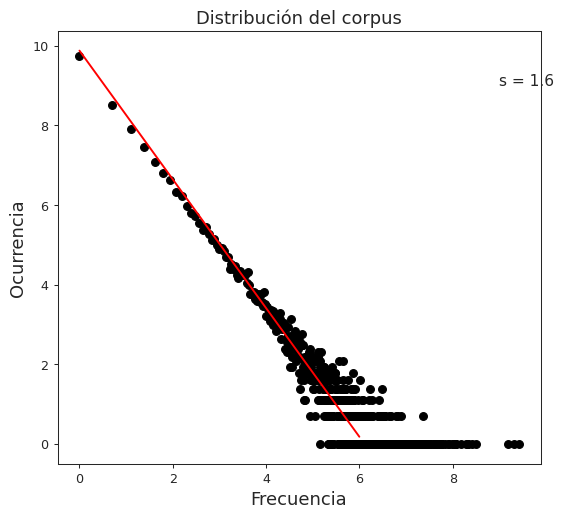

In [ ]:
my_dpi = 92
#plt.style.use('ggplot')
sns.set_style("ticks")
fig = plt.figure(figsize=(550/my_dpi,500/my_dpi),dpi=my_dpi)
x = np.log(word_counts)
y = np.log(freq_of_word_counts)
plt.scatter(x,y,c='k')
#plt.scatter(word_counts,freq_of_word_counts)
plt.xlabel('Frecuencia', fontsize=14)
plt.ylabel('Ocurrencia',fontsize=14)
plt.title('Distribución del corpus',fontsize=14)
#plt.title('Power law for word frequencies')

# Poner la línea (pendiente del Zipf's law)
x = x_reg1
y = y_reg1
b = estimate_coef(x, y) #estimating coefficients
#plot_regression_line(x, y, b)
y_pred = b[0] + b[1]*x # predicted response vector
plt.plot(x, y_pred, color = "r") # plotting the regression line

# Poner texto parámetro Zipf's Law
s = 1.60
txt = "s = " + str(s)
plt.text(9, 9, txt, fontsize=12)

# Poner las regiones
#axvspan(0, 6, facecolor='m', alpha=0.5)
#axvspan(6, 12, facecolor='g', alpha=0.5)

# Poner las topwords en la distribución

plt.subplots_adjust(wspace=0, hspace=1)
fig.tight_layout(pad=0)
plt.show()
fig.savefig('Zipf_distribution.png',dpi=my_dpi * 10, bbox_inches='tight')

# 2) Number of edges per year

In [ ]:
# Get number of edges per year -> total edges per experiment type
approach = "Clean_Variable"
path_results = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Figures/Edges_per_year/"
folder_path = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/" + approach + "/Graph_Results/Total_Lattices"
filenames = os.listdir(folder_path)
filenames = [x for x in filenames if ".ipynb_checkpoints" not in x]
filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
year_list = list(np.arange(2008,2021,1))

edges_list = []
for index in range(0,len(filenames)):
  filename = folder_path + "/" + filenames[index]
  with open(filename) as file:
    number_edges = file.readlines()
  edges_list.extend(number_edges)

DF = pd.DataFrame(edges_list, columns=["2-V"])
DF.to_csv(path_results + "2-V_total_edges.csv")

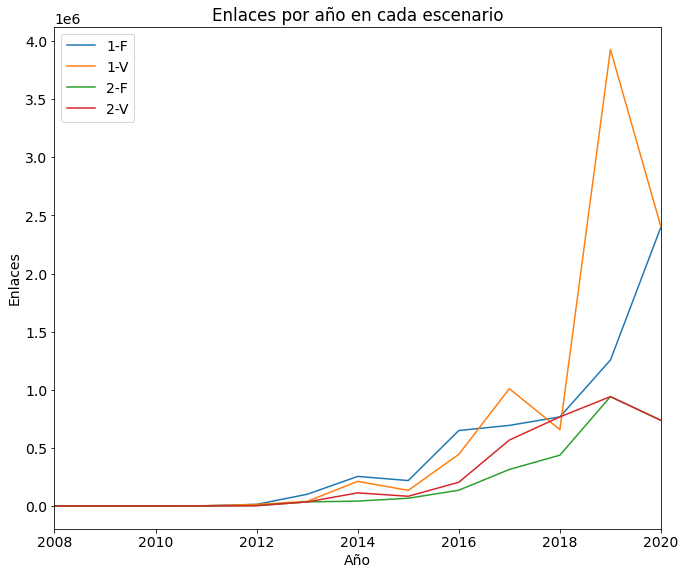

In [ ]:
# Figure
folder_path = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Figures/Edges_per_year"
filenames = os.listdir(folder_path)
filenames = [x for x in filenames if ".ipynb_checkpoints" not in x]
filenames = [x for x in filenames if ".png" not in x]
filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))

tempDF_list = []
for index in range(0,len(filenames)):
  filename = folder_path + "/" + filenames[index]
  DF = pd.read_csv(filename,index_col=0)
  tempDF_list.append(DF)
fullDF = pd.concat(tempDF_list, axis=1)
fullDF['year'] = year_list
fullDF.set_index('year', inplace=True)

fullDF.to_csv("Edges_per_year.csv")
my_dpi = 92 
plt.rcParams.update({'font.size': 14}) # must set in top
plot = fullDF.plot(figsize=(1000/my_dpi,850/my_dpi), xlim=(2008,2020),
            xlabel=('Año'), ylabel='Enlaces',
            title='Enlaces por año en cada escenario')
fig = plot.get_figure()
#fig.savefig("Edges_per_year.png")

# First attempt

In [ ]:
# Data Import
grafo = np.loadtxt("/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Connectomics/Year_2005/Results/With_Stopwords/JS_49_Topics_2005.txt", delimiter = ',')
#grafo = np.loadtxt("/content/drive/MyDrive/Papers/semantic_browser/NLP_Pubmed/Connectomics/Year_2020/Results/With_Stopwords/JS_49_Topics_2020.txt", delimiter = ',')
grafo[np.isnan(grafo)] = 0

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Wed Jul  7 12:23:46 2021

@author: jhona
"""
from igraph import *
import random
from tqdm import tqdm

#grafo = np.loadtxt("/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Connectomics/Year_2020/Results/With_Stopwords/JS_49_Topics_2020.txt", 
#                   delimiter = ',')

Threshold=[]
#Threshold=[np.percentile(grafo,4)]

for x in range(1,80,1): # Percentil de una distribución, aquí te quieres quedar con el 20%
    Threshold.append(np.percentile(grafo,x))

print(Threshold)

size= len(grafo)
dict_data = {}
for t in Threshold:
    Adj_matrix = np.zeros(np.shape(grafo))
    #for i in tqdm(range(0,size)):
    for i in range(0,size):
        for j in range(0,size):
            if grafo[i,j] < t:
                Adj_matrix[i,j] = 1
            else:
                Adj_matrix[i,j] = 0
    np.fill_diagonal(Adj_matrix,0) # Diagonal a ceros
    dict_data[t]= Adj_matrix # De cada umbral, sale un grafo. Entonces, tienes 20 grafos -> dict

#print(len(dict_data))

percolation = []
giant_comp_list = []
for key,value in dict_data.items(): # Identifica el componente gigante, y hace la evaluación de nodos en el grafo binarizado / total de nodos en el grafo original
    Z = Graph.Adjacency(value.astype(bool).tolist(), mode=ADJ_UNDIRECTED) 
    cl = Z.components()
    lcc = cl.giant()
    #print(lcc.vcount())
    giant_comp = lcc.vcount()
    per = lcc.vcount() / size
    
    giant_comp_list.append(giant_comp)
    percolation.append(per)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


TypeError: ignored

In [ ]:
# Guardar percentiles
percentile_df = pd.DataFrame({'giant_component': giant_comp_list,
                   'percolation': percolation})
percentile_df.index += 1 

PATH = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Connectomics/Year_2008/Results/Without_Stopwords/"
topics = '_05_Topics'

percentile_df.to_csv(PATH + 'Percentiles' + topics + '.csv')

percentile_df

,giant_component,percolation
1,1,0.25
2,1,0.25
3,1,0.25
4,1,0.25
5,1,0.25
6,1,0.25
7,1,0.25
8,1,0.25
9,2,0.50
10,2,0.50


In [ ]:
# Figura percentiles
pers = [x for x in range(20)]
plt.figure(figsize=(16,12))
plt.scatter(pers[1:],percolation)

#grafo.to_numpy()
#g = Graph.Adjacency((grafo > 0).tolist())
#
# Add edge weights and node labels.
#g.es['weight'] = grafo[grafo.nonzero()]
#g.vs['label'] = node_names  # or a.index/a.columns
plt.grid()
plt.show()

In [ ]:
# Grafo del percentil óptimo

metadata = pd.read_csv("/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Connectomics/Year_2008/Metadata/Metadata_2008.csv", header= 0, index_col=0)

Threshold=[np.percentile(grafo,74)]

size= len(grafo)
dict_data = {}
for t in Threshold:
    Adj_matrix = np.zeros(np.shape(grafo))
    #for i in tqdm(range(0,size)):
    for i in range(0,size):
        for j in range(0,size):
            if grafo[i,j] < t:
                Adj_matrix[i,j] = 1
            else:
                Adj_matrix[i,j] = 0
    np.fill_diagonal(Adj_matrix,0) # Diagonal a ceros
    dict_data[t]= Adj_matrix # De cada umbral, sale un grafo. Entonces, tienes 20 grafos -> dict

percolation = []
node_names = metadata['pubmed_id'].to_numpy() # nombre de los nodos (nodo = artículo)

for key,value in dict_data.items(): # Identifica el componente gigante, y hace la evaluación de nodos en el grafo binarizado / total de nodos en el grafo original
    Z = Graph.Adjacency(value.astype(bool).tolist(), mode=ADJ_UNDIRECTED) 
    Z.vs['name']=node_names
    cl = Z.components()
    lcc = cl.giant()
    print(lcc.vcount())
    per = lcc.vcount() / size
    print(per)


4
1.0


In [ ]:
lattice_number = Z.ecount() # número aristas

comm_eigen = Z.community_leading_eigenvector() 
comm_eigen_len = len(comm_eigen) # número comunidades eigen
comm_eigen_mod = comm_eigen.modularity # modularidad eigen

comm_info = Z.community_infomap()
comm_info_len = len(comm_info) # número comunidades infomap
comm_info_mod = comm_info.modularity # modularidad infomap

comm_prop = Z.community_label_propagation()
comm_prop_len = len(comm_prop) # número comunidades prop
comm_prop_mod = comm_prop.modularity # modularidad prop

comm_multi = Z.community_multilevel()
comm_multi_len = len(comm_multi) # número comunidades multi
comm_multi_mod = comm_multi.modularity # modularidad multi

In [ ]:
df = pd.DataFrame({'community': [comm_eigen_len, comm_info_len, comm_prop_len, comm_multi_len],
                   'modularity': [comm_eigen_mod, comm_info_mod, comm_prop_mod, comm_multi_mod]},
                  index=['eigenvector', 'infomap', 'propagation', 'multilevel'])
df

,community,modularity
eigenvector,1,0.0
infomap,1,0.0
propagation,1,0.0
multilevel,2,0.0


In [ ]:
# Guardar resultados 
PATH = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Connectomics/Year_2008/Results/Without_Stopwords/Results_05_Topics/"

topics = '_05_Topics'

# 1. Matriz de adyacencia
np.savetxt(PATH + 'Adj_Matrix' + topics + '.txt', Adj_matrix, fmt = '%d', delimiter = ',')
# 2. Objeto grafo
save(Z, PATH + 'Graph' + topics + '.gml') 
# 3. Resultados métodos comunidades
df.to_csv(PATH + 'Methods_Results' + topics + '.csv')
# 4. Núm. aristas
with open(PATH + 'Total_Lattices' + topics + '.txt', 'w') as f:
  f.write(str(lattice_number))


In [ ]:
# Graficar grafo
from igraph import *
from igraph import arpack_options

#pal = drawing.colors.ClusterColoringPalette(len(Control_comm))
#Z.vs['color'] = pal.get_many(Control_comm.membership)
#plot(Z)

    
layout = Z.layout('fr')
pal = drawing.colors.ClusterColoringPalette(len(comm_multi))
Z.vs['color'] = pal.get_many(comm_multi.membership)
ig.plot(Z,'Graph_Infomap.svg',layout = layout)


In [ ]:
# Código de Bryan
import numpy as np
import matplotlib.pyplot as plt
from igraph import *
import pandas as pd
from tqdm import tqdm
import os
from igraph import arpack_options
import timeit
tic=timeit.default_timer()

JS_matrix = np.loadtxt('C:/Users/jhona/Documents/Connectomic Topics/Connectomics/Year_2017/Results/Without_Stopwords/JS_41_Topics_2017_wostopwords.txt', delimiter = ',')
JS_matrix[np.isnan(JS_matrix)] = 0
PATH = 'C:/Users/jhona/Documents/Connectomic Topics/Connectomics/Year_2017/Results/Without_Stopwords/'

metadata = pd.read_csv('C:/Users/jhona/Documents/Connectomic Topics/Connectomics/Year_2017/Metadata/Metadata_2017.csv', header= 0, index_col=0)

Metrica = 'Connectomics_41'

siglas = 'JS'



# Matrices Binarias
Threshold_Community = 150 # Umbral de artículos máximos para volver a hacer el análisis de comunidades
Threshold_Genes= 10 # Umbral de artículos mínimos por comunidad

Threshold=[]

for x in range(1,20,1):
    Threshold.append(np.percentile(JS_matrix,x)) 

# np.percentile(matrix, x) siendo x el #percentile

Q_List = np.zeros((len(Threshold),3)) # Sacar modularidad de las comunidades
# col 0 = umbral, col 1 = modularidad de un método, col 2 = modularidad de otro método
Q_List[:,0]=Threshold

size= len(JS_matrix)
dict_data = {}
for t in Threshold:
    Adj_matrix = np.zeros(np.shape(JS_matrix))
    for i in tqdm(range(0,size)):
        for j in range(0,size):
            if JS_matrix[i,j] > t:
                Adj_matrix[i,j] = 0 # Supera umbral? valor=0
            else:
                Adj_matrix[i,j] = 1 # valor=1
    # matriz JS (divergencia) -> matriz adyacencia

    np.fill_diagonal(Adj_matrix,0) # Diagonal a ceros
        # No nos interesan los autoloops (el vector se parece a sí mismo)
    dict_data[t]= Adj_matrix
    print(dict_data)
    path = PATH + Metrica + " communities/" + "Percentile = " + str(t)
    print(path)

    if not os.path.exists(path):
        os.makedirs(path)

    print('Guardando Matriz de Adyacencia')
    np.savetxt(PATH + Metrica + ' communities/'+ str(Metrica)+'_binarized_P= ' + str(t) + '.txt', Adj_matrix, fmt = '%d', delimiter = ',')

# Creación de grafos
comunidades_infomap = []
com_eigen=[]
comunidades_infomap = []
DegreeThreshold=[]
node_names = metadata['pubmed_id'].to_numpy() # nombre de los nodos (nodo = artículo)
Comuni_info_3 = []
Comuni_Eigen_3 = []

i=0
arpack_options.maxiter=300000
for key,value in dict_data.items():
    print(f'Creando grafo para umbral {key}')
    Z = Graph.Adjacency(value.astype(bool).tolist(), mode=ADJ_UNDIRECTED)
    print('Grafo creado')
    print(f'Cargando nombres de los nodos del Grafo: {key}')
    Z.vs['name']=node_names
    to_delete_ids = [v.index for v in Z.vs if v.degree() < 1] # Eliminar nodos aislados
    Z.delete_vertices(to_delete_ids)
    d=Z.indegree() # Calcular el grado de todos los nodos
    print('Guardando grafo')
    save(Z, PATH + Metrica  + ' communities/'+str(Metrica)+'_P=' + str(key) + 'graph.gml') # Guardar objeto grafo en su carpeta correspondiente
    print('Grafo Guardado')
    print('El grado del grafo ha sido calculado')
    DegreeThreshold.append(d) # Guardar el grado de cada nodo en una lista
    print('Calculando Infomap')
    I=Z.community_infomap() # OJO AQUÍ
    print('Infomap calculado')
    print('Calculando los eigenvectores')
    Eigen=Z.community_leading_eigenvector() # OJO AQUÍ
    print('Eigenvectores calculados')
    comunidades_infomap.append(len(I)) #número de comunidades para infomap
    com_eigen.append(len(Eigen)) #número de comunidades para eigenvectores
    print(f'Modularidad Infomap primer vuelta: {I.modularity}')
    # Nivel de aleatoriedad del grafo: si tiende a 0, las comunidades no son óptimas
    # Evaluación para medir la calidad de la comunidad (conexiones intra e inter del grafo)
    print(f'Modularidad Eigenvector primer vuelta: {Eigen.modularity}')
    Q_List[i,1]=I.modularity
    Q_List[i,2]=Eigen.modularity
    print(f'Modularidad de JS-Eigen: {Q_List[i,2]} \nModularidad de Info: {Q_List[i,1]} del percentile {Q_List[i,0]} - {key}')
    

    print(f'--------------------T={key}----------------')
    print(f'{com_eigen} Comunidades de Eigen')
    print(f'{len(I)} Comunidades de Infomap')
    for z in range(0,len(I)):
        #print(f'----------------Comunidad {z} Longitud {len(I[z])}-------------')
        Gnames3=[]
        Comuni_info_3.append(len(I[z]))
        for j in I[z]:
            Gnames3.append(Z.vs[j]['name'])
        if len(I[z])>= Threshold_Genes:
            np.savetxt(PATH + Metrica +' communities/Percentile = '+str(key)+'/'+ str(siglas) + 'I' + str(z) + '-' + str(len(I[z])) + '.txt', Gnames3, delimiter = ',', fmt='%s')
            # La I es por el tipo de análisis (Infomap)
    for a in range(0,len(Eigen)):
        #print(f'----------------Comunidad {a} Longitud {len(Eigen[a])}-------------')
        Eigennames3=[]
        Comuni_Eigen_3.append(len(Eigen[a]))
        for b in Eigen[a]:
            Eigennames3.append(Z.vs[b]['name'])
        if len(Eigen[a]) >= Threshold_Genes:
            np.savetxt(PATH + Metrica +' communities/Percentile = '+str(key)+'/'+ str(siglas) + 'E' +  str(a) + '-' + str(len(Eigen[a])) + '.txt', Eigennames3, delimiter = ',', fmt='%s')
    
    # Plot del grafo
    """
    layout = Z.layout('fr')
    pal = drawing.colors.ClusterColoringPalette(len(I))
    Z.vs['color'] = pal.get_many(I.membership)
    ig.plot(Z, PATH + Metrica + ' communities/Percentile = ' + str(key) + ' Graph_Infomap.svg',layout = layout)

    Z.vs['color']= 0
    pal_eigen = drawing.colors.ClusterColoringPalette(len(Eigen))
    Z.vs['color'] = pal.get_many(Eigen.membership)
    ig.plot(Z,PATH + Metrica + ' communities/Percentile = ' + str(key) + ' Graph_Eigen.svg',layout = layout)
    """
    # Plot de las gráficas del grado
    plt.hist(DegreeThreshold[i], color=['green'])
    plt.ylabel("Frequency")
    plt.title('Connectomics Percentile = ' + str(key) + ' Degree Graph')
    plt.savefig(PATH + Metrica + ' communities/Percentile = ' + str(key) + ' Degree Graph.png')
    plt.savefig(PATH + Metrica + ' communities/Percentile = ' + str(key) + ' Degree Graph.svg')
    i+=1
    plt.clf()
    
# Plot del número de comunidades    
plt.scatter(Threshold,com_eigen, color= 'b', label='Eigen Spectrum')
plt.scatter(Threshold,comunidades_infomap, color = 'r', label= 'Infomap')
for i, txt in enumerate(com_eigen):
    plt.annotate(txt, (Threshold[i]+0.01, com_eigen[i])) # Texto para el punto, donde el punto es la longitud del número de comunidades

for i, txt in enumerate(comunidades_infomap):
    plt.annotate(txt, (Threshold[i], comunidades_infomap[i]))
plt.legend()
plt.xlabel('Percentile')
plt.ylabel('No. de comunidades')
plt.title('Comunidades de Connectomics')
plt.savefig(PATH + Metrica + ' communities/'+str(Metrica) + ' Communities.png')
plt.savefig(PATH + Metrica + ' communities/'+str(Metrica) + ' Communities.svg')
np.savetxt('Modularidades.txt', Q_List , fmt='%f', delimiter= ',')


toc=timeit.default_timer()

print(f'Tiempo trasncurrido:{(toc - tic)/60} minutos')

# 3) Modularity and no. communities per year

In [ ]:
SF_DF = pd.read_csv("/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Stop_Fixed/Comm_Analysis_Results/Comm&Modularity_per_year.csv", index_col=0)
SV_DF = pd.read_csv("/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Stop_Variable/Comm_Analysis_Results/Comm&Modularity_per_year.csv", index_col=0)
CF_DF = pd.read_csv("/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Fixed/Comm_Analysis_Results/Comm&Modularity_per_year.csv", index_col=0)
CV_DF = pd.read_csv("/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/Comm&Modularity_per_year.csv", index_col=0)

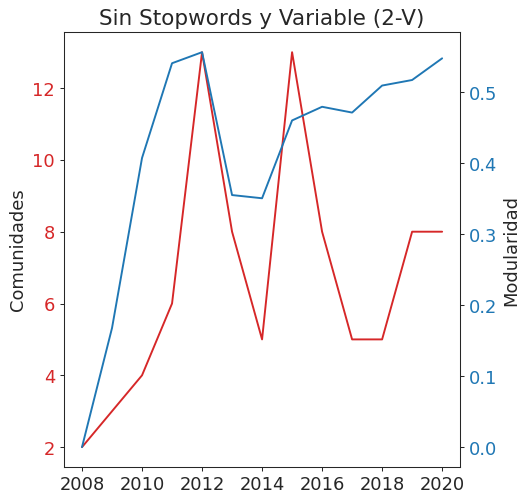

In [ ]:
path_results = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Figures/Comm&Modularity_per_year/"

x = CV_DF['year'] # Año
y = CV_DF['communities'] # Comunidades
z = CV_DF['modularity'] # Modularidad

my_dpi = 92
sns.set_style("ticks")
fig, ax1 = plt.subplots(figsize=(550/my_dpi,500/my_dpi),dpi=my_dpi)
#ax1.plot(x,y)
#plt.plot(x,z)
#plt.show()

# dos escalas y en una sola figura
color = 'tab:red'
ax1.plot(x,y, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylabel('Comunidades')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.plot(x, z, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel('Modularidad')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Sin Stopwords y Variable (2-V)')

plt.show()
fig.savefig(path_results + 'Comm&Modularity_2-V',dpi=my_dpi * 10, bbox_inches='tight')

In [ ]:
# Get mean modularity of each experiment type
print(CV_DF['modularity'].mean())


0.41271329561623066


# First attempt

In [ ]:
stop_fixed = np.loadtxt("/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Stop_Fixed_Comm_Modularity.txt", delimiter = '\t')
stop_fixed

array([[2.0200e+03, 8.0000e+00, 4.5920e-01],
       [2.0190e+03, 6.0000e+00, 5.0310e-01],
       [2.0180e+03, 6.0000e+00, 4.9860e-01],
       [2.0170e+03, 5.0000e+00, 4.1880e-01],
       [2.0160e+03, 5.0000e+00, 4.1600e-01],
       [2.0150e+03, 6.0000e+00, 4.5860e-01],
       [2.0140e+03, 6.0000e+00, 2.9410e-01],
       [2.0130e+03, 4.0000e+00, 1.5750e-01],
       [2.0120e+03, 4.0000e+00, 2.0610e-01],
       [2.0110e+03, 3.0000e+00, 2.7930e-01],
       [2.0100e+03, 5.0000e+00, 4.4770e-01],
       [2.0090e+03, 3.0000e+00, 7.1428e-02],
       [2.0080e+03, 0.0000e+00, 0.0000e+00]])

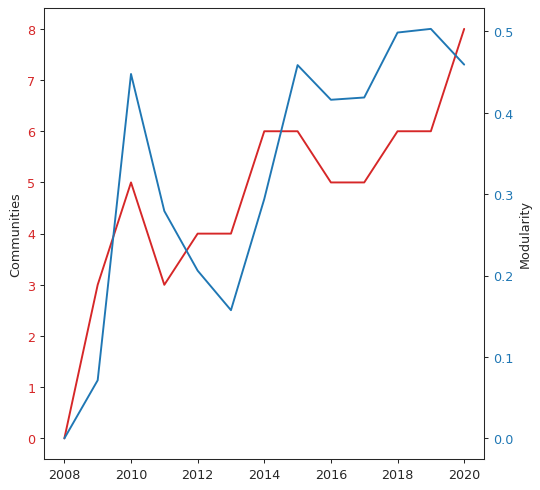

In [ ]:
# Stop-Fixed
x = stop_fixed[:,0] # Año
y = stop_fixed[:,1] # Comunidades
z = stop_fixed[:,2] # Modularidad

my_dpi = 92
sns.set_style("ticks")
fig, ax1 = plt.subplots(figsize=(550/my_dpi,500/my_dpi),dpi=my_dpi)
#ax1.plot(x,y)
#plt.plot(x,z)
#plt.show()

# dos escalas y en una sola figura
color = 'tab:red'
ax1.plot(x,y, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylabel('Communities')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.plot(x, z, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel('Modularity')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()
fig.savefig('Stop-Fixed',dpi=my_dpi * 10, bbox_inches='tight')

In [ ]:
clean_fixed = np.loadtxt("/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Clean_Fixed_Comm_Modularity.txt", delimiter = '\t')
clean_fixed

array([[2.0200e+03, 7.0000e+00, 5.4330e-01],
       [2.0190e+03, 7.0000e+00, 5.2440e-01],
       [2.0180e+03, 6.0000e+00, 5.0020e-01],
       [2.0170e+03, 9.0000e+00, 5.1450e-01],
       [2.0160e+03, 1.3000e+01, 5.1250e-01],
       [2.0150e+03, 1.3000e+01, 5.2040e-01],
       [2.0140e+03, 1.8000e+01, 4.7660e-01],
       [2.0130e+03, 8.0000e+00, 3.5570e-01],
       [2.0120e+03, 8.0000e+00, 4.3300e-01],
       [2.0110e+03, 6.0000e+00, 4.9300e-01],
       [2.0100e+03, 4.0000e+00, 3.4046e-01],
       [2.0090e+03, 3.0000e+00, 4.1600e-02],
       [2.0080e+03, 0.0000e+00, 0.0000e+00]])

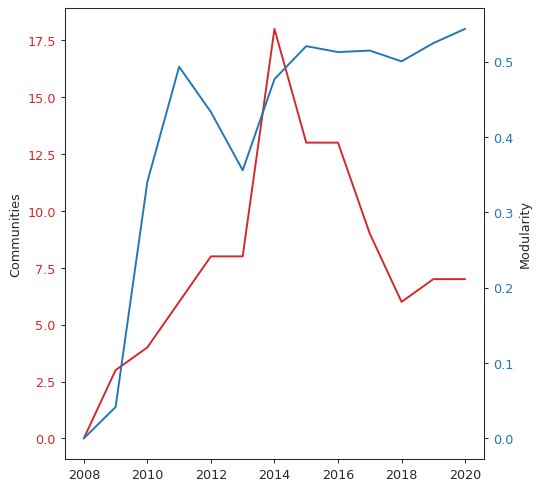

In [ ]:
# Clean-Fixed
x = clean_fixed[:,0] # Año
y = clean_fixed[:,1] # Comunidades
z = clean_fixed[:,2] # Modularidad

my_dpi = 92
sns.set_style("ticks")
fig, ax1 = plt.subplots(figsize=(550/my_dpi,500/my_dpi),dpi=my_dpi)
color = 'tab:red'
ax1.plot(x,y, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylabel('Communities')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:blue'
ax2.plot(x, z, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel('Modularity')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()
fig.savefig('Clean-Fixed',dpi=my_dpi * 10, bbox_inches='tight')

In [ ]:
stop_variable = np.loadtxt("/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Stop_Variable_Comm_Modularity.txt", delimiter = '\t')
stop_variable

array([[2.0200e+03, 8.0000e+00, 4.5920e-01],
       [2.0190e+03, 4.0000e+00, 3.4530e-01],
       [2.0180e+03, 7.0000e+00, 4.9550e-01],
       [2.0170e+03, 4.0000e+00, 3.7520e-01],
       [2.0160e+03, 4.0000e+00, 4.4650e-01],
       [2.0150e+03, 7.0000e+00, 5.1660e-01],
       [2.0140e+03, 4.0000e+00, 3.3360e-01],
       [2.0130e+03, 9.0000e+00, 3.7800e-01],
       [2.0120e+03, 3.0000e+00, 2.6300e-01],
       [2.0110e+03, 5.0000e+00, 3.1510e-01],
       [2.0100e+03, 4.0000e+00, 3.3020e-01],
       [2.0090e+03, 2.0000e+00, 4.9585e-02],
       [2.0080e+03, 2.0000e+00, 1.6660e-01]])

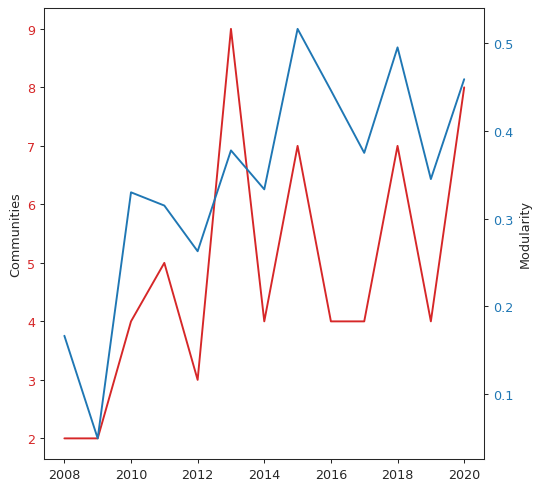

In [ ]:
# Stop-Variable
x = stop_variable[:,0] # Año
y = stop_variable[:,1] # Comunidades
z = stop_variable[:,2] # Modularidad

my_dpi = 92
sns.set_style("ticks")
fig, ax1 = plt.subplots(figsize=(550/my_dpi,500/my_dpi),dpi=my_dpi)
color = 'tab:red'
ax1.plot(x,y, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylabel('Communities')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:blue'
ax2.plot(x, z, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel('Modularity')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()
fig.savefig('Stop-Variable',dpi=my_dpi * 10, bbox_inches='tight')

In [ ]:
clean_variable = np.loadtxt("/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Clean_Variable_Comm_Modularity.txt", delimiter = '\t')
clean_variable

array([[2.020e+03, 7.000e+00, 5.433e-01],
       [2.019e+03, 7.000e+00, 5.173e-01],
       [2.018e+03, 5.000e+00, 5.092e-01],
       [2.017e+03, 2.700e+01, 4.633e-01],
       [2.016e+03, 9.000e+00, 4.884e-01],
       [2.015e+03, 1.400e+01, 4.672e-01],
       [2.014e+03, 4.000e+00, 3.507e-01],
       [2.013e+03, 8.000e+00, 3.557e-01],
       [2.012e+03, 1.100e+01, 5.557e-01],
       [2.011e+03, 6.000e+00, 5.359e-01],
       [2.010e+03, 4.000e+00, 4.075e-01],
       [2.009e+03, 3.000e+00, 1.609e-01],
       [2.008e+03, 0.000e+00, 0.000e+00]])

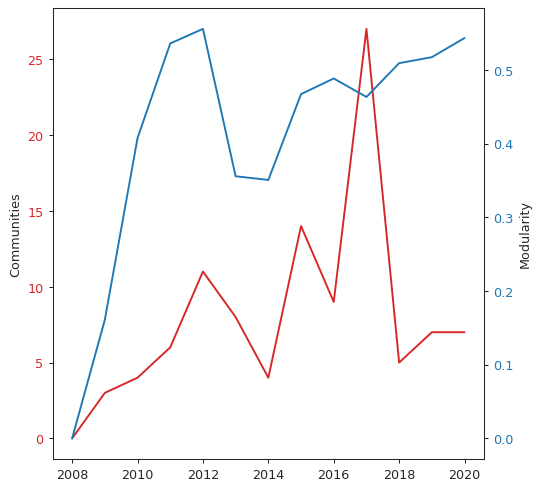

In [ ]:
# Clean-Variable
x = clean_variable[:,0] # Año
y = clean_variable[:,1] # Comunidades
z = clean_variable[:,2] # Modularidad

my_dpi = 92
sns.set_style("ticks")
fig, ax1 = plt.subplots(figsize=(550/my_dpi,500/my_dpi),dpi=my_dpi)
color = 'tab:red'
ax1.plot(x,y, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylabel('Communities')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:blue'
ax2.plot(x, z, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel('Modularity')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()
fig.savefig('Clean-Variable',dpi=my_dpi * 10, bbox_inches='tight')

# 4) New articles per year

In [ ]:
# import data
New_Articles = pd.read_csv("/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Figures/New_articles_per_year/PubMed_Timeline_Results_by_Year.csv")
New_Articles

,"Search query: (connectomics) AND ((""2005""[Date - Publication] : ""2020""[Date - Publication]))"
Year,Count
2021,175
2020,1497
2019,1472
2018,1269
2017,1074
2016,890
2015,693
2014,570
2013,404


In [ ]:
# Directories
path_diff = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/New_Articles"
diff_filenames = os.listdir(folder_path)
diff_filenames = [x for x in diff_filenames if ".ipynb_checkpoints" not in x]
diff_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
diff_filenames

['2008_to_2009_Difference.pkl',
 '2009_to_2010_Difference.pkl',
 '2010_to_2011_Difference.pkl',
 '2011_to_2012_Difference.pkl',
 '2012_to_2013_Difference.pkl',
 '2013_to_2014_Difference.pkl',
 '2014_to_2015_Difference.pkl',
 '2015_to_2016_Difference.pkl',
 '2016_to_2017_Difference.pkl',
 '2017_to_2018_Difference.pkl',
 '2018_to_2019_Difference.pkl',
 '2019_to_2020_Difference.pkl']

In [ ]:
year_list = np.arange(2008,2021,1)

diff_list = []
for index in range(0,len(diff_filenames)):
  year = year_list[index]
  # Load difference
  diff_filename = diff_filenames[index]
  filename = path_diff + "/" + diff_filename
  with open(filename, 'rb') as f:
    diff = pickle.load(f)
  new = len(diff)
  diff_list.append(new)
diff_list

[10, 30, 73, 166, 402, 505, 648, 779, 938, 1132, 921, 474]

# 5) Community Analysis

# 1.- Multilevel communities for each graph

In [ ]:
# Directories
folder_path = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Graph_Results/Graphs"
graph_filenames = os.listdir(folder_path)
graph_filenames = [x for x in graph_filenames if ".ipynb_checkpoints" not in x]
graph_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
graph_filenames

['2008_Graph_05_Topics.gml',
 '2009_Graph_07_Topics.gml',
 '2010_Graph_21_Topics.gml',
 '2011_Graph_23_Topics.gml',
 '2012_Graph_45_Topics.gml',
 '2013_Graph_41_Topics.gml',
 '2014_Graph_43_Topics.gml',
 '2015_Graph_49_Topics.gml',
 '2016_Graph_43_Topics.gml',
 '2017_Graph_29_Topics.gml',
 '2018_Graph_47_Topics.gml',
 '2019_Graph_45_Topics.gml',
 '2020_Graph_41_Topics.gml']

In [ ]:
year_list = [2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020]

In [ ]:
Path_clusterings = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/Clusterings/"
Path_subgraph_list = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/Subgraph_Lists/"
Path_nodes_list = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/Nodes_IDs_Lists/"
Path_membership_vectors = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/Membership_Vectors/"

counter = 0
for x in graph_filenames:
  filename = folder_path + "/" + x # Graph path
  print(x)
  g = Graph.Load(filename, format='gml') # Reads graph
  clustering = g.community_multilevel() # Applies community method
  #summary = clustering.summary()
  #print(summary)

  # Save clustering
  year = year_list[counter]
  print(year)
  open_file = open(Path_clusterings + str(year) + "_Clustering.pkl", "wb")
  pickle.dump(clustering, open_file)
  open_file.close()

  subgraph_list = []
  name_list = []
  membership_vector = []
  for index in range(0,len(clustering)):
    cluster = clustering.subgraph(index) # Gets cluster as subgraph
    subgraph_list.append(cluster) # Subgraph / row
    name_list.append(cluster.vs['name']) # Community names / row
    membership = [index] * len(name_list[index]) # Community index occurrence
    membership_vector.append(membership) # Community occurrence / row
  
  # Save objects
  # Names
  open_file = open(Path_nodes_list + str(year) + "_Nodes_IDs_List.pkl", "wb")
  pickle.dump(name_list, open_file)
  open_file.close()
  # Membership
  open_file = open(Path_membership_vectors + str(year) + "_Membership_Vector.pkl", "wb")
  pickle.dump(membership_vector, open_file)
  open_file.close()
  # Subgraphs
  open_file = open(Path_subgraph_list + str(year) + "_Subgraph_List.pkl", "wb")
  pickle.dump(subgraph_list, open_file)
  open_file.close()

  counter = counter + 1


2008_Graph_05_Topics.gml
2008
2009_Graph_07_Topics.gml
2009
2010_Graph_21_Topics.gml
2010
2011_Graph_23_Topics.gml
2011
2012_Graph_45_Topics.gml
2012
2013_Graph_41_Topics.gml
2013
2014_Graph_43_Topics.gml
2014
2015_Graph_49_Topics.gml
2015
2016_Graph_43_Topics.gml
2016
2017_Graph_29_Topics.gml
2017
2018_Graph_47_Topics.gml
2018
2019_Graph_45_Topics.gml
2019
2020_Graph_41_Topics.gml
2020


In [ ]:
# Open clustering
with open('/content/2008_Clustering.pkl', 'rb') as f:
    clustering = pickle.load(f)
type(clustering)
clustering.summary

<bound method Clustering.summary of <igraph.clustering.VertexClustering object at 0x7f337fe1f4d0>>

# First attempt

In [ ]:
# Load graph
graph_file = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Stop_Fixed/Graph_Results/Graphs/2020_Graph_49_Topics.gml"
g = Graph.Load(graph_file, format='gml')

In [ ]:
print(len(g.vs['name'])) # number of nodes

6082


In [ ]:
g.vs['name']

[29784759.0,
 31256864.0,
 30268923.0,
 31703899.0,
 29962025.0,
 26391203.0,
 25355371.0,
 30014279.0,
 28917698.0,
 31467291.0,
 29999567.0,
 30501515.0,
 25432770.0,
 25527636.0,
 27865786.0,
 29675882.0,
 30079754.0,
 26809184.0,
 29520641.0,
 28232122.0,
 30332613.0,
 31806491.0,
 28859565.0,
 27497220.0,
 30483069.0,
 29897426.0,
 26228398.0,
 30889276.0,
 30201841.0,
 24875392.0,
 26921715.0,
 30368037.0,
 30479137.0,
 29779726.0,
 25810900.0,
 26212146.0,
 31055238.0,
 31685648.0,
 26468195.0,
 30988201.0,
 31292699.0,
 31294921.0,
 30088220.0,
 28456573.0,
 28988973.0,
 29789379.0,
 29464318.0,
 32079409.0,
 30328104.0,
 30663853.0,
 28033531.0,
 26671942.0,
 25928186.0,
 31405905.0,
 28990258.0,
 26170004.0,
 31491813.0,
 27228241.0,
 30004604.0,
 31115127.0,
 28684174.0,
 31127193.0,
 30099461.0,
 29208230.0,
 30530318.0,
 30106377.0,
 29931116.0,
 30225830.0,
 29579713.0,
 28884073.0,
 28971010.0,
 31276262.0,
 24016532.0,
 32735580.0,
 30980900.0,
 25444171.0,
 28510745.0,

In [ ]:
clusters = g.community_multilevel()
summary = clusters.summary()
print(summary)

# Save clustering
#open_file = open("2020_Stop_Fixed_Clustering.pkl", "wb")
#pickle.dump(clusters, open_file)
#open_file.close()

Clustering with 6082 elements and 5 clusters


In [ ]:
subgraph_list = []
name_list = []
membership_vector = []
betweeness_list = []
for index in range(0,len(clusters)):
  cluster = clusters.subgraph(index) # Gets cluster as subgraph
  subgraph_list.append(cluster) # Subgraph / row
  name_list.append(cluster.vs['name']) # Community names / row
  membership = [index] * len(name_list[index]) # Community index occurrence
  membership_vector.append(membership) # Community occurrence / row

# 2.- Get nodes that correspond to new articles

In [ ]:
# Directories
folder_path = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/Nodes_IDs_Lists"
nodes_filenames = os.listdir(folder_path)
nodes_filenames = [x for x in nodes_filenames if ".ipynb_checkpoints" not in x]
nodes_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
nodes_filenames

['2008_Nodes_IDs_List.pkl',
 '2009_Nodes_IDs_List.pkl',
 '2010_Nodes_IDs_List.pkl',
 '2011_Nodes_IDs_List.pkl',
 '2012_Nodes_IDs_List.pkl',
 '2013_Nodes_IDs_List.pkl',
 '2014_Nodes_IDs_List.pkl',
 '2015_Nodes_IDs_List.pkl',
 '2016_Nodes_IDs_List.pkl',
 '2017_Nodes_IDs_List.pkl',
 '2018_Nodes_IDs_List.pkl',
 '2019_Nodes_IDs_List.pkl',
 '2020_Nodes_IDs_List.pkl']

In [ ]:
year_list = [2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020]

In [ ]:
def flatten(t):
    return [item for sublist in t for item in sublist]

In [ ]:
Path_difference = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/New_Articles/"

for index in range(0,len(nodes_filenames)):
  filename_old = folder_path + "/" + nodes_filenames[index] # Filename first year
  with open(filename_old, 'rb') as f: # Opens first filename
    old_name_list = pickle.load(f)
  
  new = index + 1
  filename_new = folder_path + "/" + nodes_filenames[new] # Filename second year
  with open(filename_new, 'rb') as f: # Opens second filename
    new_name_list = pickle.load(f)

  # Get name vectors
  old_names_vector = flatten(old_name_list)
  new_names_vector = flatten(new_name_list)

  # Remove nodes from new list that do not appear in old list
  difference = list(set(new_names_vector) - set(old_names_vector))
  #print(len(new_names_vector) - len(old_names_vector))
  print(len(difference))
  diff = np.array(difference,dtype=int)
  diff = list(diff)
  #print(diff)
  
  # Save difference
  old_year = year_list[index]
  new_year = year_list[new]

  open_file = open(Path_difference + str(old_year) + "_to_" + str(new_year) + "_Difference.pkl", "wb")
  pickle.dump(diff, open_file)
  open_file.close()

  # Truena en el último año pero eso no se necesita

  
  

10
30
73
166
402
505
648
779
938
1132
921
474


IndexError: ignored

# Checking belonging between sets condition

In [ ]:
def flatten(t):
    return [item for sublist in t for item in sublist]

In [ ]:
# Graph
graph_path = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Stop_Fixed/Graph_Results/Graphs/2020_Graph_49_Topics.gml"
g = Graph.Load(graph_path, format='gml')
names_in_graph = g.vs['name']

In [ ]:
# Nodes IDs obtained in part 1
nodes_path = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Stop_Fixed/Comm_Analysis_Results/Nodes_IDs_Lists/2020_Nodes_IDs_List.pkl"
with open(nodes_path, 'rb') as f:
    name_list = pickle.load(f)
names_in_list = flatten(name_list)

In [ ]:
names_in_list in names_in_graph
# We got the names from the clustering, not the graph

False

In [ ]:
# Example
list_1 = [1,2,3,4,5,6]
list_2 = list(range(0,25,1))
list_1 in list_2 # This condition is WRONG

False

In [ ]:
A = set(list_1)
B = set(list_2)
A.issubset(B) # This condition WORKS

True

In [ ]:
# Check if previous attempt was correct
graph_path = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Stop_Fixed/Graph_Results/Graphs/2020_Graph_49_Topics.gml"
g = Graph.Load(graph_path, format='gml')
names = g.vs['name']
names_set = set(names)
diff_path = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Stop_Fixed/Comm_Analysis_Results/New_Articles/2019_to_2020_Difference.pkl"
with open(diff_path, 'rb') as f:
    diff_list = pickle.load(f)
diff_set = set(diff_list)

diff_set.issubset(names_set) # it WORKS, difference appears in the final set

True

In [ ]:
# Check if names in graph = names in clustering
graph_set = set(names_in_graph)
list_set = set(names_in_list)
graph_set == list_set # Names in clustering and graph are the same

True

# 3.- Count edges of each new article

# Get edges of nodes in all graphs

In [ ]:
# Directories
folder_path = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Graph_Results/Graphs"
graph_filenames = os.listdir(folder_path)
graph_filenames = [x for x in graph_filenames if ".ipynb_checkpoints" not in x]
graph_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
graph_filenames

['2008_Graph_05_Topics.gml',
 '2009_Graph_07_Topics.gml',
 '2010_Graph_21_Topics.gml',
 '2011_Graph_23_Topics.gml',
 '2012_Graph_45_Topics.gml',
 '2013_Graph_41_Topics.gml',
 '2014_Graph_43_Topics.gml',
 '2015_Graph_49_Topics.gml',
 '2016_Graph_43_Topics.gml',
 '2017_Graph_29_Topics.gml',
 '2018_Graph_47_Topics.gml',
 '2019_Graph_45_Topics.gml',
 '2020_Graph_41_Topics.gml']

In [ ]:
year_list = [2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020]

In [ ]:
path_deg = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Graph_Results/Edges_per_Node/"

# Saves edges of each node in a graph
for index in range(0,len(graph_filenames)):
  graph_name = graph_filenames[index]
  filename = folder_path + "/" + graph_name
  g = Graph.Load(filename, format='gml') # Reads filename as graph
  names_list = g.vs['name'] # Gets node names
  degrees_list = g.degree() # Gets degrees: number adjacent edges / node
  dic = {'name':names_list,'degree':degrees_list}
  DF = pd.DataFrame(dic)

  #Save object
  year = year_list[index]
  DF.to_csv(path_deg + str(year) + "_Edges_per_Node_in_Graph.csv")


# Get edges of nodes that are new articles

In [ ]:
# Directory differences
path_diff = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/New_Articles"
diff_filenames = os.listdir(path_diff)
diff_filenames = [x for x in diff_filenames if ".ipynb_checkpoints" not in x]
diff_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
diff_filenames

['2008_to_2009_Difference.pkl',
 '2009_to_2010_Difference.pkl',
 '2010_to_2011_Difference.pkl',
 '2011_to_2012_Difference.pkl',
 '2012_to_2013_Difference.pkl',
 '2013_to_2014_Difference.pkl',
 '2014_to_2015_Difference.pkl',
 '2015_to_2016_Difference.pkl',
 '2016_to_2017_Difference.pkl',
 '2017_to_2018_Difference.pkl',
 '2018_to_2019_Difference.pkl',
 '2019_to_2020_Difference.pkl']

In [ ]:
# Directory Edges per Node
path_edges = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Graph_Results/Edges_per_Node"
edges_filenames = os.listdir(path_edges)
edges_filenames = [x for x in edges_filenames if ".ipynb_checkpoints" not in x]
edges_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
edges_filenames

['2008_Edges_per_Node_in_Graph.csv',
 '2009_Edges_per_Node_in_Graph.csv',
 '2010_Edges_per_Node_in_Graph.csv',
 '2011_Edges_per_Node_in_Graph.csv',
 '2012_Edges_per_Node_in_Graph.csv',
 '2013_Edges_per_Node_in_Graph.csv',
 '2014_Edges_per_Node_in_Graph.csv',
 '2015_Edges_per_Node_in_Graph.csv',
 '2016_Edges_per_Node_in_Graph.csv',
 '2017_Edges_per_Node_in_Graph.csv',
 '2018_Edges_per_Node_in_Graph.csv',
 '2019_Edges_per_Node_in_Graph.csv',
 '2020_Edges_per_Node_in_Graph.csv']

In [ ]:
year_list = [2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020]

In [ ]:
path_results = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/Edges_per_New_Article/"

for index in range(0,len(diff_filenames)):
  # Load difference
  diff_filename = diff_filenames[index]
  filename = path_diff + "/" + diff_filename
  with open(filename, 'rb') as f:
    diff = pickle.load(f)
  #print(diff)

  # Load edges per node
  edges_filename = edges_filenames[index + 1] # Because the first year 
  e_filename = path_edges + "/" + edges_filename
  col_list = ['name','degree']
  Edges_DF = pd.read_csv(e_filename,usecols=col_list)
  #print(Edges_DF)

  # Remove names that aren't in diff set
  Edges_DF = Edges_DF[Edges_DF['name'].isin(diff)]
  #print(Edges_DF)
  Edges_DF.reset_index(drop=True,inplace=True)
  #print(Edges_DF)
  
  # Save object
  old_year = year_list[index]
  new_year = year_list[index + 1]

  Edges_DF.to_csv(path_results + str(old_year) + "_to_" + str(new_year) + "_Edges_per_New_Article.csv")

# Checking order between graphs attributes lists

In [ ]:
# Graph
graph_path = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Stop_Fixed/Graph_Results/Graphs/2020_Graph_49_Topics.gml"
g = Graph.Load(graph_path, format='gml')
names_in_graph = g.vs['name']

In [ ]:
graph_degrees = g.degree()

In [ ]:
dic = {'name':names_in_graph, 'degree':graph_degrees}
DF = pd.DataFrame(dic)
DF

,name,degree
0,29784759.0,1299
1,31256864.0,1140
2,30268923.0,1305
3,31703899.0,1269
4,29962025.0,779
...,...,...
6077,24989351.0,931
6078,24860494.0,923
6079,24719857.0,1110
6080,23585869.0,567


In [ ]:
print(g.degree(vertices=0))
print(g.vs['name'][0]) # Degrees and names lists have the same index order

1299
29784759.0


# 4.- Get membership per year

In [ ]:
def flatten(t):
    return [item for sublist in t for item in sublist]

In [ ]:
#Approach
approach = "Stop_Fixed"
# Directories
path_nodes = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/"+ approach + "/Comm_Analysis_Results/Nodes_IDs_Lists"
nodes_filenames = os.listdir(path_nodes)
nodes_filenames = [x for x in nodes_filenames if ".ipynb_checkpoints" not in x]
nodes_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))),reverse = True)
print(nodes_filenames)

path_membership = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/"+ approach + "/Comm_Analysis_Results/Membership_Vectors"
membership_filenames = os.listdir(path_membership)
membership_filenames = [x for x in membership_filenames if ".ipynb_checkpoints" not in x]
membership_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))),reverse = True)
print(membership_filenames)

path_diff = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/"+ approach + "/Comm_Analysis_Results/New_Articles"
diff_filenames = os.listdir(path_diff)
diff_filenames = [x for x in diff_filenames if ".ipynb_checkpoints" not in x]
diff_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))),reverse = True)
print(diff_filenames)

['2020_Nodes_IDs_List.pkl', '2019_Nodes_IDs_List.pkl', '2018_Nodes_IDs_List.pkl', '2017_Nodes_IDs_List.pkl', '2016_Nodes_IDs_List.pkl', '2015_Nodes_IDs_List.pkl', '2014_Nodes_IDs_List.pkl', '2013_Nodes_IDs_List.pkl', '2012_Nodes_IDs_List.pkl', '2011_Nodes_IDs_List.pkl', '2010_Nodes_IDs_List.pkl', '2009_Nodes_IDs_List.pkl', '2008_Nodes_IDs_List.pkl']
['2020_Membership_Vector.pkl', '2019_Membership_Vector.pkl', '2018_Membership_Vector.pkl', '2017_Membership_Vector.pkl', '2016_Membership_Vector.pkl', '2015_Membership_Vector.pkl', '2014_Membership_Vector.pkl', '2013_Membership_Vector.pkl', '2012_Membership_Vector.pkl', '2011_Membership_Vector.pkl', '2010_Membership_Vector.pkl', '2009_Membership_Vector.pkl', '2008_Membership_Vector.pkl']
['2019_to_2020_Difference.pkl', '2018_to_2019_Difference.pkl', '2017_to_2018_Difference.pkl', '2016_to_2017_Difference.pkl', '2015_to_2016_Difference.pkl', '2014_to_2015_Difference.pkl', '2013_to_2014_Difference.pkl', '2012_to_2013_Difference.pkl', '2011_to

In [ ]:
year_list = [2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020]
year_list.sort(reverse = True)
year_list

[2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010, 2009, 2008]

In [ ]:
alphabet_string = string.ascii_uppercase
alphabet_list = list(alphabet_string)
alphabet_list

['A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z']

In [ ]:
number_list = np.arange(0,len(nodes_filenames),1)
number_list = list(number_list)
number_list

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

In [ ]:
Temporal_DF = []
header = []
diff_total = []
for index in range(0,len(nodes_filenames)):
  # Load nodes IDs
  nodes_filename = path_nodes + "/" + nodes_filenames[index]
  with open(nodes_filename, 'rb') as f:
    nodes_list = pickle.load(f)
  nodes = flatten(nodes_list)
  # Load membership vectors
  membership_filename = path_membership + "/" + membership_filenames[index]
  with open(membership_filename, 'rb') as f:
    membership_list = pickle.load(f)
  membership_vector = flatten(membership_list)

  # Create DF - nodes and membership
  year = year_list[index]
  token = alphabet_list[index]
  header_nodes = str(year) + "_nodes"
  header_membership = str(year) + "_membership"
  dic = {header_nodes: nodes, header_membership: membership_vector}
  DF = pd.DataFrame(dic)
  DF[header_membership] = token + DF[header_membership].astype(str)
  header.append(header_nodes)
  header.append(header_membership)

  # Remove difference from DF
  if index != 0:
     # Load differences
    diff_filename = path_diff + "/" + diff_filenames[index - 1]
    with open(diff_filename, 'rb') as f:
      diff = pickle.load(f)
    diff_total.extend(diff) # Considera diff del index -1 y el index
    #print('Diferencia del año ' + str(year) + ' es: ' + str(len(diff)))
    #print('Tamaño del año ' + str(year) + ' es: ' + str(len(nodes)))
    suma = len(nodes) + len(diff_total)
    #print('La suma es igual a: ' + str(suma))
    number = number_list[index - 1]
    diff_id = 'x' + str(number) # new articles cluster identifier 
    dic_diff = {header_nodes: diff_total}
    DF_Diff = pd.DataFrame(dic_diff)
    DF_Diff[header_membership] = diff_id
    DF = pd.concat((DF, DF_Diff), ignore_index = True) # Concat new articles
    Temporal_DF.append(DF)
  else:
    Temporal_DF.append(DF)

In [ ]:
new_df = pd.concat(Temporal_DF,ignore_index = True,axis=1)
new_df.columns = header
new_df

,2020_nodes,2020_membership,2019_nodes,2019_membership,2018_nodes,2018_membership,2017_nodes,2017_membership,2016_nodes,2016_membership,2015_nodes,2015_membership,2014_nodes,2014_membership,2013_nodes,2013_membership,2012_nodes,2012_membership,2011_nodes,2011_membership,2010_nodes,2010_membership,2009_nodes,2009_membership,2008_nodes,2008_membership
0,29784759.0,A0,29784759.0,B0,29784759.0,C0,29962025.0,D0,26391203.0,E0,26391203.0,F0,25355371.0,G0,24016532.0,H0,24016532.0,I0,22461404.0,J0,21687435.0,K0,19889849.0,L0,18801435.0,M0
1,31256864.0,A0,31256864.0,B0,30268923.0,C0,26228398.0,D0,25432770.0,E0,25355371.0,F0,24875392.0,G0,23631991.0,H0,23084874.0,I0,21713110.0,J0,19889849.0,K0,18446160.0,L0,16201007.0,M0
2,30268923.0,A0,30268923.0,B0,25432770.0,C0,26212146.0,D0,27865786.0,E0,25432770.0,F0,25928186.0,G0,25082062.0,H0,22387165.0,I0,22699045.0,J0,18446160.0,K0,16201007.0,L0,19209956.0,M1
3,31703899.0,A0,31703899.0,B0,25527636.0,C0,28990258.0,D0,26809184.0,E0,25527636.0,F0,25312774.0,G0,22699045.0,H0,23408877.0,I0,22366334.0,J0,20589235.0,K0,20598935.0,L0,18446160.0,M1
4,26391203.0,A0,26391203.0,B0,30483069.0,C0,29931116.0,D0,28232122.0,E0,25810900.0,F0,26054876.0,G0,23707579.0,H0,23001727.0,I0,21977016.0,J0,21130115.0,K0,20207188.0,L0,32231426.0,x11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6077,28195583.0,A4,33021935.0,x0,31231983.0,x1,30201844.0,x2,28751859.0,x3,27504629.0,x4,27688938.0,x5,25755630.0,x6,24733652.0,x7,22536176.0,x8,22107761.0,x9,21122799.0,x10,19703799.0,x11
6078,24903825.0,A4,32247795.0,x0,31760370.0,x1,30201845.0,x2,28633076.0,x3,28422138.0,x4,26578930.0,x5,24623094.0,x6,24936409.0,x7,23029235.0,x8,21743472.0,x9,21311605.0,x10,20598935.0,x11
6079,26150204.0,A4,32935924.0,x0,31229940.0,x1,30201846.0,x2,28342260.0,x3,28334075.0,x4,26454006.0,x5,25339896.0,x6,24834030.0,x7,23342070.0,x8,23151990.0,x9,21442040.0,x10,19889849.0,x11
6080,24860494.0,A4,32507896.0,x0,32163837.0,x1,30648317.0,x2,28751860.0,x3,28174333.0,x4,25589750.0,x5,24379387.0,x6,24084469.0,x7,22881275.0,x8,21926011.0,x9,21118201.0,x10,20096730.0,x11


In [ ]:
header.sort(key=lambda x: int(''.join(filter(str.isdigit, x))),reverse = False)
header

['2008_nodes',
 '2008_membership',
 '2009_nodes',
 '2009_membership',
 '2010_nodes',
 '2010_membership',
 '2011_nodes',
 '2011_membership',
 '2012_nodes',
 '2012_membership',
 '2013_nodes',
 '2013_membership',
 '2014_nodes',
 '2014_membership',
 '2015_nodes',
 '2015_membership',
 '2016_nodes',
 '2016_membership',
 '2017_nodes',
 '2017_membership',
 '2018_nodes',
 '2018_membership',
 '2019_nodes',
 '2019_membership',
 '2020_nodes',
 '2020_membership']

In [ ]:
# Reorganize df columns
new_df = new_df[header]
new_df

,2008_nodes,2008_membership,2009_nodes,2009_membership,2010_nodes,2010_membership,2011_nodes,2011_membership,2012_nodes,2012_membership,2013_nodes,2013_membership,2014_nodes,2014_membership,2015_nodes,2015_membership,2016_nodes,2016_membership,2017_nodes,2017_membership,2018_nodes,2018_membership,2019_nodes,2019_membership,2020_nodes,2020_membership
0,18801435.0,M0,19889849.0,L0,21687435.0,K0,22461404.0,J0,24016532.0,I0,24016532.0,H0,25355371.0,G0,26391203.0,F0,26391203.0,E0,29962025.0,D0,29784759.0,C0,29784759.0,B0,29784759.0,A0
1,16201007.0,M0,18446160.0,L0,19889849.0,K0,21713110.0,J0,23084874.0,I0,23631991.0,H0,24875392.0,G0,25355371.0,F0,25432770.0,E0,26228398.0,D0,30268923.0,C0,31256864.0,B0,31256864.0,A0
2,19209956.0,M1,16201007.0,L0,18446160.0,K0,22699045.0,J0,22387165.0,I0,25082062.0,H0,25928186.0,G0,25432770.0,F0,27865786.0,E0,26212146.0,D0,25432770.0,C0,30268923.0,B0,30268923.0,A0
3,18446160.0,M1,20598935.0,L0,20589235.0,K0,22366334.0,J0,23408877.0,I0,22699045.0,H0,25312774.0,G0,25527636.0,F0,26809184.0,E0,28990258.0,D0,25527636.0,C0,31703899.0,B0,31703899.0,A0
4,32231426.0,x11,20207188.0,L0,21130115.0,K0,21977016.0,J0,23001727.0,I0,23707579.0,H0,26054876.0,G0,25810900.0,F0,28232122.0,E0,29931116.0,D0,30483069.0,C0,26391203.0,B0,26391203.0,A0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6077,19703799.0,x11,21122799.0,x10,22107761.0,x9,22536176.0,x8,24733652.0,x7,25755630.0,x6,27688938.0,x5,27504629.0,x4,28751859.0,x3,30201844.0,x2,31231983.0,x1,33021935.0,x0,28195583.0,A4
6078,20598935.0,x11,21311605.0,x10,21743472.0,x9,23029235.0,x8,24936409.0,x7,24623094.0,x6,26578930.0,x5,28422138.0,x4,28633076.0,x3,30201845.0,x2,31760370.0,x1,32247795.0,x0,24903825.0,A4
6079,19889849.0,x11,21442040.0,x10,23151990.0,x9,23342070.0,x8,24834030.0,x7,25339896.0,x6,26454006.0,x5,28334075.0,x4,28342260.0,x3,30201846.0,x2,31229940.0,x1,32935924.0,x0,26150204.0,A4
6080,20096730.0,x11,21118201.0,x10,21926011.0,x9,22881275.0,x8,24084469.0,x7,24379387.0,x6,25589750.0,x5,28174333.0,x4,28751860.0,x3,30648317.0,x2,32163837.0,x1,32507896.0,x0,24860494.0,A4


In [ ]:
# Guardar
path_res_mem = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/"+ approach + "/Comm_Analysis_Results/"
new_df.to_csv(path_res_mem + "Membership_per_year.csv")

# 5.- Sankey diagram

In [ ]:
# Import Membership per year df
approach = "Clean_Variable"
data_file = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/"+ approach + "/Comm_Analysis_Results/Membership_per_year.csv"
new_df = pd.read_csv(data_file,index_col=0)
new_df

,2008_nodes,2008_membership,2009_nodes,2009_membership,2010_nodes,2010_membership,2011_nodes,2011_membership,2012_nodes,2012_membership,2013_nodes,2013_membership,2014_nodes,2014_membership,2015_nodes,2015_membership,2016_nodes,2016_membership,2017_nodes,2017_membership,2018_nodes,2018_membership,2019_nodes,2019_membership,2020_nodes,2020_membership
0,18801435.0,M0,19889849.0,L0,21687435.0,K0,22461404.0,J0,24016532.0,I0,24016532.0,H0,25355371.0,G0,26391203.0,F0,26391203.0,E0,29962025.0,D0,29784759.0,C0,29784759.0,B0,29784759.0,A0
1,16201007.0,M0,21625578.0,L0,21311605.0,K0,21977016.0,J0,23001727.0,I0,24726580.0,H0,26054876.0,G0,25355371.0,F0,25355371.0,E0,28990258.0,D0,30268923.0,C0,30268923.0,B0,30268923.0,A0
2,19209956.0,M1,16201007.0,L0,20801638.0,K0,21926011.0,J0,25107615.0,I0,23528922.0,H0,25686390.0,G0,26228398.0,F0,25527636.0,E0,28971010.0,D0,26391203.0,C0,30501515.0,B0,31467291.0,A0
3,18446160.0,M1,19703799.0,L0,21109663.0,K0,21128784.0,J0,24583805.0,I0,22461404.0,H0,24050218.0,G0,25312774.0,F0,28232122.0,E0,26260493.0,D0,30014279.0,C0,25527636.0,B0,31806491.0,A0
4,32231426.0,x11,20096730.0,L1,18446160.0,K0,22341211.0,J0,23228311.0,I0,23727322.0,H0,24505725.0,G0,26058702.0,F0,27497220.0,E0,25843919.0,D0,30501515.0,C0,29675882.0,B0,30201841.0,A0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6077,19703799.0,x11,21122799.0,x10,22107761.0,x9,22536176.0,x8,24733652.0,x7,25755630.0,x6,27688938.0,x5,27504629.0,x4,28751859.0,x3,30201843.0,x2,31231983.0,x1,33021935.0,x0,30283341.0,A7
6078,20598935.0,x11,21311605.0,x10,21743472.0,x9,23029235.0,x8,24936409.0,x7,24623094.0,x6,26578930.0,x5,28422138.0,x4,28633076.0,x3,30201844.0,x2,31760370.0,x1,32247795.0,x0,32341541.0,A7
6079,19889849.0,x11,21442040.0,x10,23151990.0,x9,23342070.0,x8,24834030.0,x7,25090040.0,x6,26454006.0,x5,28334075.0,x4,28751860.0,x3,30203892.0,x2,31229940.0,x1,32935924.0,x0,30519206.0,A7
6080,20096730.0,x11,21118201.0,x10,21926011.0,x9,23774715.0,x8,24084469.0,x7,24379387.0,x6,25589750.0,x5,28174333.0,x4,28342260.0,x3,30648317.0,x2,32163837.0,x1,32507896.0,x0,29218025.0,A7


In [ ]:
header = new_df.columns.values
header = list(header)
header

['2008_nodes',
 '2008_membership',
 '2009_nodes',
 '2009_membership',
 '2010_nodes',
 '2010_membership',
 '2011_nodes',
 '2011_membership',
 '2012_nodes',
 '2012_membership',
 '2013_nodes',
 '2013_membership',
 '2014_nodes',
 '2014_membership',
 '2015_nodes',
 '2015_membership',
 '2016_nodes',
 '2016_membership',
 '2017_nodes',
 '2017_membership',
 '2018_nodes',
 '2018_membership',
 '2019_nodes',
 '2019_membership',
 '2020_nodes',
 '2020_membership']

In [ ]:
del header[::2]
header

['2008_membership',
 '2009_membership',
 '2010_membership',
 '2011_membership',
 '2012_membership',
 '2013_membership',
 '2014_membership',
 '2015_membership',
 '2016_membership',
 '2017_membership',
 '2018_membership',
 '2019_membership',
 '2020_membership']

In [ ]:
counts = new_df.groupby(['2008_membership',
 '2009_membership',
 '2010_membership',
 '2011_membership',
 '2012_membership',
 '2013_membership',
 '2014_membership',
 '2015_membership',
 '2016_membership',
 '2017_membership',
 '2018_membership',
 '2019_membership',
 '2020_membership'],as_index=False).size()
counts

,2008_membership,2009_membership,2010_membership,2011_membership,2012_membership,2013_membership,2014_membership,2015_membership,2016_membership,2017_membership,2018_membership,2019_membership,2020_membership,size
0,M0,L0,K0,J0,I0,H0,G0,F0,E0,D0,C0,B0,A0,2
1,M1,L0,K0,J0,I0,H0,G0,F0,E0,D0,C0,B0,A0,2
2,x11,L1,K0,J0,I0,H0,G0,F0,E0,D0,C0,B0,A0,3
3,x11,L1,K1,J0,I0,H0,G0,F0,E0,D0,C0,B0,A0,2
4,x11,L2,K1,J0,I0,H0,G0,F0,E0,D0,C0,B0,A0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,x11,x10,x9,x8,x7,x6,x5,x4,x3,x2,x1,B5,A6,231
81,x11,x10,x9,x8,x7,x6,x5,x4,x3,x2,x1,B6,A6,19
82,x11,x10,x9,x8,x7,x6,x5,x4,x3,x2,x1,B7,A6,9
83,x11,x10,x9,x8,x7,x6,x5,x4,x3,x2,x1,x0,A6,465


In [ ]:
#counts.columns = ["2008","2009","2010","2011","2012","2013","2014","2015","2016","2017","2018","2019","2020","Freq"]
#counts.to_csv("Community_Membership.csv")
#header = ["2008","2009","2010","2011","2012","2013","2014","2015","2016","2017","2018","2019","2020","Freq"]
print(counts)
print(len(header))

   2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020  Freq
0    M0   L0   K0   J0   I0   H0   G0   F0   E0   D0   C0   B0   A0     2
1    M1   L0   K0   J0   I0   H0   G0   F0   E0   D0   C0   B0   A0     2
2   x11   L1   K0   J0   I0   H0   G0   F0   E0   D0   C0   B0   A0     3
3   x11   L1   K1   J0   I0   H0   G0   F0   E0   D0   C0   B0   A0     2
4   x11   L2   K1   J0   I0   H0   G0   F0   E0   D0   C0   B0   A0     5
..  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   ...
80  x11  x10   x9   x8   x7   x6   x5   x4   x3   x2   x1   B5   A6   231
81  x11  x10   x9   x8   x7   x6   x5   x4   x3   x2   x1   B6   A6    19
82  x11  x10   x9   x8   x7   x6   x5   x4   x3   x2   x1   B7   A6     9
83  x11  x10   x9   x8   x7   x6   x5   x4   x3   x2   x1   x0   A6   465
84  x11  x10   x9   x8   x7   x6   x5   x4   x3   x2   x1   x0   A7     9

[85 rows x 14 columns]
14


In [ ]:
def genSankey(df,cat_cols=[],value_cols='',title='Sankey Diagram'):
    colorPalette = ['#f8fafc','#eaf1f7',
                    '#dbe8f2','#cddfed',
                    '#bed5e8','#b0cce2',
                    '#a1c3dd','#93b9d8',
                    '#85b0d3','#76a7ce',
                    '#689ec8','#5994c3',
                    '#4b8bbe']
    labelList = []
    colorNumList = []
    for catCol in cat_cols:
        # catCol = headers list element
        labelListTemp =  list(set(df[catCol].values))
        # labelListTemp = communities IDs / year
        labelListTemp.sort(reverse=True) # Sort communities IDs
        colorNumList.append(len(labelListTemp)) # Color each layer
        labelList = labelList + labelListTemp # Append but with sets
    
    # remove duplicates from labelList
    labelList = list(dict.fromkeys(labelList))
    print(len(labelList))
    # define colors based on number of levels
    colorList = []
    for idx, colorNum in enumerate(colorNumList):
        colorList = colorList + [colorPalette[idx]]*colorNum
        
    # transform df into a source-target pair
    for i in range(len(cat_cols)-1):
        if i==0:
            sourceTargetDf = df[[cat_cols[i],cat_cols[i+1],value_cols]]
            # Saves the df columns by pairs into a sourceDF 
            sourceTargetDf.columns = ['source','target','count']
        else:
            tempDf = df[[cat_cols[i],cat_cols[i+1],value_cols]]
            # Saves the df columns by pairs into a tempDF
            tempDf.columns = ['source','target','count']
            # Renames the tempDF two columns
            sourceTargetDf = pd.concat([sourceTargetDf,tempDf])
            # Concats the sourceDF and the tempDF's
        sourceTargetDf = sourceTargetDf.groupby(['source','target']).agg({'count':'sum'}).reset_index()
        # groups the elements with the same source-target path and counts the number of elements / group

    # add index for source-target pair
    sourceTargetDf['sourceID'] = sourceTargetDf['source'].apply(lambda x: labelList.index(x))
    sourceTargetDf['targetID'] = sourceTargetDf['target'].apply(lambda x: labelList.index(x))

    # remove undesired values (z-z relationships) from source-target df
    number_list = list(np.arange(0,12,1))
    number_list.sort(reverse=True)
    for index in range(0,len(number_list)-1):
      token1 = "x" + str(number_list[index])
      token2 = "x" + str(number_list[index + 1])
      sourceTargetDf = sourceTargetDf.drop(sourceTargetDf[(sourceTargetDf.source.str.contains(token1)) & (sourceTargetDf.target.str.contains(token2))].index)
      sourceTargetDf.reset_index(drop=True,inplace=True)

    # color specific source-target links (z-z) in df
    highlight_color = "#85b0d3"
    neutral_color = "#dddddd"
    link_colors = []
    ## Make baseline color list
    for item in range(0,len(sourceTargetDf)):
     link_colors.append(neutral_color) 
    sourceTargetDf['color'] = link_colors
    
    ## Edit baseline color list
    sourceTargetDf.loc[sourceTargetDf['source'].str.contains("x"), "color"] = highlight_color
    sourceTargetDf.loc[sourceTargetDf['target'].str.contains("x"), "color"] = highlight_color
    
    #sourceTargetDf[sourceTargetDf['source'].str.contains("z")] && sourceTargetDf[sourceTargetDf['target'].str.contains("z")]:
    #sourceTargetDf[sourceTargetDf['source'].str.contains("z")]
    #df[~df.C.str.contains("XYZ")]

    # add titles to each layer --didn't work
    #year_list = list(np.arange(2008,2021,1))
    
    # Save sourceTarget df
    #print(sourceTargetDf)
    #path_sourceTarget = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/"+ approach + "/Comm_Analysis_Results/"
    #sourceTargetDf.to_csv("SourceTargetDF.csv")

    year_list = list(np.arange(2008,2021,1))
    # creating the sankey diagram
    data = dict(
        type='sankey',
        node = dict(
          pad = 15,
          thickness = 20,
          line = dict(
            color = "black",
            width = 0.5
            ),
          label = labelList,
          color = colorList
          ),
        link = dict(
          source = sourceTargetDf['sourceID'],
          target = sourceTargetDf['targetID'],
          value = sourceTargetDf['count'],
          color = sourceTargetDf['color']
          )
      )
    
    layout =  dict(
        title = title,
        font = dict(
          size = 10
          )
      )
       
    fig = dict(data=[data], layout=layout)
    return fig

In [ ]:
#fig = genSankey(counts,cat_cols=header,value_cols='size',title='Community Membership')
sank_title = 'Intersección entre las comunidades de los grafos'
fig = genSankey(counts,cat_cols=header,value_cols='size',title=sank_title)
plotly.offline.plot(fig, validate=False)

100


'temp-plot.html'

# Node alignment

In [ ]:
# Import SourceTargetDF
filename = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Figures/Alluvial_Plot/SourceTargetDF(1).csv"
SourceTargetDF = pd.read_csv(filename)
SourceTargetDF

,source,target,count,sourceID,targetID,color
0,B0,A0,860,91,99,#dddddd
1,B0,A1,481,91,98,#dddddd
2,B0,A2,72,91,97,#dddddd
3,B1,A2,468,90,97,#dddddd
4,B1,A3,608,90,96,#dddddd
...,...,...,...,...,...,...
159,x8,I9,12,12,20,#85b0d3
160,x9,J2,10,7,16,#85b0d3
161,x9,J3,29,7,15,#85b0d3
162,x9,J4,19,7,14,#85b0d3


In [ ]:
black = "#000000" 
black_list = []
for index in range(0,100):
  black_list.append(black)
len(black_list)

100

In [ ]:
list_num = [.98,.91,.84,.77,.70,.62,.56,.48,.42,.35,.28,.21,.14,.07]
list_num.sort(reverse=False)
print(list_num)

[0.07, 0.14, 0.21, 0.28, 0.35, 0.42, 0.48, 0.56, 0.62, 0.7, 0.77, 0.84, 0.91, 0.98]


In [ ]:
fig = go.Figure(go.Sankey(
    node = {
        "label": ['x11', 'M1', 'M0', 
                  'x10', 'L2', 'L1', 'L0', 
                  'x9', 'K3', 'K2', 'K1', 'K0', 
                  'x8', 'J5', 'J4', 'J3', 'J2', 'J1', 'J0', 
                  'x7', 'I9', 'I8', 'I7', 'I6', 'I5', 'I4', 'I3', 'I2', 'I12', 'I11', 'I10', 'I1', 'I0', 
                  'x6', 'H7', 'H6', 'H5', 'H4', 'H3', 'H2', 'H1', 'H0', 
                  'x5', 'G4', 'G3', 'G2', 'G1', 'G0', 
                  'x4', 'F9', 'F8', 'F7', 'F6', 'F5', 'F4', 'F3', 'F2', 'F12', 'F11', 'F10', 'F1', 'F0', 
                  'x3', 'E7', 'E6', 'E5', 'E4', 'E3', 'E2', 'E1', 'E0', 
                  'x2', 'D4', 'D3', 'D2', 'D1', 'D0', 
                  'x1', 'C4', 'C3', 'C2', 'C1', 'C0', 
                  'x0', 'B7', 'B6', 'B5', 'B4', 'B3', 'B2', 'B1', 'B0', 
                  'A7', 'A6', 'A5', 'A4', 'A3', 'A2', 'A1', 'A0'],
        "x": [0,0,0,
              .09,.09,.09,.09,
              .17,.17,.17,.17,.17,
              .25,.25,.25,.25,.25,.25,.25,
              .33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,
              .42,.42,.42,.42,.42,.42,.42,.42,.42,
              .49,.49,.49,.49,.49,.49,
              .57,.57,.57,.57,.57,.57,.57,.57,.57,.57,.57,.57,.57,.57,
              .67,.67,.67,.67,.67,.67,.67,.67,.67,
              .75,.75,.75,.75,.75,.75,
              .82,.82,.82,.82,.82,.82,
              .91,.91,.91,.91,.91,.91,.91,.91,.91,
              1,1,1,1,1,1,1,1],
        "y": [.21,.14,.07,
              .28,.21,.14,.07,
              .35,.28,.21,.14,.07,
              .48,.42,.35,.28,.21,.14,.07,
              .98,.91,.84,.77,.70,.62,.56,.48,.42,.35,.28,.21,.14,.07,
              .62,.56,.48,.42,.35,.28,.21,.14,.07,
              .42,.35,.28,.21,.14,.07,
              .98,.91,.84,.77,.70,.62,.56,.48,.42,.35,.28,.21,.14,.07,
              .62,.56,.48,.42,.35,.28,.21,.14,.07,
              .42,.35,.28,.21,.14,.07,
              .42,.35,.28,.21,.14,.07,
              .62,.56,.48,.42,.35,.28,.21,.14,.07,
              .56,.48,.42,.35,.28,.21,.14,.07],
        "pad":15,
        "thickness": 20,
        "line": dict(
            color = "black",
            width = 0.5
            ),
        # "color": ['#f8fafc', '#f8fafc', '#f8fafc', 
        #           '#eaf1f7', '#eaf1f7', '#eaf1f7', '#eaf1f7', 
        #           '#dbe8f2', '#dbe8f2', '#dbe8f2', '#dbe8f2', '#dbe8f2', 
        #           '#cddfed', '#cddfed', '#cddfed', '#cddfed', '#cddfed', '#cddfed', '#cddfed', 
        #           '#bed5e8', '#bed5e8', '#bed5e8', '#bed5e8', '#bed5e8', '#bed5e8', '#bed5e8', '#bed5e8', '#bed5e8', '#bed5e8', '#bed5e8', '#bed5e8', '#bed5e8', '#bed5e8', 
        #           '#b0cce2', '#b0cce2', '#b0cce2', '#b0cce2', '#b0cce2', '#b0cce2', '#b0cce2', '#b0cce2', '#b0cce2', 
        #           '#a1c3dd', '#a1c3dd', '#a1c3dd', '#a1c3dd', '#a1c3dd', '#a1c3dd', 
        #           '#93b9d8', '#93b9d8', '#93b9d8', '#93b9d8', '#93b9d8', '#93b9d8', '#93b9d8', '#93b9d8', '#93b9d8', '#93b9d8', '#93b9d8', '#93b9d8', '#93b9d8', '#93b9d8', 
        #           '#85b0d3', '#85b0d3', '#85b0d3', '#85b0d3', '#85b0d3', '#85b0d3', '#85b0d3', '#85b0d3', '#85b0d3', 
        #           '#76a7ce', '#76a7ce', '#76a7ce', '#76a7ce', '#76a7ce', '#76a7ce', 
        #           '#689ec8', '#689ec8', '#689ec8', '#689ec8', '#689ec8', '#689ec8', 
        #           '#5994c3', '#5994c3', '#5994c3', '#5994c3', '#5994c3', '#5994c3', '#5994c3', '#5994c3', '#5994c3', 
        #           '#4b8bbe', '#4b8bbe', '#4b8bbe', '#4b8bbe', '#4b8bbe', '#4b8bbe', '#4b8bbe', '#4b8bbe']
        # }, 
        "color": black_list},
    link = {
          "source": SourceTargetDF['sourceID'],
          "target": SourceTargetDF['targetID'],
          "value": SourceTargetDF['count'],
          "color": SourceTargetDF['color']}
  ),
  layout = {
      "title": 'Intersección entre las comunidades de los grafos',
      "title_x": 0.5,
      "font": dict(
          size=10
          ),
      "grid_columns": 13
      }
  )

for x_coordinate, column_name in enumerate(["2008","2009","2010",
                                            "2011","2012","2013",
                                            "2014","2015","2016",
                                            "2017","2018","2019", 
                                            "2020"]):
  fig.add_annotation(
          x=x_coordinate,
          y=1.05,
          xref="x",
          yref="paper",
          text=column_name,
          showarrow=False,
          font=dict(
              #family="Courier New, monospace",
              size=10,
              color="#000000"
              ),
          align="center",
          )

fig.update_layout(
  #title_text="Basic Sankey Diagram", 
  xaxis={
  'showgrid': False, # thin lines in the background
  'zeroline': False, # thick line at x=0
  'visible': False,  # numbers below
  },
  yaxis={
  'showgrid': False, # thin lines in the background
  'zeroline': False, # thick line at x=0
  'visible': False,  # numbers below
  }, plot_bgcolor='rgba(0,0,0,0)', font_size=10)


fig.show()
plotly.offline.plot(fig, validate=False)

'temp-plot.html'

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(go.Sankey(
    arrangement = "snap",
    node = {
        "label": ["A", "B", "C", "D", "E", "F"],
        "x": [0.1, 0.2, 0.3, 0.4, 0.5, 3.1],
        "y": [0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
        'pad':100},  # 10 Pixels
    link = {
        "source": [0, 0, 1, 2, 5, 4, 3, 5],
        "target": [5, 3, 4, 3, 0, 2, 2, 3],
        "value": [1, 2, 1, 1, 1, 1, 1, 2]}
  ))
fig.update_layout(grid_columns=3)
#fig.update_layout(grid_xaxes=list("x1","x2","x3","x4","x5","x6"))
fig.show()

# First attempt

In [ ]:
# Data Import

# Nodes
with open('/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Results/Modules/2020_Stop_Fixed_Nodes.pkl', 'rb') as f:
    names_2020 = pickle.load(f)
with open('/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Results/Modules/2019_Stop_Fixed_Nodes.pkl', 'rb') as f:
    names_2019 = pickle.load(f)

# Membership
with open('/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Results/Modules/2020_Stop_Fixed_Membership.pkl', 'rb') as f:
    membership_2020 = pickle.load(f)
with open('/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Results/Modules/2019_Stop_Fixed_Membership.pkl', 'rb') as f:
    membership_2019 = pickle.load(f)

In [ ]:
def flatten(t):
    return [item for sublist in t for item in sublist]

In [ ]:
names_vector_2020 = flatten(names_2020)
names_vector_2019 = flatten(names_2019)

membership_vector_2020 = flatten(membership_2020)
membership_vector_2019 = flatten(membership_2019)

In [ ]:
# Remove nodes from 2020 list that do not appear in 2019 list
difference = list(set(names_vector_2020) - set(names_vector_2019))
print(len(names_vector_2020) - len(names_vector_2019))
print(len(difference))
diff = np.array(difference,dtype=int)
diff = list(diff)
diff

474
474


[32231426,
 33060871,
 33280008,
 33060872,
 31950861,
 31946770,
 33093653,
 32702488,
 32145436,
 32925728,
 33208365,
 32776238,
 32831546,
 32712763,
 32798785,
 33001541,
 31946826,
 33177677,
 31946829,
 33097809,
 32460888,
 33257560,
 33054810,
 32917598,
 32587872,
 32442466,
 32739426,
 33210469,
 32981096,
 33054827,
 32694384,
 32682098,
 32512115,
 32733302,
 32835704,
 33110138,
 33103999,
 32501890,
 33091719,
 32575641,
 33124511,
 33263778,
 32987301,
 32889005,
 32966834,
 32962744,
 32526524,
 32143550,
 31895746,
 32770244,
 33038538,
 33251535,
 32745680,
 32745681,
 33179859,
 33198294,
 33267926,
 32366811,
 32800991,
 32604403,
 33183989,
 33161475,
 33052938,
 33155343,
 33030427,
 32839964,
 33022239,
 33132832,
 32915753,
 33055032,
 33018171,
 33018175,
 33276230,
 33018183,
 33132878,
 33134927,
 32934230,
 32967000,
 32735580,
 32475488,
 33075555,
 32592228,
 33075560,
 33192297,
 32743786,
 33057130,
 32864617,
 31965550,
 33149298,
 32735610,
 32641403,

In [ ]:
dic_2020 = {'2020_IDs':names_vector_2020, '2020_clustering': membership_vector_2020}

DF_2020 = pd.DataFrame(data=dic_2020,dtype=np.int)
DF_2020.to_csv('2020_Stop_Fixed_Nodes&Communities.csv')

In [ ]:
DF_2020 = DF_2020[~DF_2020['2020_IDs'].isin(diff)] # Guardar las filas que se quitan?
DF_2020.reset_index(drop=True,inplace=True)
DF_2020.sort_values(by='2020_IDs', ascending=True,inplace=True)
DF_2020.reset_index(drop=True,inplace=True)
DF_2020

,2020_IDs,2020_clustering
0,16201007,0
1,18446160,0
2,18801435,0
3,19209956,0
4,19376064,0
...,...,...
5603,33239753,0
5604,33265581,0
5605,33267189,1
5606,33267342,2


In [ ]:
dic_2019 = {'2019_IDs':names_vector_2019, '2019_clustering': membership_vector_2019}

DF_2019 = pd.DataFrame(data=dic_2019,dtype=np.int)
DF_2019.sort_values(by='2019_IDs', ascending=True,inplace=True)
DF_2019.reset_index(drop=True,inplace=True)
DF_2019

,2019_IDs,2019_clustering
0,16201007,0
1,18446160,0
2,18801435,0
3,19209956,0
4,19376064,2
...,...,...
5603,33239753,0
5604,33265581,2
5605,33267189,2
5606,33267342,2


In [ ]:
# Concat DF
DF = pd.concat([DF_2020, DF_2019], axis=1)
DF

,2020_IDs,2020_clustering,2019_IDs,2019_clustering
0,16201007,0,16201007,0
1,18446160,0,18446160,0
2,18801435,0,18801435,0
3,19209956,0,19209956,0
4,19376064,0,19376064,2
...,...,...,...,...
5603,33239753,0,33239753,0
5604,33265581,0,33265581,2
5605,33267189,1,33267189,2
5606,33267342,2,33267342,2


In [ ]:
#del DF['2019_IDs']
DF

,2020_IDs,2020_clustering,2019_IDs,2019_clustering
0,16201007,0,16201007,0
1,18446160,0,18446160,0
2,18801435,0,18801435,0
3,19209956,0,19209956,0
4,19376064,0,19376064,2
...,...,...,...,...
5603,33239753,0,33239753,0
5604,33265581,0,33265581,2
5605,33267189,1,33267189,2
5606,33267342,2,33267342,2


In [ ]:
DF['2020_clustering'] = 'A' + DF['2020_clustering'].astype(str)
DF['2019_clustering'] = 'B' + DF['2019_clustering'].astype(str)
DF

,2020_IDs,2020_clustering,2019_IDs,2019_clustering
0,16201007,A0,16201007,B0
1,18446160,A0,18446160,B0
2,18801435,A0,18801435,B0
3,19209956,A0,19209956,B0
4,19376064,A0,19376064,B2
...,...,...,...,...
5603,33239753,A0,33239753,B0
5604,33265581,A0,33265581,B2
5605,33267189,A1,33267189,B2
5606,33267342,A2,33267342,B2


In [ ]:
coso1 = DF.groupby(['2020_clustering', '2020_IDs', '2019_clustering'],as_index=False).size()
coso1

,2020_clustering,2020_IDs,2019_clustering,size
0,A0,16201007,B0,1
1,A0,18446160,B0,1
2,A0,18801435,B0,1
3,A0,19209956,B0,1
4,A0,19376064,B2,1
...,...,...,...,...
5603,A7,28857330,B1,1
5604,A7,29477586,B1,1
5605,A7,30347017,B4,1
5606,A7,31268158,B0,1


In [ ]:
def genSankey(df,cat_cols=[],value_cols='',title='Sankey Diagram'):
    colorPalette = ['#4b8bbe','#5994c3',
                    '#689ec8','#76a7ce',
                    '#85b0d3','#93b9d8',
                    '#a1c3dd','#b0cce2',
                    '#bed5e8','#cddfed',
                    '#dbe8f2'.'#eaf1f7',
                    '#f8fafc']
    labelList = []
    colorNumList = []
    for catCol in cat_cols:
        labelListTemp =  list(set(df[catCol].values))
        colorNumList.append(len(labelListTemp))
        labelList = labelList + labelListTemp
        
    # remove duplicates from labelList
    labelList = list(dict.fromkeys(labelList))
    
    # define colors based on number of levels
    colorList = []
    for idx, colorNum in enumerate(colorNumList):
        colorList = colorList + [colorPalette[idx]]*colorNum
        
    # transform df into a source-target pair
    for i in range(len(cat_cols)-1):
        if i==0:
            sourceTargetDf = df[[cat_cols[i],cat_cols[i+1],value_cols]]
            sourceTargetDf.columns = ['source','target','count']
        else:
            tempDf = df[[cat_cols[i],cat_cols[i+1],value_cols]]
            tempDf.columns = ['source','target','count']
            sourceTargetDf = pd.concat([sourceTargetDf,tempDf])
        sourceTargetDf = sourceTargetDf.groupby(['source','target']).agg({'count':'sum'}).reset_index()
        
    # add index for source-target pair
    sourceTargetDf['sourceID'] = sourceTargetDf['source'].apply(lambda x: labelList.index(x))
    sourceTargetDf['targetID'] = sourceTargetDf['target'].apply(lambda x: labelList.index(x))
    
    # creating the sankey diagram
    data = dict(
        type='sankey',
        node = dict(
          pad = 15,
          thickness = 20,
          line = dict(
            color = "black",
            width = 0.5
          ),
          label = labelList,
          color = colorList
        ),
        link = dict(
          source = sourceTargetDf['sourceID'],
          target = sourceTargetDf['targetID'],
          value = sourceTargetDf['count']
        )
      )
    
    layout =  dict(
        title = title,
        font = dict(
          size = 10
        )
    )
       
    fig = dict(data=[data], layout=layout)
    return fig

In [ ]:
fig = genSankey(coso1,cat_cols=['2020_clustering', '2019_clustering'],value_cols='size',title='Community Membership')
plotly.offline.plot(fig, validate=False)

'temp-plot.html'

# 6.- Which articles have more edges? Are those new articles? 

In [ ]:
def flatten(t):
    return [item for sublist in t for item in sublist]

In [ ]:
# Approach
approach = "Clean_Fixed"
# Directory edges
path_edges = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/" + approach + "/Graph_Results/Edges_per_Node"
edges_filenames = os.listdir(path_edges)
edges_filenames = [x for x in edges_filenames if ".ipynb_checkpoints" not in x]
edges_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))),reverse = True)
# Directory membership vectors
path_membership = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/" + approach + "/Comm_Analysis_Results/Membership_Vectors"
membership_filenames = os.listdir(path_membership)
membership_filenames = [x for x in membership_filenames if ".ipynb_checkpoints" not in x]
membership_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))),reverse = True)
# Directory node names
path_nodes = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/" + approach + "/Comm_Analysis_Results/Nodes_IDs_Lists"
nodes_filenames = os.listdir(path_nodes)
nodes_filenames = [x for x in nodes_filenames if ".ipynb_checkpoints" not in x]
nodes_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))),reverse = True)
print(nodes_filenames)
print(edges_filenames)
print(membership_filenames)

['2020_Nodes_IDs_List.pkl', '2019_Nodes_IDs_List.pkl', '2018_Nodes_IDs_List.pkl', '2017_Nodes_IDs_List.pkl', '2016_Nodes_IDs_List.pkl', '2015_Nodes_IDs_List.pkl', '2014_Nodes_IDs_List.pkl', '2013_Nodes_IDs_List.pkl', '2012_Nodes_IDs_List.pkl', '2011_Nodes_IDs_List.pkl', '2010_Nodes_IDs_List.pkl', '2009_Nodes_IDs_List.pkl', '2008_Nodes_IDs_List.pkl']
['2020_Edges_per_Node_in_Graph.csv', '2019_Edges_per_Node_in_Graph.csv', '2018_Edges_per_Node_in_Graph.csv', '2017_Edges_per_Node_in_Graph.csv', '2016_Edges_per_Node_in_Graph.csv', '2015_Edges_per_Node_in_Graph.csv', '2014_Edges_per_Node_in_Graph.csv', '2013_Edges_per_Node_in_Graph.csv', '2012_Edges_per_Node_in_Graph.csv', '2011_Edges_per_Node_in_Graph.csv', '2010_Edges_per_Node_in_Graph.csv', '2009_Edges_per_Node_in_Graph.csv', '2008_Edges_per_Node_in_Graph.csv']
['2020_Membership_Vector.pkl', '2019_Membership_Vector.pkl', '2018_Membership_Vector.pkl', '2017_Membership_Vector.pkl', '2016_Membership_Vector.pkl', '2015_Membership_Vector.pkl'

In [ ]:
# Directory diff
path_diff = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/" + approach + "/Comm_Analysis_Results/New_Articles"
diff_filenames = os.listdir(path_diff)
diff_filenames = [x for x in diff_filenames if ".ipynb_checkpoints" not in x]
diff_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))),reverse = True)
diff_filenames

['2019_to_2020_Difference.pkl',
 '2018_to_2019_Difference.pkl',
 '2017_to_2018_Difference.pkl',
 '2016_to_2017_Difference.pkl',
 '2015_to_2016_Difference.pkl',
 '2014_to_2015_Difference.pkl',
 '2013_to_2014_Difference.pkl',
 '2012_to_2013_Difference.pkl',
 '2011_to_2012_Difference.pkl',
 '2010_to_2011_Difference.pkl',
 '2009_to_2010_Difference.pkl',
 '2008_to_2009_Difference.pkl']

In [ ]:
year_list = list(np.arange(2020,2007,-1))
alphabet_string = string.ascii_uppercase
alphabet_list = list(alphabet_string)
path_res = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/"+ approach + "/Comm_Analysis_Results/Edges&Membership&NewNode/"

for index in range(0,len(edges_filenames)):
  # Load edges file
  edge_filename = path_edges + "/" + edges_filenames[index]
  edgesDF = pd.read_csv(edge_filename, index_col=0)
  # Load nodes IDs
  nodes_filename = path_nodes + "/" + nodes_filenames[index]
  with open(nodes_filename, 'rb') as f:
    nodes_list = pickle.load(f)
  nodes = flatten(nodes_list)
  # Load membership vectors
  membership_filename = path_membership + "/" + membership_filenames[index]
  with open(membership_filename, 'rb') as f:
    membership_list = pickle.load(f)
  membership_vector = flatten(membership_list)

  # Create DF - nodes and membership
  year = year_list[index]
  token = alphabet_list[index]
  header_nodes = str(year) + "_nodes"
  header_edges = str(year) + "_edges"
  header_membership = str(year) + "_membership"
  dic = {header_nodes: nodes, header_membership: membership_vector}
  membershipDF = pd.DataFrame(dic)
  membershipDF[header_membership] = token + membershipDF[header_membership].astype(str)

  edgesDF.columns = [header_nodes,header_edges]
  # Sort dataframes by nodes ascending
  membershipDF.sort_values(by=header_nodes,inplace=True)
  membershipDF.reset_index(drop=True,inplace=True)
  edgesDF.sort_values(by=header_nodes,inplace=True)
  edgesDF.reset_index(drop=True,inplace=True)

  # Make new DF with sorted lists
  edgesDF_nodes = edgesDF[header_nodes].values
  edgesDF_edges = edgesDF[header_edges].values
  membershipDF_nodes = membershipDF[header_nodes].values
  membershipDF_membership = membershipDF[header_membership].values
  dic = {header_nodes: edgesDF_nodes, header_edges: edgesDF_edges, 
         header_membership: membershipDF_membership}
  newDF = pd.DataFrame(dic)

  # Sort new DF by edges descending order
  newDF.sort_values(by=header_edges,inplace=True,ascending=False)
  newDF.reset_index(drop=True,inplace=True)

  # Does the node correspond to a new article?
  if index != len(edges_filenames):
    # Load differences
    diff_filename = path_diff + "/" + diff_filenames[index] 
    # Obtiene los artículos nuevos ej. 2020-2019 para marcarlos en el 2020
    with open(diff_filename, 'rb') as f:
      diff = pickle.load(f)
    newDF['new_node'] = newDF[header_nodes].isin(diff)
    newDF.reset_index(drop=True,inplace=True)
    newDF.to_csv(path_res + str(year) + "_Edges&Membership&NewNode_Comparison.csv")
  else:
    None

IndexError: ignored

# Confirm True values are new nodes

In [ ]:
diff_ex = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Stop_Fixed/Comm_Analysis_Results/New_Articles/2019_to_2020_Difference.pkl"
with open(diff_ex, 'rb') as f:
  diff = pickle.load(f)

df_ex = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Stop_Fixed/Comm_Analysis_Results/Edges&Membership&NewNode/2020_Edges&Membership&NewNode_Comparison.csv"
DF = pd.read_csv(df_ex, index_col=0)

diff_set = set(diff)
DF = DF.drop(DF[DF.new_node == False].index) # Me quedo con los new_node only
df_val = DF['2020_nodes'].values
df_val = list(df_val)
df_set = set(df_val)

if df_set ==  diff_set:
  print('true')
else: 
  print('fallaste') # greattttt

true


# 7.- Calculate intersection degree between communities 

# Get communities 

In [ ]:
# Approach
approach = "Stop_Fixed"
# Directory node names
path_nodes = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/" + approach + "/Comm_Analysis_Results/Nodes_IDs_Lists"
nodes_filenames = os.listdir(path_nodes)
nodes_filenames = [x for x in nodes_filenames if ".ipynb_checkpoints" not in x]
nodes_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))),reverse = True)
print(nodes_filenames)

['2020_Nodes_IDs_List.pkl', '2019_Nodes_IDs_List.pkl', '2018_Nodes_IDs_List.pkl', '2017_Nodes_IDs_List.pkl', '2016_Nodes_IDs_List.pkl', '2015_Nodes_IDs_List.pkl', '2014_Nodes_IDs_List.pkl', '2013_Nodes_IDs_List.pkl', '2012_Nodes_IDs_List.pkl', '2011_Nodes_IDs_List.pkl', '2010_Nodes_IDs_List.pkl', '2009_Nodes_IDs_List.pkl', '2008_Nodes_IDs_List.pkl']


In [ ]:
year_list = list(np.arange(2020,2007,-1))
alphabet_string = string.ascii_uppercase
alphabet_list = list(alphabet_string)
year_list

[2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010, 2009, 2008]

In [ ]:
# Import Membership per year df
data_file = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/"+ approach + "/Comm_Analysis_Results/Membership_per_year.csv"
new_df = pd.read_csv(data_file,index_col=0)
new_df

,2008_nodes,2008_membership,2009_nodes,2009_membership,2010_nodes,2010_membership,2011_nodes,2011_membership,2012_nodes,2012_membership,2013_nodes,2013_membership,2014_nodes,2014_membership,2015_nodes,2015_membership,2016_nodes,2016_membership,2017_nodes,2017_membership,2018_nodes,2018_membership,2019_nodes,2019_membership,2020_nodes,2020_membership
0,18801435.0,M0,19889849.0,L0,21687435.0,K0,22461404.0,J0,24016532.0,I0,24016532.0,H0,25355371.0,G0,26391203.0,F0,26391203.0,E0,29962025.0,D0,29784759.0,C0,29784759.0,B0,29784759.0,A0
1,16201007.0,M0,21625578.0,L0,21311605.0,K0,21977016.0,J0,23001727.0,I0,24726580.0,H0,26054876.0,G0,25355371.0,F0,25355371.0,E0,28990258.0,D0,30268923.0,C0,30268923.0,B0,30268923.0,A0
2,19209956.0,M1,16201007.0,L0,20801638.0,K0,21926011.0,J0,25107615.0,I0,23528922.0,H0,25686390.0,G0,26228398.0,F0,25527636.0,E0,28971010.0,D0,26391203.0,C0,30501515.0,B0,31467291.0,A0
3,18446160.0,M1,19703799.0,L0,21109663.0,K0,21128784.0,J0,24583805.0,I0,22461404.0,H0,24050218.0,G0,25312774.0,F0,28232122.0,E0,26260493.0,D0,30014279.0,C0,25527636.0,B0,31806491.0,A0
4,32231426.0,x11,20096730.0,L1,18446160.0,K0,22341211.0,J0,23228311.0,I0,23727322.0,H0,24505725.0,G0,26058702.0,F0,27497220.0,E0,25843919.0,D0,30501515.0,C0,29675882.0,B0,30201841.0,A0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6077,19703799.0,x11,21122799.0,x10,22107761.0,x9,22536176.0,x8,24733652.0,x7,25755630.0,x6,27688938.0,x5,27504629.0,x4,28751859.0,x3,30201843.0,x2,31231983.0,x1,33021935.0,x0,30283341.0,A7
6078,20598935.0,x11,21311605.0,x10,21743472.0,x9,23029235.0,x8,24936409.0,x7,24623094.0,x6,26578930.0,x5,28422138.0,x4,28633076.0,x3,30201844.0,x2,31760370.0,x1,32247795.0,x0,32341541.0,A7
6079,19889849.0,x11,21442040.0,x10,23151990.0,x9,23342070.0,x8,24834030.0,x7,25090040.0,x6,26454006.0,x5,28334075.0,x4,28751860.0,x3,30203892.0,x2,31229940.0,x1,32935924.0,x0,30519206.0,A7
6080,20096730.0,x11,21118201.0,x10,21926011.0,x9,23774715.0,x8,24084469.0,x7,24379387.0,x6,25589750.0,x5,28174333.0,x4,28342260.0,x3,30648317.0,x2,32163837.0,x1,32507896.0,x0,29218025.0,A7


In [ ]:
path_res = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/" + approach + "/Comm_Analysis_Results/Communities_per_year/"
for index in range(0,len(year_list)):
  year = year_list[index]
  nodes_header = str(year) + "_nodes"
  membership_header = str(year) + "_membership"
  col_list = [nodes_header, membership_header]
  tempDF = pd.read_csv(data_file, usecols=col_list) # read desired columns
  DF = tempDF.pivot(columns=membership_header,values=nodes_header,index=None) # make commID the columns 
  DF = DF.apply(lambda x: pd.Series(x.dropna().values)) # drop NaN cells
  DF.to_csv(path_res+str(year)+"_Communities.csv")

# Compare communities

In [ ]:
# Approach
approach = "Clean_Variable"
# Directory communities
path_comm = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/" + approach + "/Comm_Analysis_Results/Communities_per_year"
filenames_list = os.listdir(path_comm)
filenames_list = [x for x in filenames_list if ".ipynb_checkpoints" not in x]
filenames_list.sort(key=lambda x: int(''.join(filter(str.isdigit, x))),reverse = True)
print(filenames_list)

['2020_Communities.csv', '2019_Communities.csv', '2018_Communities.csv', '2017_Communities.csv', '2016_Communities.csv', '2015_Communities.csv', '2014_Communities.csv', '2013_Communities.csv', '2012_Communities.csv', '2011_Communities.csv', '2010_Communities.csv', '2009_Communities.csv', '2008_Communities.csv']


In [ ]:
tempDF_list = []
for index in range(0,len(filenames_list)):
  filename = path_comm + "/" + filenames_list[index]
  tempDF = pd.read_csv(filename, index_col=0)
  tempDF_list.append(tempDF)
DF = pd.concat(tempDF_list, axis=1, ignore_index=False)
DF

,A0,A1,A2,A3,A4,A5,A6,A7,B0,B1,B2,B3,B4,B5,B6,B7,x0,C0,C1,C2,C3,C4,x1,D0,D1,D2,D3,D4,x2,E0,E1,E2,E3,E4,E5,E6,E7,x3,F0,F1,...,H2,H3,H4,H5,H6,H7,x6,I0,I1,I10,I11,I12,I2,I3,I4,I5,I6,I7,I8,I9,x7,J0,J1,J2,J3,J4,J5,x8,K0,K1,K2,K3,x9,L0,L1,L2,x10,M0,M1,x11
0,29784759.0,31256864.0,31703899.0,29962025.0,29999567.0,25527636.0,30988201.0,27463843.0,29784759.0,31256864.0,29962025.0,30014279.0,30988201.0,30496643.0,32341405.0,32794142.0,32231426.0,29784759.0,29962025.0,25355371.0,25527636.0,26228398.0,32231426.0,29962025.0,26391203.0,25432770.0,26228398.0,27447117.0,32231426.0,26391203.0,25432770.0,26228398.0,26921715.0,26212146.0,27447117.0,27911289.0,27463843.0,32231426.0,26391203.0,25432770.0,...,23268782.0,23631991.0,23671011.0,24705627.0,24285608.0,24508649.0,32231426.0,24016532.0,23268782.0,21968567.0,21605688.0,22395719.0,22461404.0,23499792.0,22387165.0,23408877.0,23938590.0,22537793.0,22959979.0,22952978.0,32231426.0,22461404.0,22387165.0,21713110.0,22699045.0,22366334.0,22245355.0,32231426.0,21687435.0,21118201.0,21277895.0,18801435.0,32231426.0,19889849.0,20096730.0,18801435.0,32231426.0,18801435.0,19209956.0,32231426.0
1,30268923.0,26391203.0,28917698.0,30501515.0,29897426.0,29675882.0,30004604.0,26033217.0,30268923.0,31703899.0,28917698.0,29999567.0,30663853.0,26452117.0,25883595.0,31057360.0,33060871.0,30268923.0,28917698.0,29999567.0,29675882.0,29931116.0,33060871.0,28990258.0,25355371.0,29675882.0,26921715.0,29058674.0,33060871.0,25355371.0,27865786.0,28990258.0,26020288.0,26526363.0,28432786.0,27260243.0,25540224.0,33060871.0,25355371.0,25527636.0,...,24333927.0,24047610.0,24123412.0,23631987.0,24616696.0,24624052.0,33060871.0,23001727.0,21912680.0,23087619.0,22049421.0,22726830.0,23084874.0,24179732.0,22917671.0,22366334.0,22903411.0,21743807.0,21713110.0,23300432.0,33060871.0,21977016.0,22707934.0,21118201.0,21743807.0,22291664.0,19889849.0,33060871.0,21311605.0,21102564.0,19889849.0,16201007.0,33060871.0,21625578.0,19209956.0,20598935.0,33060871.0,16201007.0,18446160.0,33060871.0
2,31467291.0,25355371.0,25432770.0,26228398.0,24875392.0,29520641.0,29931116.0,29930399.0,30501515.0,26391203.0,26228398.0,29897426.0,31405905.0,26748411.0,30260447.0,27822502.0,33280008.0,26391203.0,25432770.0,30201841.0,29520641.0,28971010.0,33280008.0,28971010.0,28917698.0,29520641.0,26212146.0,29199953.0,33280008.0,25527636.0,26809184.0,25444171.0,28343985.0,24711485.0,28604722.0,27885635.0,27273074.0,33280008.0,26228398.0,26921715.0,...,24050218.0,23499792.0,24690111.0,22366334.0,23592066.0,24465785.0,33280008.0,25107615.0,23296185.0,22841307.0,22350719.0,22235267.0,23671011.0,23298689.0,23675475.0,23021897.0,23281174.0,21277895.0,22699045.0,22445348.0,33280008.0,21926011.0,21847380.0,21605688.0,22363313.0,21968567.0,22395719.0,33280008.0,20801638.0,22001222.0,20096730.0,21477826.0,33280008.0,16201007.0,18446160.0,19853007.0,33280008.0,NaN,NaN,33280008.0
3,31806491.0,30014279.0,28859565.0,26212146.0,26921715.0,30332613.0,28971010.0,32459551.0,25527636.0,25355371.0,26921715.0,24875392.0,28990258.0,31245962.0,30260441.0,23238433.0,33060872.0,30014279.0,30479137.0,24875392.0,30332613.0,26260493.0,33060872.0,26260493.0,25527636.0,24875392.0,28988973.0,28926477.0,33060872.0,28232122.0,24875392.0,27009247.0,26955514.0,27720199.0,27984591.0,26101467.0,26408851.0,33060872.0,25312774.0,25810900.0,...,23938590.0,23861951.0,22959979.0,21565412.0,NaN,NaN,33060872.0,24583805.0,23463702.0,22291663.0,21078980.0,23774715.0,23272041.0,20096730.0,23679783.0,22707934.0,23279672.0,22481745.0,22245355.0,23764406.0,33060872.0,21128784.0,21565412.0,21277895.0,21687435.0,21908183.0,22001222.0,33060872.0,21109663.0,21188254.0,20832489.0,20589099.0,33060872.0,19703799.0,20207188.0,19479070.0,33060872.0,NaN,NaN,33060872.0
4,30201841.0,27865786.0,30479137.0,31294921.0,30663853.0,30483069.0,31586117.0,30283341.0,29675882.0,31467291.0,26212146.0,30088220.0,31491813.0,31152181.0,30260435.0,31354466.0,31950861.0,30501515.0,26212146.0,26921715.0,30483069.0,27845252.0,3195

In [ ]:
headers_list = list(DF.columns.values)
tempDF_list = []
for index in range(0,len(headers_list)):
  header1 = headers_list[index]
  tempLst = list(DF[header1].values) # temp list for that comm
  tempLst = [x for x in tempLst if str(x) != 'nan'] # clean nan
  set1 = set(tempLst)

  set_list = []
  for subindex in range(0,len(headers_list)):
    header2 = headers_list[subindex]
    tempLst2 = list(DF[header2].values) # temp list for that comm
    tempLst2 = [x for x in tempLst2 if str(x) != 'nan'] # clean nan
    setAux = set(tempLst2)
    set_list.append(setAux)

  interDegree_list = []
  for item in range(0,len(set_list)):
    set2 = set_list[item]
    interDegree_set = set1.intersection(set2) # Calculate intersection degree
    interDegree = len(interDegree_set)
    interDegree_list.append(interDegree)
  
  tempDF = pd.DataFrame(data=interDegree_list,index=headers_list)
  tempDF.columns = [header1]
  #tempDF.sort_values(by=header1, ascending=False, inplace=True)
  #tempDF.to_csv("Intersection_Degree.csv")
  tempDF_list.append(tempDF)
print(len(tempDF_list))

100


In [ ]:
degreeDF = pd.concat(tempDF_list, axis=1)
degreeDF

,A0,A1,A2,A3,A4,A5,A6,A7,B0,B1,B2,B3,B4,B5,B6,B7,x0,C0,C1,C2,C3,C4,x1,D0,D1,D2,D3,D4,x2,E0,E1,E2,E3,E4,E5,E6,E7,x3,F0,F1,...,H2,H3,H4,H5,H6,H7,x6,I0,I1,I10,I11,I12,I2,I3,I4,I5,I6,I7,I8,I9,x7,J0,J1,J2,J3,J4,J5,x8,K0,K1,K2,K3,x9,L0,L1,L2,x10,M0,M1,x11
A0,860,0,0,0,0,0,0,0,630,87,18,20,7,18,1,2,77,539,19,42,53,6,201,18,123,52,2,325,340,69,62,12,7,14,223,6,2,465,12,152,...,13,12,3,3,0,0,752,3,1,3,4,0,18,3,2,15,2,1,4,1,803,7,2,2,10,5,0,834,3,9,0,1,847,2,2,2,854,0,1,859
A1,0,481,0,0,0,0,0,0,54,277,44,20,28,9,15,1,33,264,44,42,9,24,98,13,236,8,24,11,189,107,76,23,4,13,4,2,0,252,51,30,...,9,5,1,1,1,0,413,0,0,1,1,3,2,4,11,1,2,1,3,2,450,3,1,1,4,3,4,465,0,3,1,2,475,1,0,0,480,1,0,480
A2,0,0,540,0,0,0,0,0,62,285,32,33,37,37,0,2,52,63,147,107,22,53,148,21,81,49,76,66,247,41,76,51,18,11,10,0,0,333,37,42,...,8,3,13,0,0,1,491,2,2,1,1,0,1,0,1,2,1,1,5,3,520,3,2,0,2,1,1,531,0,3,1,0,536,0,0,0,540,0,0,540
A3,0,0,0,830,0,0,0,0,16,74,550,14,90,5,0,0,81,41,432,39,4,109,205,179,63,12,230,7,339,16,45,231,15,50,6,0,0,467,35,3,...,13,4,45,0,0,0,748,0,3,2,1,2,3,2,6,0,0,5,1,1,804,1,1,1,2,3,2,820,0,1,0,0,829,0,0,0,830,0,0,830
A4,0,0,0,0,1287,0,0,0,86,276,74,643,89,23,0,0,96,47,65,731,43,100,301,35,143,383,155,9,562,60,77,48,280,27,14,0,0,781,53,34,...,21,17,23,2,1,0,1148,5,1,8,2,0,5,2,8,3,6,3,3,4,1237,0,3,2,4,2,3,1273,1,0,3,3,1280,1,0,0,1286,0,0,1287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L2,2,0,0,0,0,3,0,0,4,1,0,0,0,0,0,0,0,2,0,1,2,0,0,0,2,3,0,0,0,3,0,0,0,0,2,0,0,0,0,4,...,1,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,1,0,0,1,1,1,1,1,0,0,0,3,0,2,0,0,0,5,0,1,0,4
x10,854,480,540,830,1286,713,1356,9,1404,1072,938,788,1133,231,19,9,474,1073,850,1066,523,1161,1395,725,748,840,764,464,2527,544,353,866,352,176,299,8,5,3465,322,405,...,76,91,174,11,3,3,5397,19,7,26,12,8,43,14,36,28,11,29,24,12,5799,15,18,13,27,16,14,5965,6,13,7,4,6038,0,0,0,6068,0,0,6068
M0,0,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,2,0,0,0,0,0,0,2,0,0,0,0,1,1,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,1,1,0,0,0,0,0,2,0,1,0,1,0,2,0,0
M1,1,0,0,0,0,1,0,0,2,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,2,...,1,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,1,0,0,0,0,2,0,0,0,2,0


In [ ]:
degreeDF.columns.str.startswith('x') # Filter x communities
degreeDF = degreeDF.loc[:,~degreeDF.columns.str.startswith('x')] # Drop x columns
degreeDF = degreeDF.loc[~degreeDF.index.str.startswith('x'),:] # Drop x rows

In [ ]:
degreeDF

,A0,A1,A2,A3,A4,A5,A6,A7,B0,B1,B2,B3,B4,B5,B6,B7,C0,C1,C2,C3,C4,D0,D1,D2,D3,D4,E0,E1,E2,E3,E4,E5,E6,E7,F0,F1,F10,F11,F12,F2,...,G1,G2,G3,G4,H0,H1,H2,H3,H4,H5,H6,H7,I0,I1,I10,I11,I12,I2,I3,I4,I5,I6,I7,I8,I9,J0,J1,J2,J3,J4,J5,K0,K1,K2,K3,L0,L1,L2,M0,M1
A0,860,0,0,0,0,0,0,0,630,87,18,20,7,18,1,2,539,19,42,53,6,18,123,52,2,325,69,62,12,7,14,223,6,2,12,152,3,1,4,5,...,67,6,23,0,60,17,13,12,3,3,0,0,3,1,3,4,0,18,3,2,15,2,1,4,1,7,2,2,10,5,0,3,9,0,1,2,2,2,0,1
A1,0,481,0,0,0,0,0,0,54,277,44,20,28,9,15,1,264,44,42,9,24,13,236,8,24,11,107,76,23,4,13,4,2,0,51,30,1,0,1,16,...,68,20,10,0,46,5,9,5,1,1,1,0,0,0,1,1,3,2,4,11,1,2,1,3,2,3,1,1,4,3,4,0,3,1,2,1,0,0,1,0
A2,0,0,540,0,0,0,0,0,62,285,32,33,37,37,0,2,63,147,107,22,53,21,81,49,76,66,41,76,51,18,11,10,0,0,37,42,0,0,3,3,...,28,20,21,0,14,10,8,3,13,0,0,1,2,2,1,1,0,1,0,1,2,1,1,5,3,3,2,0,2,1,1,0,3,1,0,0,0,0,0,0
A3,0,0,0,830,0,0,0,0,16,74,550,14,90,5,0,0,41,432,39,4,109,179,63,12,230,7,16,45,231,15,50,6,0,0,35,3,0,0,0,3,...,19,85,28,0,14,6,13,4,45,0,0,0,0,3,2,1,2,3,2,6,0,0,5,1,1,1,1,1,2,3,2,0,1,0,0,0,0,0,0,0
A4,0,0,0,0,1287,0,0,0,86,276,74,643,89,23,0,0,47,65,731,43,100,35,143,383,155,9,60,77,48,280,27,14,0,0,53,34,0,2,1,10,...,58,128,22,4,40,35,21,17,23,2,1,0,5,1,8,2,0,5,2,8,3,6,3,3,4,0,3,2,4,2,3,1,0,3,3,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L0,2,1,0,0,1,0,0,0,1,2,0,1,0,0,0,0,1,1,2,0,0,0,2,2,0,0,0,3,0,1,0,0,0,0,0,3,0,0,0,0,...,3,0,0,0,3,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,2,0,0,0,1,1,1,1,0,2,1,1,4,0,0,1,0
L1,2,0,0,0,0,3,0,0,4,1,0,0,0,0,0,0,4,0,1,0,0,0,2,1,0,2,3,1,0,0,0,1,0,0,1,3,0,0,0,0,...,2,0,0,0,3,0,1,1,0,0,0,0,0,0,0,0,0,2,1,0,1,0,1,0,0,3,0,1,0,1,0,1,3,1,0,0,5,0,0,2
L2,2,0,0,0,0,3,0,0,4,1,0,0,0,0,0,0,2,0,1,2,0,0,2,3,0,0,3,0,0,0,0,2,0,0,0,4,0,0,0,0,...,2,0,0,0,3,1,1,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,1,0,1,1,1,1,1,0,0,3,0,2,0,0,5,1,0
M0,0,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,2,0,0,0,0,0,2,0,0,0,1,1,0,0,0,0,0,0,0,2,0,0,0,0,...,2,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,1,1,0,0,0,0,2,1,0,1,2,0


In [ ]:
#newCols = degreeDF.columns.values
#new_degreeDF = degreeDF[degreeDF[newCols] > 500]
#new_degreeDF
degreeDF.to_csv(approach + "_Intersection_Degree.csv")

In [ ]:
new_degreeDF.to_csv("Intersection_Degree.csv")

# Figure

In [ ]:
approach = "Clean_Variable"
filename = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/" + approach + "/Comm_Analysis_Results/" + approach + "_Intersection_Degree.csv"
degreeDF = pd.read_csv(filename, index_col=0)
degreeDF

,A0,A1,A2,A3,A4,A5,A6,A7,B0,B1,B2,B3,B4,B5,B6,B7,C0,C1,C2,C3,C4,D0,D1,D2,D3,D4,E0,E1,E2,E3,E4,E5,E6,E7,F0,F1,F10,F11,F12,F2,...,G1,G2,G3,G4,H0,H1,H2,H3,H4,H5,H6,H7,I0,I1,I10,I11,I12,I2,I3,I4,I5,I6,I7,I8,I9,J0,J1,J2,J3,J4,J5,K0,K1,K2,K3,L0,L1,L2,M0,M1
A0,860,0,0,0,0,0,0,0,630,87,18,20,7,18,1,2,539,19,42,53,6,18,123,52,2,325,69,62,12,7,14,223,6,2,12,152,3,1,4,5,...,67,6,23,0,60,17,13,12,3,3,0,0,3,1,3,4,0,18,3,2,15,2,1,4,1,7,2,2,10,5,0,3,9,0,1,2,2,2,0,1
A1,0,481,0,0,0,0,0,0,54,277,44,20,28,9,15,1,264,44,42,9,24,13,236,8,24,11,107,76,23,4,13,4,2,0,51,30,1,0,1,16,...,68,20,10,0,46,5,9,5,1,1,1,0,0,0,1,1,3,2,4,11,1,2,1,3,2,3,1,1,4,3,4,0,3,1,2,1,0,0,1,0
A2,0,0,540,0,0,0,0,0,62,285,32,33,37,37,0,2,63,147,107,22,53,21,81,49,76,66,41,76,51,18,11,10,0,0,37,42,0,0,3,3,...,28,20,21,0,14,10,8,3,13,0,0,1,2,2,1,1,0,1,0,1,2,1,1,5,3,3,2,0,2,1,1,0,3,1,0,0,0,0,0,0
A3,0,0,0,830,0,0,0,0,16,74,550,14,90,5,0,0,41,432,39,4,109,179,63,12,230,7,16,45,231,15,50,6,0,0,35,3,0,0,0,3,...,19,85,28,0,14,6,13,4,45,0,0,0,0,3,2,1,2,3,2,6,0,0,5,1,1,1,1,1,2,3,2,0,1,0,0,0,0,0,0,0
A4,0,0,0,0,1287,0,0,0,86,276,74,643,89,23,0,0,47,65,731,43,100,35,143,383,155,9,60,77,48,280,27,14,0,0,53,34,0,2,1,10,...,58,128,22,4,40,35,21,17,23,2,1,0,5,1,8,2,0,5,2,8,3,6,3,3,4,0,3,2,4,2,3,1,0,3,3,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L0,2,1,0,0,1,0,0,0,1,2,0,1,0,0,0,0,1,1,2,0,0,0,2,2,0,0,0,3,0,1,0,0,0,0,0,3,0,0,0,0,...,3,0,0,0,3,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,2,0,0,0,1,1,1,1,0,2,1,1,4,0,0,1,0
L1,2,0,0,0,0,3,0,0,4,1,0,0,0,0,0,0,4,0,1,0,0,0,2,1,0,2,3,1,0,0,0,1,0,0,1,3,0,0,0,0,...,2,0,0,0,3,0,1,1,0,0,0,0,0,0,0,0,0,2,1,0,1,0,1,0,0,3,0,1,0,1,0,1,3,1,0,0,5,0,0,2
L2,2,0,0,0,0,3,0,0,4,1,0,0,0,0,0,0,2,0,1,2,0,0,2,3,0,0,3,0,0,0,0,2,0,0,0,4,0,0,0,0,...,2,0,0,0,3,1,1,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,1,0,1,1,1,1,1,0,0,3,0,2,0,0,5,1,0
M0,0,1,0,0,0,1,0,0,1,1,0,0,0,0,0,0,2,0,0,0,0,0,2,0,0,0,1,1,0,0,0,0,0,0,0,2,0,0,0,0,...,2,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,1,1,0,0,0,0,2,1,0,1,2,0


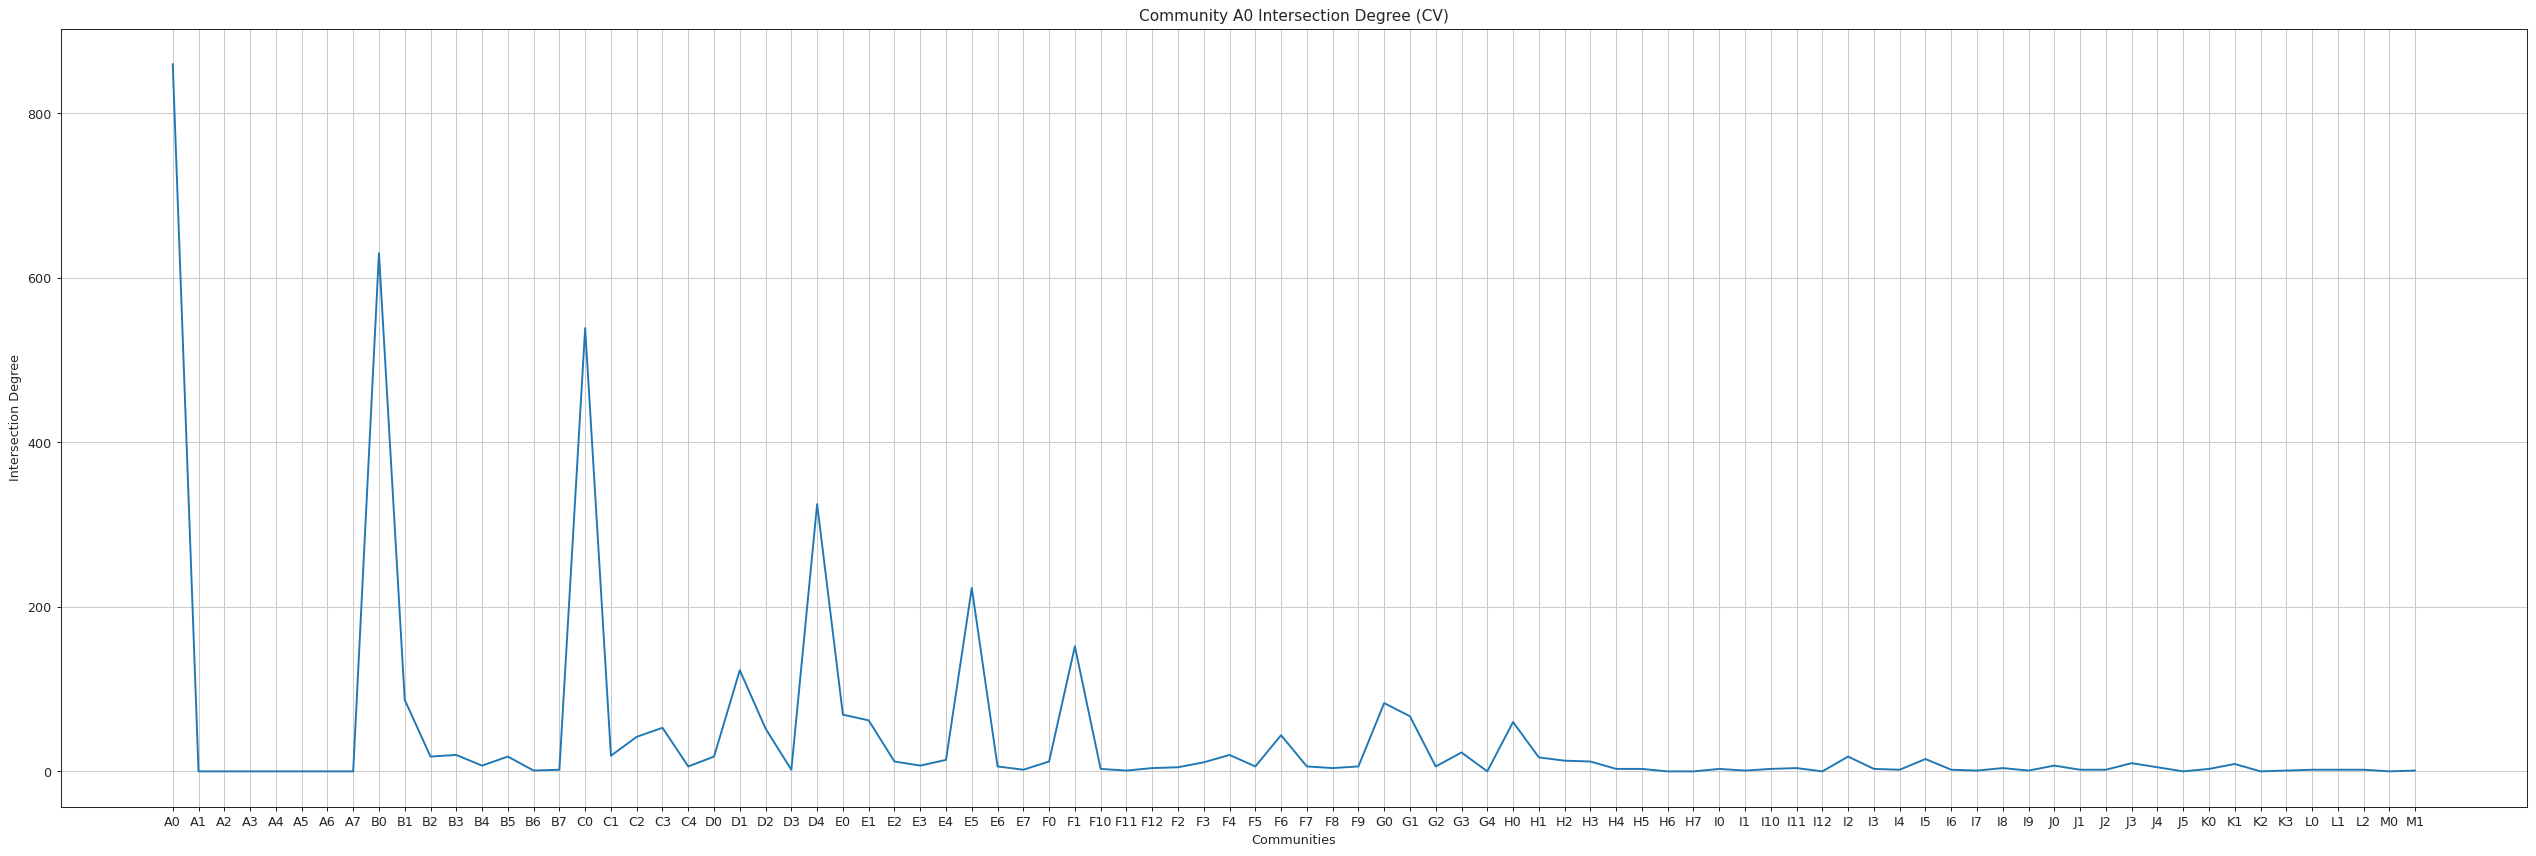

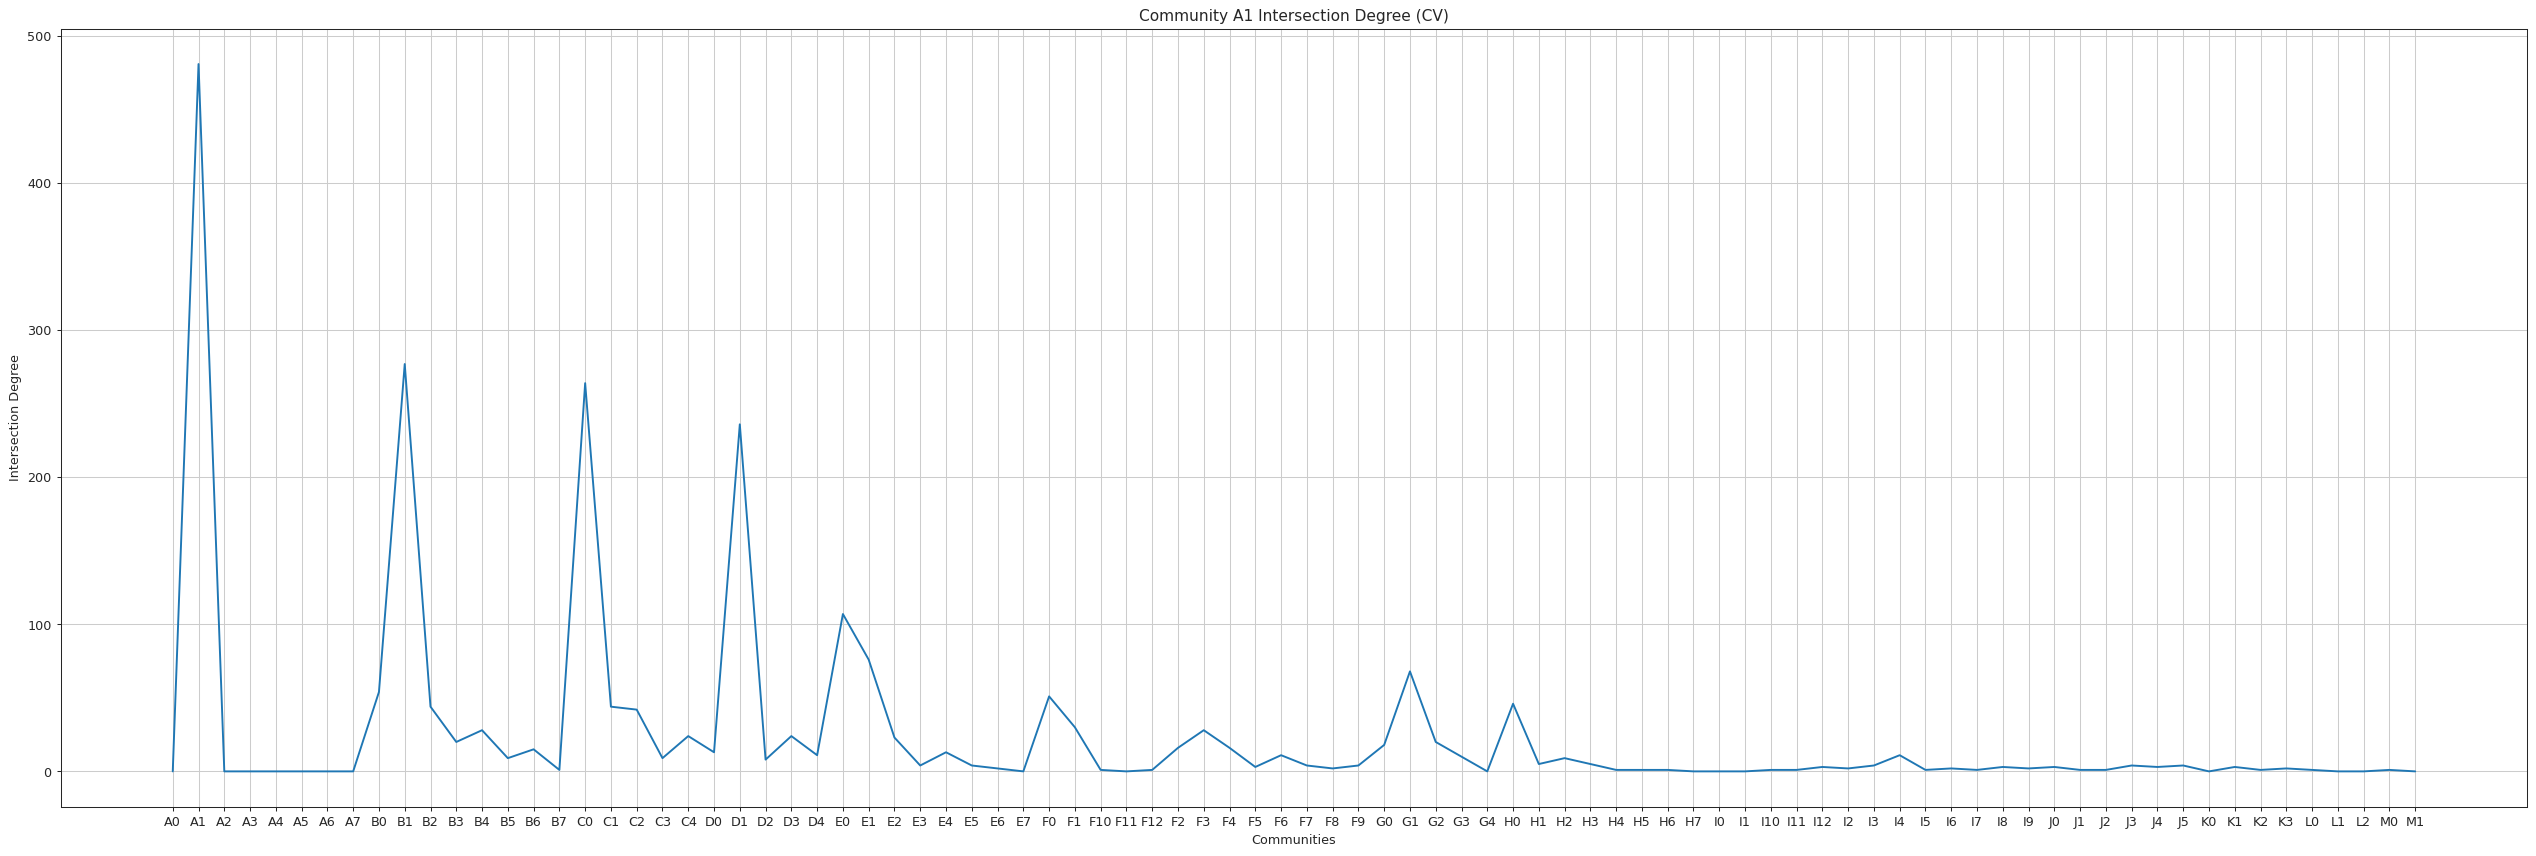

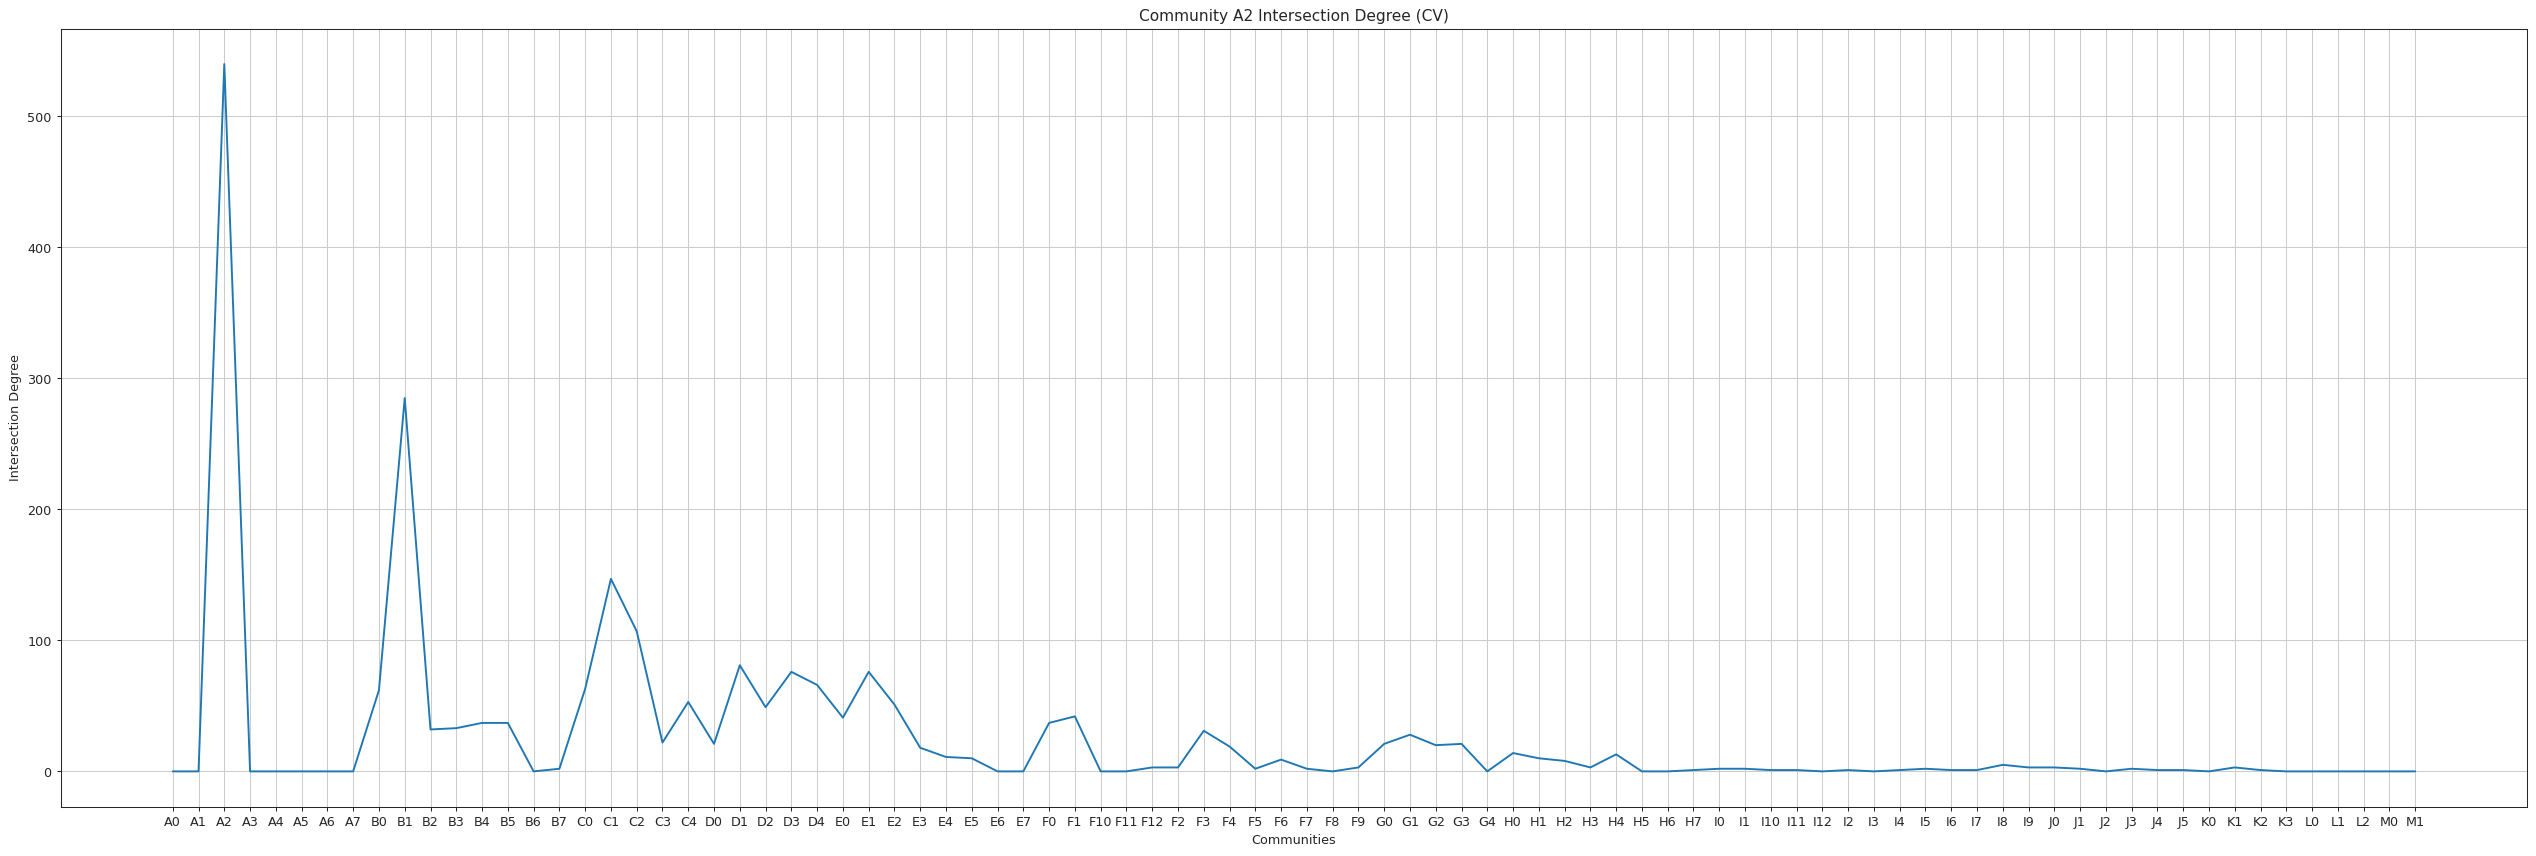

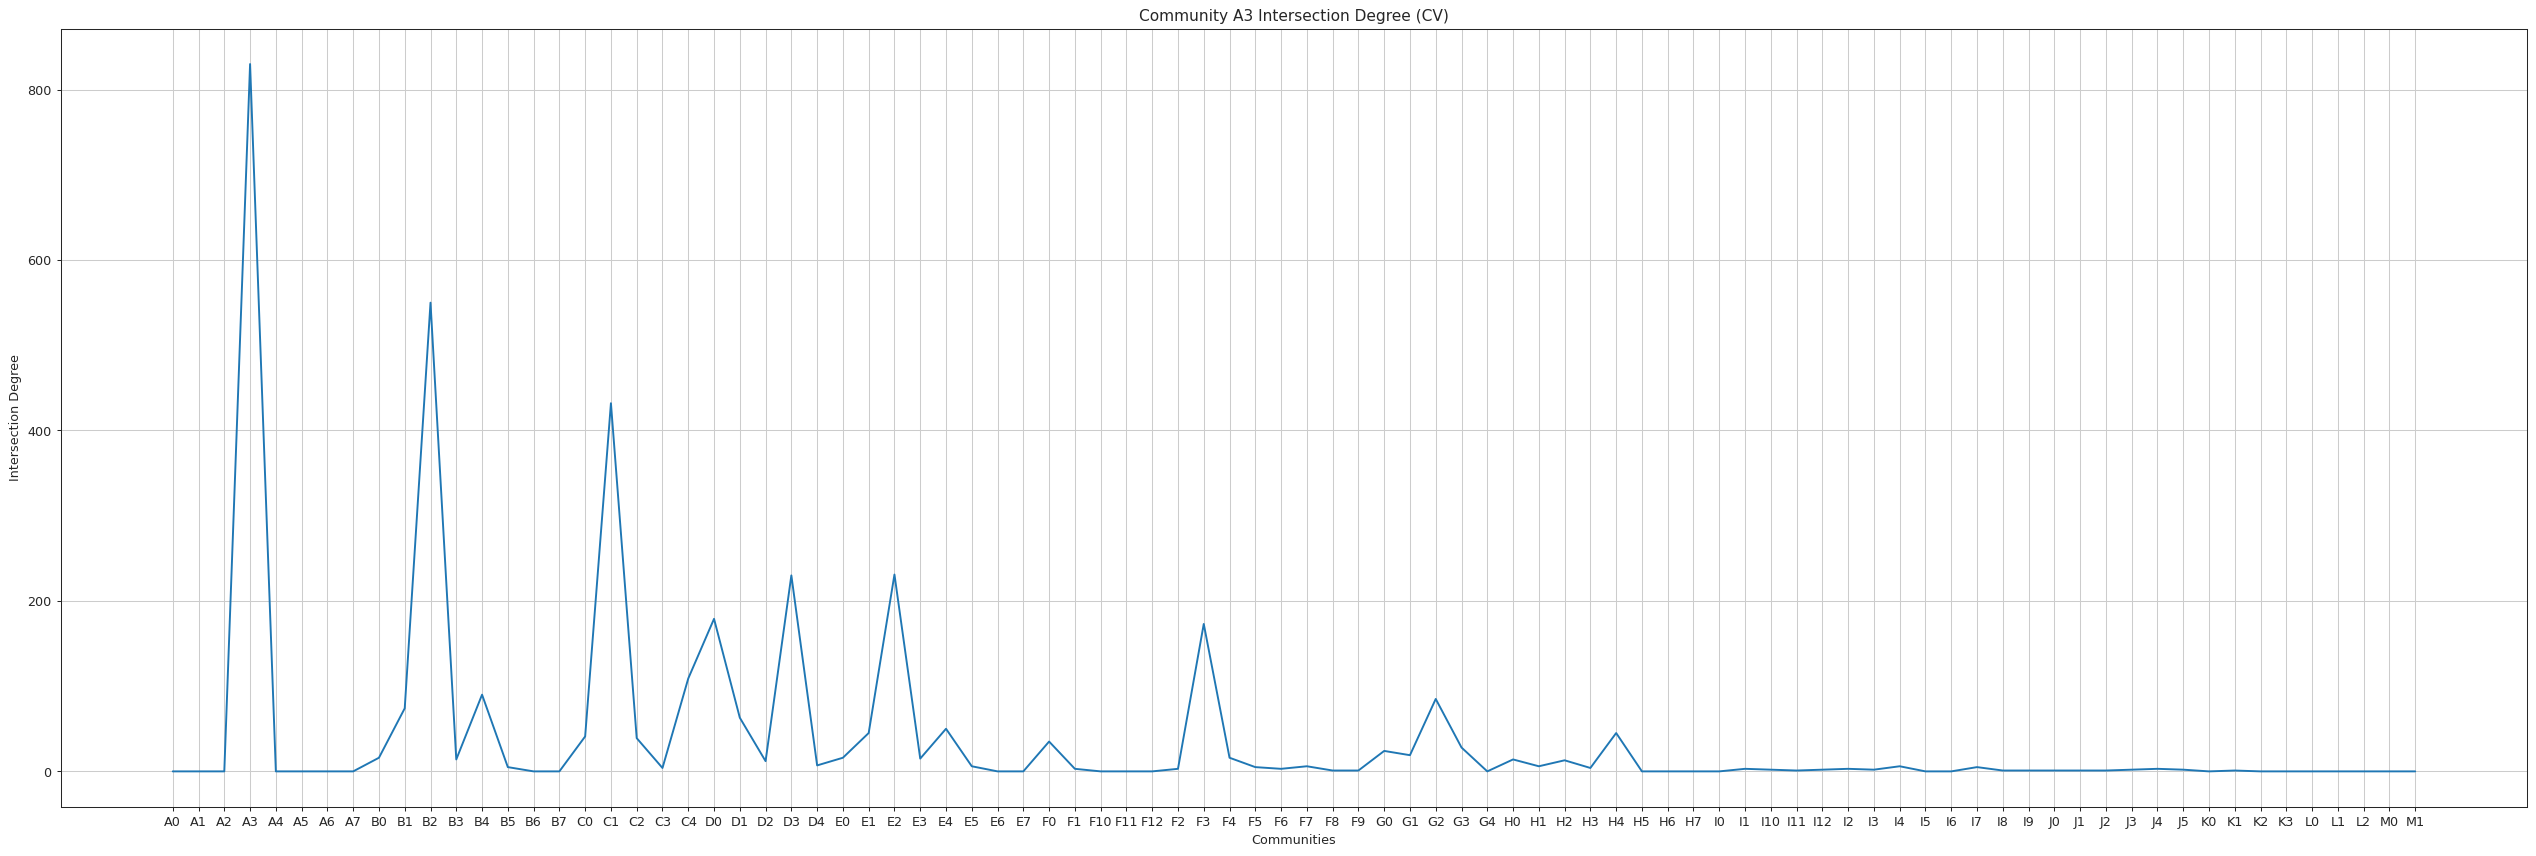

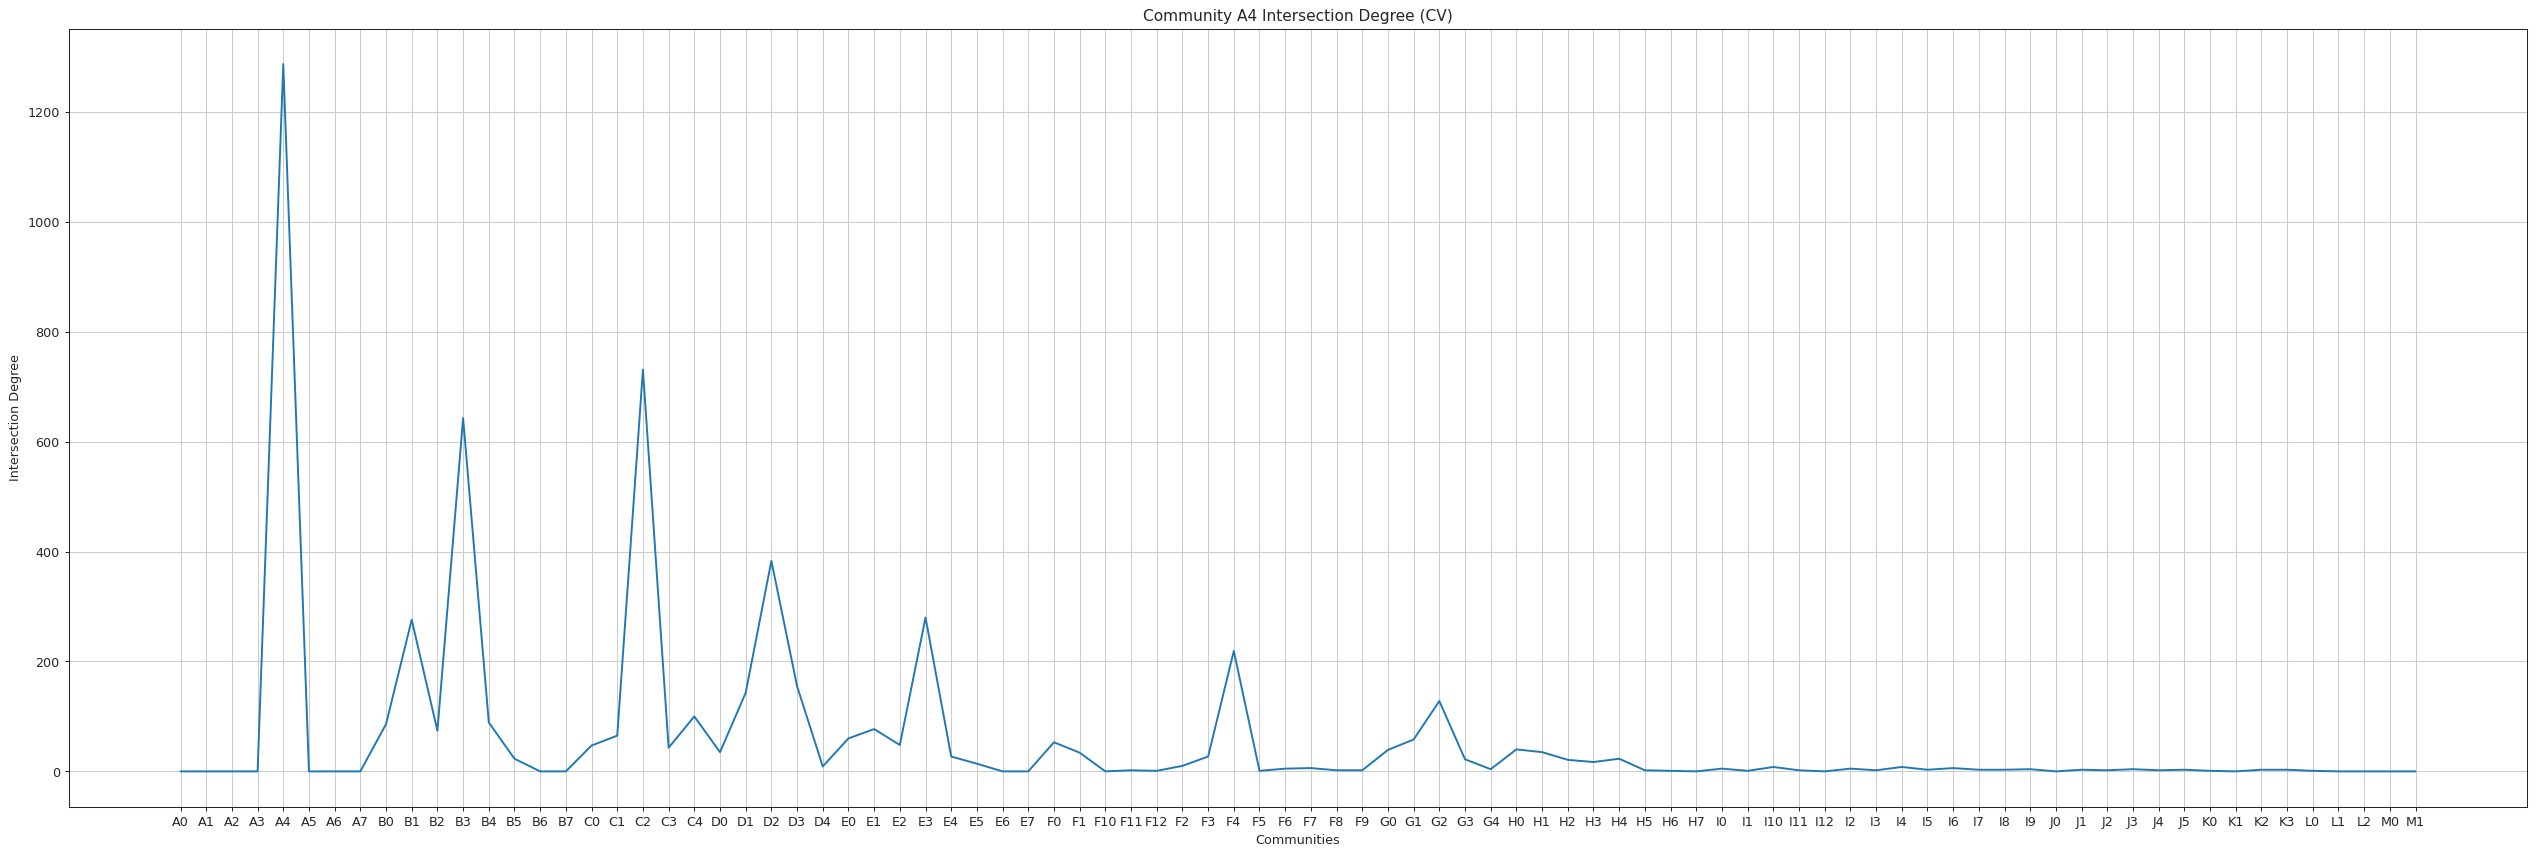

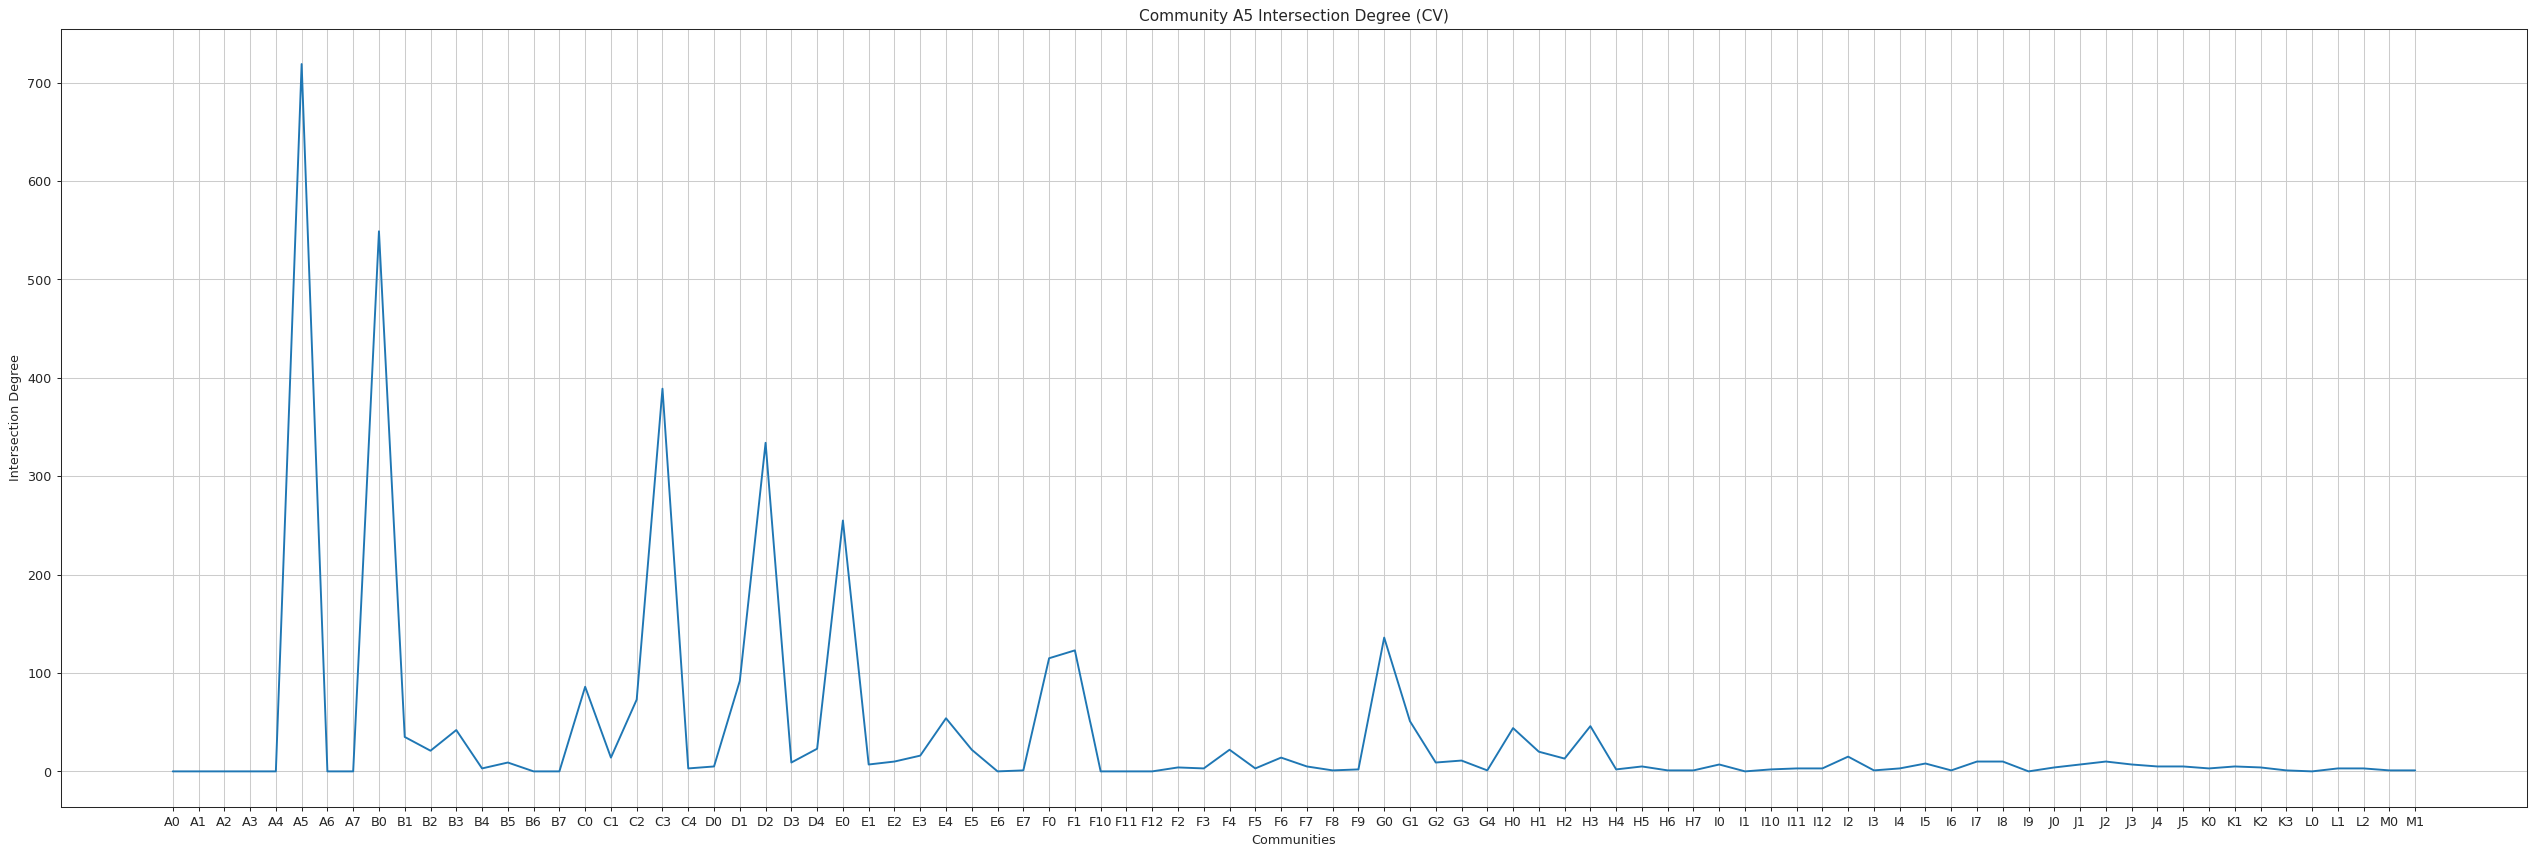

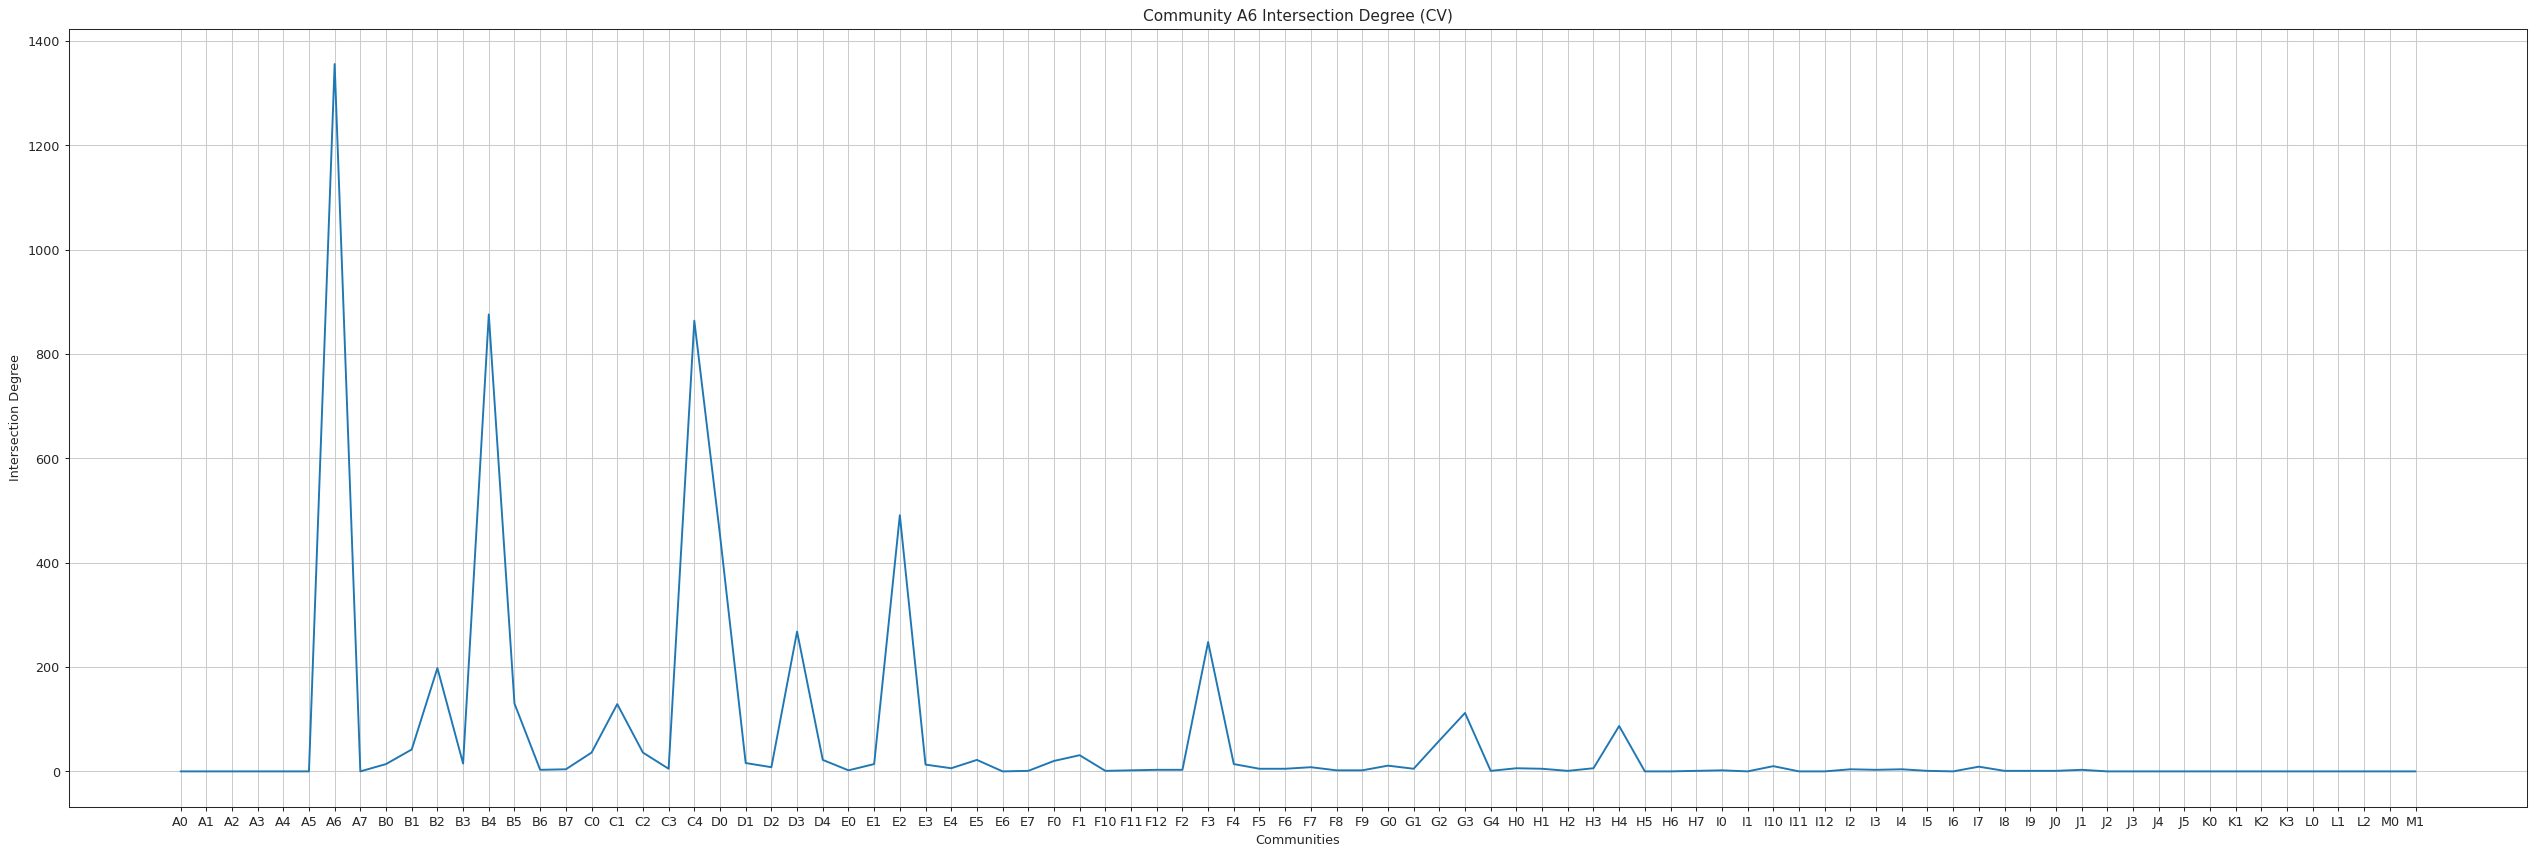

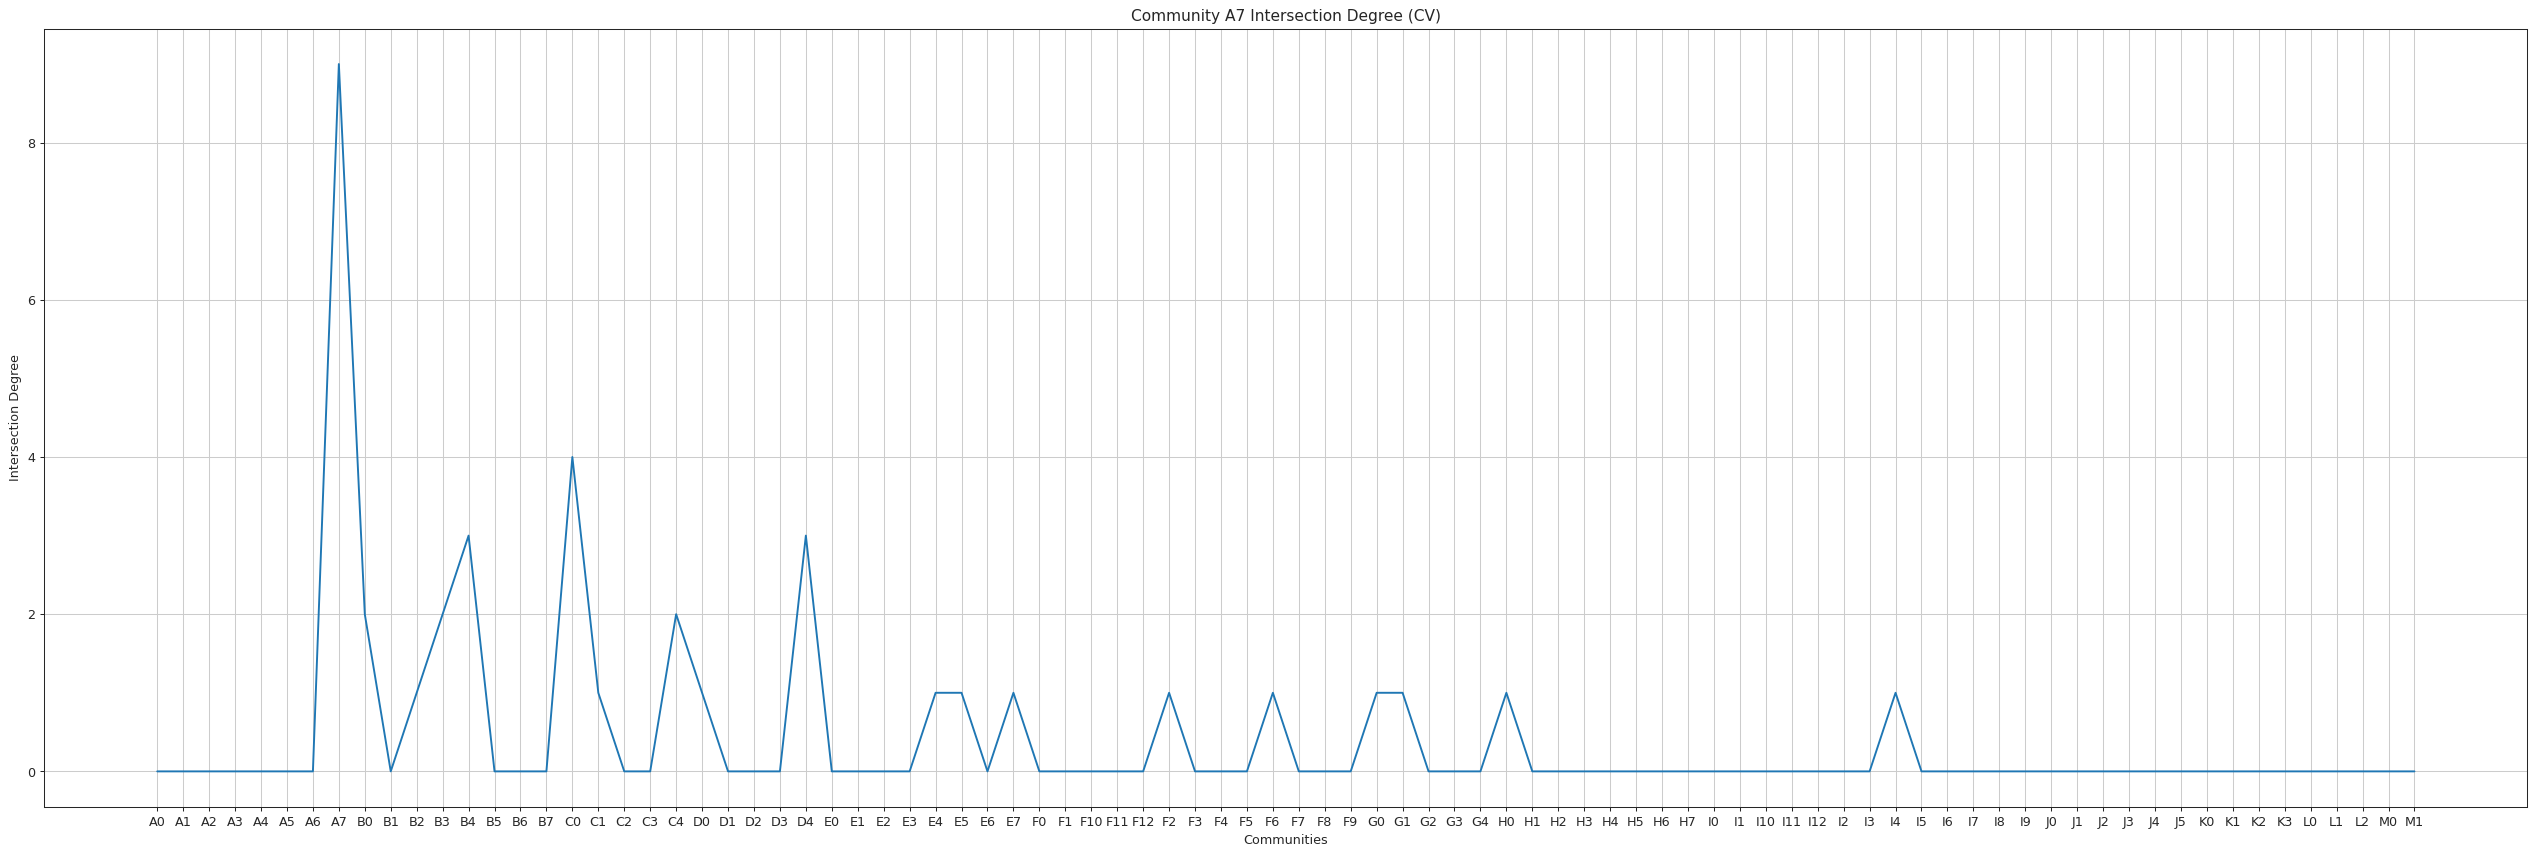

In [ ]:
aClusters = [0,1,2,3,4,5,6,7]
my_dpi = 92
sns.set_style("ticks")

path_results = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/" + approach + "/Comm_Analysis_Results/Intersection_Degree_Figures/"

for index in range(0,len(aClusters)):
  cluster = aClusters[index]
  colIndex = "A" + str(cluster)
  DF = degreeDF[colIndex]
  #DF = DF.sort_values(axis=0,ascending=False)
  #DF.to_csv(approach + "_Community_" + colIndex "_Intersection_Degree.csv")
  #print(DF)
  fig = plt.figure(figsize=(2500/my_dpi,800/my_dpi),dpi=my_dpi)
  plt.plot(DF)
  plt.subplots_adjust(wspace=0, hspace=1)
  fig.tight_layout(pad=0)# If ignored, it's possible to define space between subplots
  plt.grid()
  plt.title("Community " + colIndex + " Intersection Degree (CV)")
  plt.xlabel("Communities") 
  plt.ylabel("Intersection Degree") 
  plt.show()
  fig.savefig(path_results + "Community_" + colIndex + "_Intersection_Degree",dpi=my_dpi * 10, bbox_inches='tight')

# Number of articles per community

In [ ]:
filename = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/Communities_per_year/2020_Communities.csv"
DF = pd.read_csv(filename, index_col=0)
DF

,A0,A1,A2,A3,A4,A5,A6,A7
0,29784759.0,31256864.0,31703899.0,29962025.0,29999567.0,25527636.0,30988201.0,27463843.0
1,30268923.0,26391203.0,28917698.0,30501515.0,29897426.0,29675882.0,30004604.0,26033217.0
2,31467291.0,25355371.0,25432770.0,26228398.0,24875392.0,29520641.0,29931116.0,29930399.0
3,31806491.0,30014279.0,28859565.0,26212146.0,26921715.0,30332613.0,28971010.0,32459551.0
4,30201841.0,27865786.0,30479137.0,31294921.0,30663853.0,30483069.0,31586117.0,30283341.0
...,...,...,...,...,...,...,...,...
1351,NaN,NaN,NaN,NaN,NaN,NaN,24792358.0,NaN
1352,NaN,NaN,NaN,NaN,NaN,NaN,24989351.0,NaN
1353,NaN,NaN,NaN,NaN,NaN,NaN,24860494.0,NaN
1354,NaN,NaN,NaN,NaN,NaN,NaN,24719857.0,NaN


In [ ]:
headers_list = list(DF.columns.values)
set_list = []
for index in range(0,len(headers_list)):
  header = headers_list[index]
  tempLst = list(DF[header].values) # temp list for that comm
  tempLst = [x for x in tempLst if str(x) != 'nan'] # clean nan
  setAux = len(tempLst)
  set_list.append(setAux)
print(set_list)

[860, 481, 540, 830, 1287, 719, 1356, 9]


In [ ]:
# Corroborar
l = list(DF['A0'].values)
l = [x for x in l if str(x) != 'nan'] # clean nan
print(len(l))

860


# 5.1) Comm, Mod and new art. / year

In [ ]:
# Directories
path_nodes = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/Nodes_IDs_Lists"
nodes_filenames = os.listdir(path_nodes)
nodes_filenames = [x for x in nodes_filenames if ".ipynb_checkpoints" not in x]
nodes_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))),reverse = True)
nodes_filenames


['2020_Nodes_IDs_List.pkl',
 '2019_Nodes_IDs_List.pkl',
 '2018_Nodes_IDs_List.pkl',
 '2017_Nodes_IDs_List.pkl',
 '2016_Nodes_IDs_List.pkl',
 '2015_Nodes_IDs_List.pkl',
 '2014_Nodes_IDs_List.pkl',
 '2013_Nodes_IDs_List.pkl',
 '2012_Nodes_IDs_List.pkl',
 '2011_Nodes_IDs_List.pkl',
 '2010_Nodes_IDs_List.pkl',
 '2009_Nodes_IDs_List.pkl',
 '2008_Nodes_IDs_List.pkl']

In [ ]:
# Directories
path_clusterings = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/Clusterings"
clusterings_filenames = os.listdir(path_clusterings)
clusterings_filenames = [x for x in clusterings_filenames if ".ipynb_checkpoints" not in x]
clusterings_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))),reverse = True)
clusterings_filenames


['2020_Clustering.pkl',
 '2019_Clustering.pkl',
 '2018_Clustering.pkl',
 '2017_Clustering.pkl',
 '2016_Clustering.pkl',
 '2015_Clustering.pkl',
 '2014_Clustering.pkl',
 '2013_Clustering.pkl',
 '2012_Clustering.pkl',
 '2011_Clustering.pkl',
 '2010_Clustering.pkl',
 '2009_Clustering.pkl',
 '2008_Clustering.pkl']

In [ ]:
year_list = [2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020]
year_list.sort(reverse = True)
year_list

[2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010, 2009, 2008]

In [ ]:
comm_per_year = []
modularity_per_year = []
for index in range(0,len(nodes_filenames)):
  # Load nodes IDs
  nodes_filename = path_nodes + "/" + nodes_filenames[index]
  with open(nodes_filename, 'rb') as f:
    nodes_list = pickle.load(f)
  # Load clusterings
  clusterings_filename = path_clusterings + "/" + clusterings_filenames[index]
  with open(clusterings_filename, 'rb') as f:
    clustering = pickle.load(f)
  # Number of communities / year
  total_comm = len(nodes_list)
  comm_per_year.append(total_comm)
  # Modularity / year
  modularity = clustering.modularity
  modularity_per_year.append(modularity)
dic = {'year': year_list, 'communities': comm_per_year, 'modularity':modularity_per_year}
DF = pd.DataFrame(dic)
DF

,year,communities,modularity
0,2020,8,0.547922
1,2019,8,0.517379
2,2018,5,0.509566
3,2017,5,0.471487
4,2016,8,0.479641
5,2015,13,0.460395
6,2014,5,0.350708
7,2013,8,0.355238
8,2012,13,0.556590
9,2011,6,0.541016


In [ ]:
path_results = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/"
DF.to_csv(path_results + "Comm&Modularity_per_year.csv")

# Heatmap (topic probability distribution)

In [ ]:
filename = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/LDA_Results/Doc_Topic_Matrices/2020_Topic_Probability.csv"
Topic_Information = pd.read_csv(filename, header=None)
Topic_Information.iloc[:,0]

0       0.000120
1       0.000381
2       0.000192
3       0.000284
4       0.000164
          ...   
6077    0.000194
6078    0.000200
6079    0.000212
6080    0.000192
6081    0.000207
Name: 0, Length: 6082, dtype: float64

AttributeError: ignored

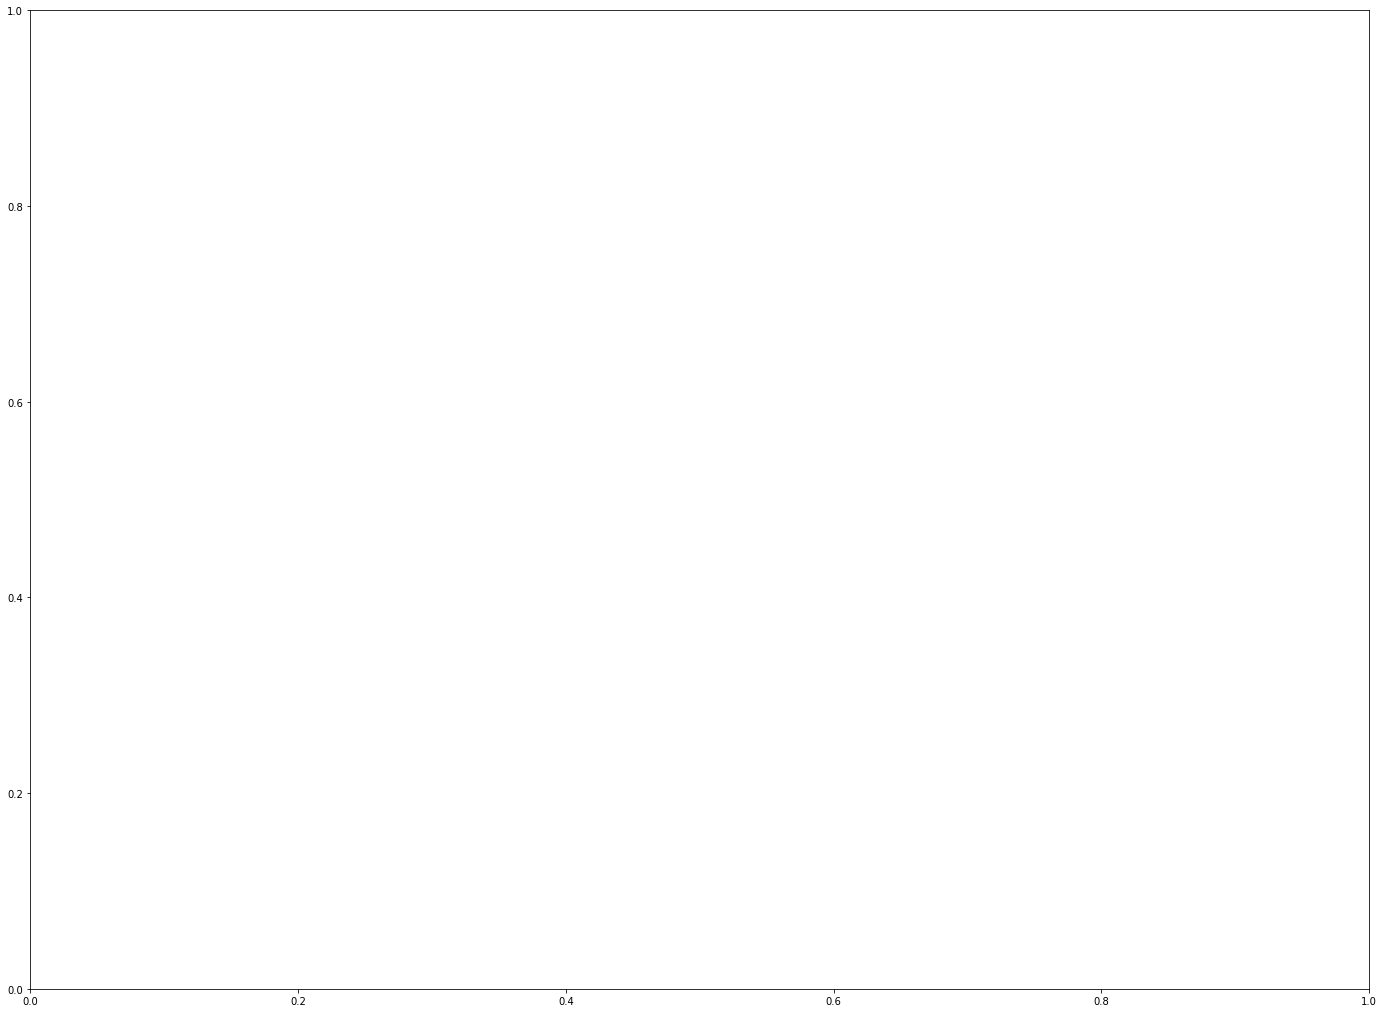

In [ ]:
fig, ax = plt.subplots(figsize=(24, 18))

# get the correlation coefficient between the different columns
corr = Topic_Information.iloc[:, 0:].corr()
arr_corr = corr.as_matrix()
# mask out the top triangle
arr_corr[np.triu_indices_from(arr_corr)] = np.nan

hm = sns.heatmap(arr_corr, cbar=True, vmin=-0.5, vmax=0.5,
                 fmt='.2f', annot_kws={'size': 3}, annot=True, 
                 square=True, cmap=plt.cm.Blues)

ticks = np.arange(corr.shape[0]) + 0.5
ax.set_xticks(ticks)
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(ticks)
ax.set_yticklabels(corr.index, rotation=360, fontsize=8)

ax.set_title('correlation matrix')
plt.tight_layout()
#plt.savefig("corr_matrix_incl_anno_double.png", dpi=300)

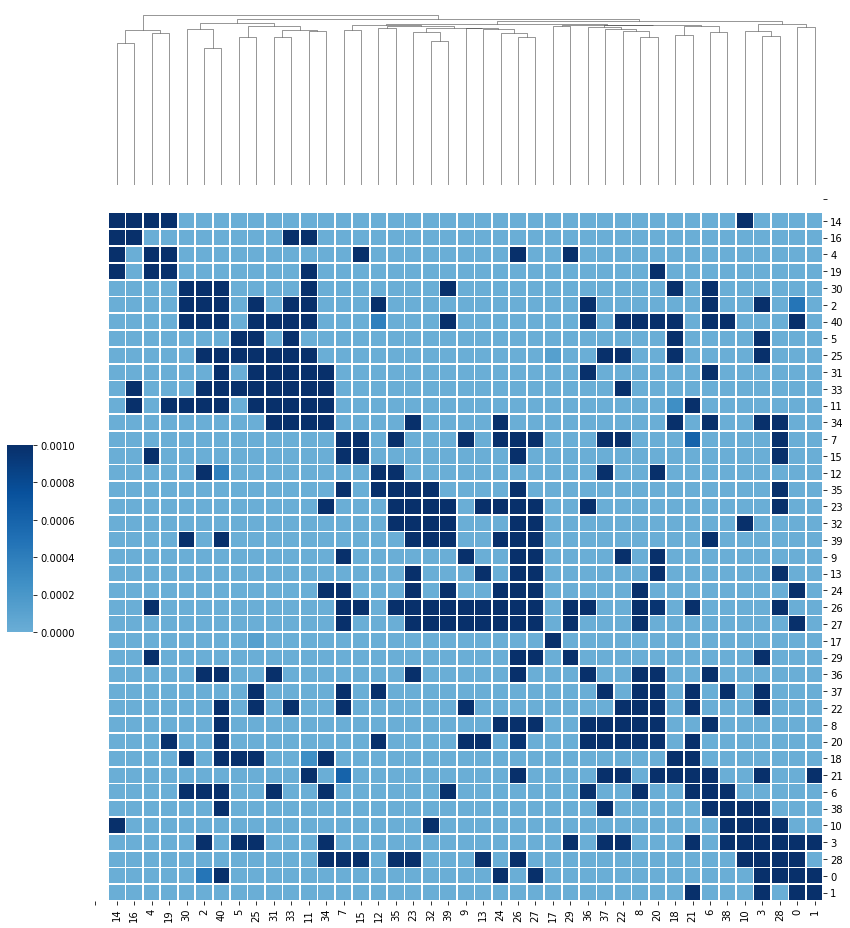

In [ ]:
used_networks = [40, 5, 30, 7, 14, 20, 45, 17]

# Create a categorical palette to identify the networks
network_pal = sns.husl_palette(8, s=.45)
network_lut = dict(zip(map(str, used_networks), network_pal))

# Convert the palette to vectors that will be drawn on the side of the matrix
networks = Topic_Information.columns.values
network_colors = pd.Series(networks, index=Topic_Information.columns).map(network_lut)

# Draw the full plot
g = sns.clustermap(Topic_Information.corr(), center=0, cmap="Blues",
                   row_colors=network_colors, col_colors=network_colors,
                   dendrogram_ratio=(.1, .2),
                   vmin=0, vmax=0.001,
                   cbar_pos=(.02, .32, .03, .2),
                   linewidths=.75, figsize=(12, 13))

g.ax_row_dendrogram.remove()

# LDA Topics analysis

In [ ]:
# Directories
path_lda = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/LDA_Results/Doc_Topic_Matrices"
lda_filenames = os.listdir(path_lda)
lda_filenames = [x for x in lda_filenames if ".ipynb_checkpoints" not in x]
lda_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))),reverse = False)
lda_filenames

['2005_Topic_Probability.csv',
 '2008_Topic_Probability.csv',
 '2009_Topic_Probability.csv',
 '2010_Topic_Probability.csv',
 '2011_Topic_Probability.csv',
 '2012_Topic_Probability.csv',
 '2013_Topic_Probability.csv',
 '2014_Topic_Probability.csv',
 '2015_Topic_Probability.csv',
 '2016_Topic_Probability.csv',
 '2017_Topic_Probability.csv',
 '2018_Topic_Probability.csv',
 '2019_Topic_Probability.csv',
 '2020_Topic_Probability.csv']

In [ ]:
#topic_list = list(np.arange(0,41,1))
path_results = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/LDA_Results/Topic_Mean_Score/"
year_list = [2005,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020]

for index in range(0,len(lda_filenames)):
  filename = path_lda + "/" + lda_filenames[index]
  Topic_Information = pd.read_csv(filename, header=None)
  topic_list = list(Topic_Information.columns.values)
  avg_list = []
  for item in range(0,len(topic_list)):
    topic = topic_list[item]
    avg = Topic_Information[topic].mean()
    avg_list.append(avg)
  dic = {"topic": topic_list, "mean": avg_list}
  df = pd.DataFrame(dic)
  year = year_list[index]
  df.to_csv(path_results + str(year) + "_Topic_Mean_Score.csv")

In [ ]:
# Directories
path_lda = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/LDA_Results/Topic_Mean_Score"
lda_filenames = os.listdir(path_lda)
lda_filenames = [x for x in lda_filenames if ".ipynb_checkpoints" not in x]
lda_filenames.sort(key=lambda x: int(''.join(filter(str.isdigit, x))),reverse = False)
lda_filenames

['2005_Topic_Mean_Score.csv',
 '2008_Topic_Mean_Score.csv',
 '2009_Topic_Mean_Score.csv',
 '2010_Topic_Mean_Score.csv',
 '2011_Topic_Mean_Score.csv',
 '2012_Topic_Mean_Score.csv',
 '2013_Topic_Mean_Score.csv',
 '2014_Topic_Mean_Score.csv',
 '2015_Topic_Mean_Score.csv',
 '2016_Topic_Mean_Score.csv',
 '2017_Topic_Mean_Score.csv',
 '2018_Topic_Mean_Score.csv',
 '2019_Topic_Mean_Score.csv',
 '2020_Topic_Mean_Score.csv']

In [ ]:
topics = []
mean = []
for index in range(0,len(lda_filenames)):
  filename = path_lda + "/" + lda_filenames[index]
  DF = pd.read_csv(filename, index_col=0)
  year = year_list[index]
  print("Year " + str(year))
  topic = DF["mean"].idxmax()
  avg_score = DF["mean"].max()
  print(DF.iloc[topic])
  topics.append(topic)
  mean.append(avg_score)

Year 2005
topic    0.00000
mean     0.98489
Name: 0, dtype: float64
Year 2008
topic    3.000000
mean     0.492924
Name: 3, dtype: float64
Year 2009
topic    5.000000
mean     0.354637
Name: 5, dtype: float64
Year 2010
topic    20.000000
mean      0.143291
Name: 20, dtype: float64
Year 2011
topic    15.000000
mean      0.126881
Name: 15, dtype: float64
Year 2012
topic    40.000000
mean      0.054029
Name: 40, dtype: float64
Year 2013
topic    16.000000
mean      0.135603
Name: 16, dtype: float64
Year 2014
topic    30.000000
mean      0.181754
Name: 30, dtype: float64
Year 2015
topic    27.000000
mean      0.152625
Name: 27, dtype: float64
Year 2016
topic    25.000000
mean      0.116386
Name: 25, dtype: float64
Year 2017
topic    0.000000
mean     0.134298
Name: 0, dtype: float64
Year 2018
topic    38.000000
mean      0.136568
Name: 38, dtype: float64
Year 2019
topic    40.000000
mean      0.120553
Name: 40, dtype: float64
Year 2020
topic    40.00000
mean      0.08423
Name: 40, dtype: fl

In [ ]:
dic = {"year": year_list, "topic": topics, "mean": mean}
DataFrame = pd.DataFrame(dic)
DataFrame.to_csv("Topics_Max_Mean_Score.csv")

# Heatmap (JS)

In [ ]:
# Import data
matrix = np.loadtxt("/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Stop_Fixed/JS_Results/JS_49_Topics_2020.txt", delimiter = ',')
matrix[np.isnan(matrix)] = 0

In [ ]:
fig, ax = plt.subplots(figsize=(24, 18))

hm = sns.heatmap(matrix, cbar=True, vmin=-0.5, vmax=0.5,
                 fmt='.2f', annot_kws={'size': 3}, annot=True, 
                 square=True, cmap=plt.cm.Blues)

ticks = np.arange(corr.shape[0]) + 0.5
ax.set_xticks(ticks)
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(ticks)
ax.set_yticklabels(corr.index, rotation=360, fontsize=8)

ax.set_title('correlation matrix')
plt.tight_layout()
plt.savefig("corr_matrix_incl_anno_double.png", dpi=300)

# Heatmap attemps

In [ ]:
# Import data
matrix = np.loadtxt("/content/drive/MyDrive/semantic_browser/NLP_Pubmed/Connectomics/Year_2011/Results/With_Stopwords/JS_49_Topics_2011.txt", delimiter = ',')
matrix[np.isnan(matrix)] = 0

In [ ]:
matrix.shape

(117, 117)

In [ ]:
matrix_corr = np.corrcoef(matrix)

/usr/local/lib/python3.7/dist-packages/seaborn/matrix.py:649: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



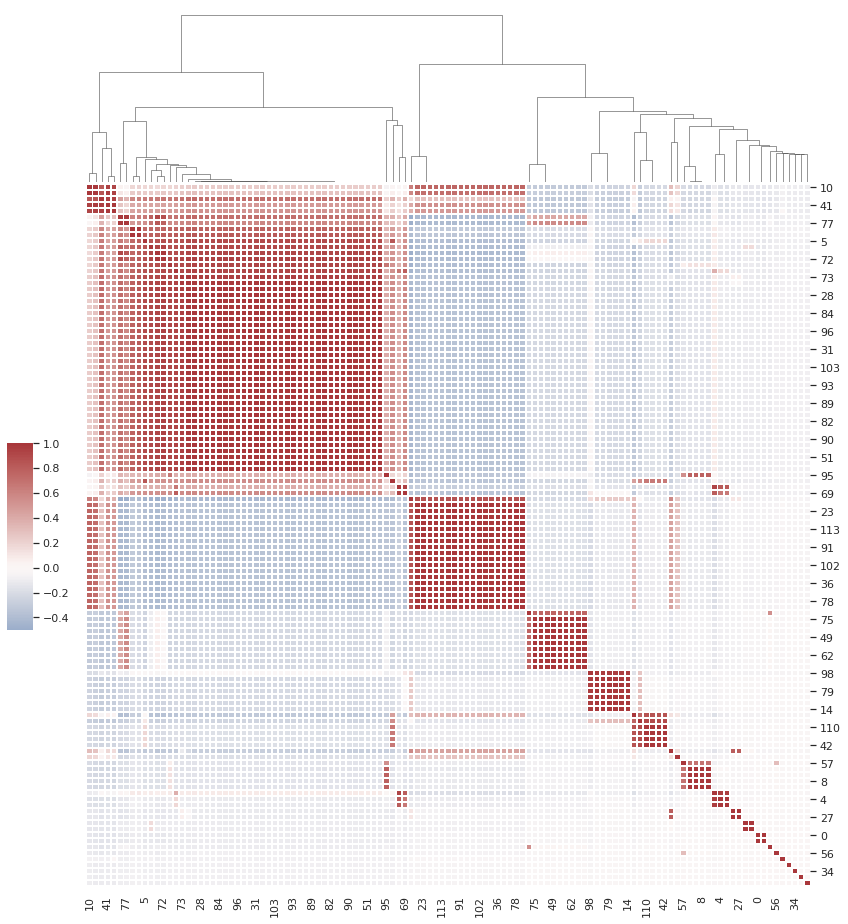

In [ ]:
# Draw the full plot
g = sns.clustermap(matrix_corr, center=0, cmap="vlag",
                   #row_colors=network_colors, col_colors=network_colors,
                   dendrogram_ratio=(.1, .2),
                   cbar_pos=(.02, .32, .03, .2),
                   linewidths=.75, figsize=(12, 13))

g.ax_row_dendrogram.remove()

# Para el row/column color, hacer el DF y en una columna especificar el #cluster correspondiente

920
network           1                     2  ...         17                       
node              1                     1  ...          3                      4
hemi             lh         rh         lh  ...         lh          rh         lh
0         56.055744  92.031036   3.391576  ... -10.520872  120.490463 -39.686432
1         55.547253  43.690075 -65.495987  ... -39.607521   24.764011 -36.771008
2         60.997768  63.438793 -51.108582  ...  12.985169  -75.027451   6.434262
3         18.514868  12.657158 -34.576603  ... -15.819172  -37.361431  -4.650954
4         -2.527392 -63.104668 -13.814151  ...   5.453649    5.169828  87.809135
..              ...        ...        ...  ...        ...         ...        ...
915       -7.429513  -4.813219  -3.670537  ...  22.893030   48.274380  76.228455
916      -33.554138 -38.605621 -25.664803  ...  24.974548   51.972153  64.538788
917      -78.539566 -74.197189 -54.041595  ...  66.994400   81.539246  64.969772
918     -103.235825 -98.

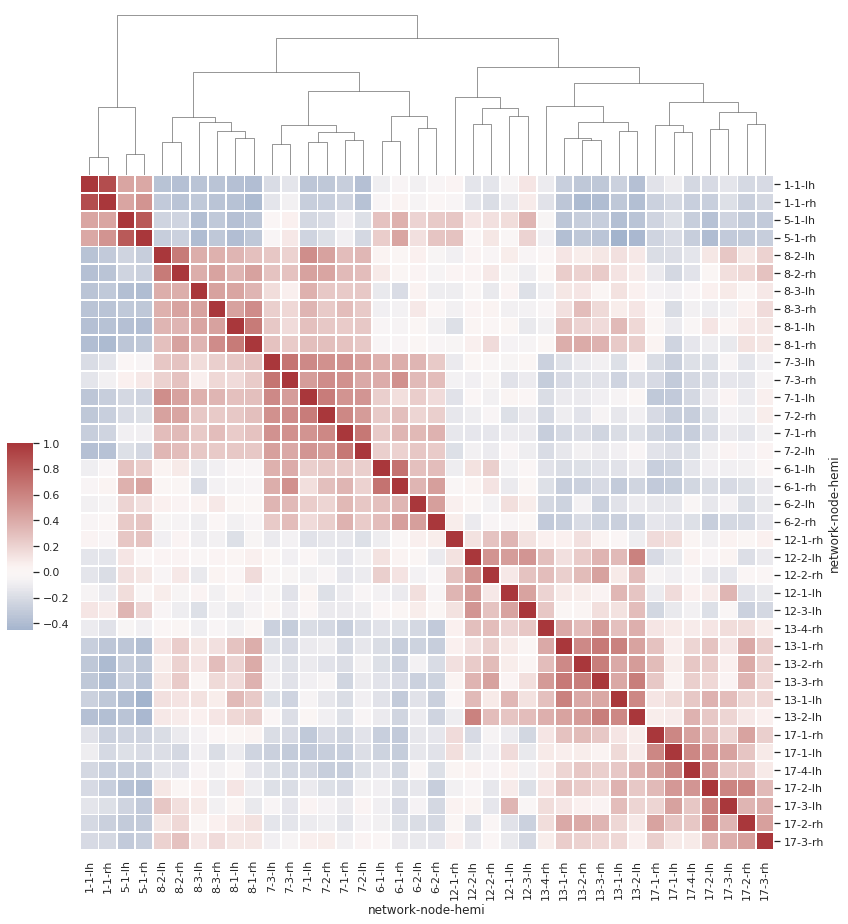

In [ ]:
import pandas as pd
import seaborn as sns
sns.set_theme()

# Load the brain networks example dataset
df = sns.load_dataset("brain_networks", header=[0, 1, 2], index_col=0)
print(len(df))
print(df)
# Select a subset of the networks
used_networks = [1, 5, 6, 7, 8, 12, 13, 17]
used_columns = (df.columns.get_level_values("network")
                          .astype(int)
                          .isin(used_networks))
df = df.loc[:, used_columns]

# Create a categorical palette to identify the networks
network_pal = sns.husl_palette(8, s=.45)
network_lut = dict(zip(map(str, used_networks), network_pal))

# Convert the palette to vectors that will be drawn on the side of the matrix
networks = df.columns.get_level_values("network")
network_colors = pd.Series(networks, index=df.columns).map(network_lut)

# Draw the full plot
g = sns.clustermap(df.corr(), center=0, cmap="vlag",
                   #row_colors=network_colors, col_colors=network_colors,
                   dendrogram_ratio=(.1, .2),
                   cbar_pos=(.02, .32, .03, .2),
                   linewidths=.75, figsize=(12, 13))

g.ax_row_dendrogram.remove()

# Wordcloud 

In [15]:
matrix = np.loadtxt("/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/LDA_Results/Topic_Lexica/2008_05_Topics_Lexica/Topic_3_words_wostopwords.txt", delimiter = '\t', dtype=str)
matrix

array([['human', '0.03088432033075254'],
       ['connection', '0.023529647577916382'],
       ['research', '0.023529647577916382'],
       ['brain', '0.023529253101946222'],
       ['circuits', '0.016176787457899917'],
       ['advances', '0.016176655462366626'],
       ['matrix', '0.016176619792061732'],
       ['currently', '0.016176615280433668'],
       ['anatomical', '0.01617609041442668'],
       ['exist', '0.008823588169393385'],
       ['potential', '0.008823588169393385'],
       ['discuss', '0.008823588169393385'],
       ['disseminate', '0.008823588169393385'],
       ['effort', '0.008823588169393385'],
       ['elements', '0.008823588169393385'],
       ['foundation', '0.008823588169393385'],
       ['linking', '0.008823588169393385'],
       ['species', '0.008823588169393385'],
       ['goal', '0.008823588169393385'],
       ['represents', '0.008823588169393385'],
       ['propose', '0.008823588169393385'],
       ['largely', '0.008823588169393385'],
       ['impact', '0.

In [16]:
words = list(matrix[:,0])
words

['human',
 'connection',
 'research',
 'brain',
 'circuits',
 'advances',
 'matrix',
 'currently',
 'anatomical',
 'exist',
 'potential',
 'discuss',
 'disseminate',
 'effort',
 'elements',
 'foundation',
 'linking',
 'species',
 'goal',
 'represents',
 'propose',
 'largely',
 'impact',
 'important',
 'indispensable',
 'databases',
 'neuronal',
 'information',
 'unknown',
 'coordinated',
 'achieve',
 'patterns',
 'connections',
 'collect',
 'neurobiological',
 'collations',
 'basic',
 'strategy',
 'applied',
 'archive',
 'neurological',
 'obstacles',
 'methods',
 'order',
 'lead',
 'opportunities',
 'learn',
 'limitations',
 'mental',
 'make',
 'present',
 'precise',
 'psychiatric',
 'account',
 'recent',
 'remain',
 'visualizing',
 'activities',
 'aim',
 'alterations',
 'area',
 'available',
 'behaviours',
 'central',
 'extremely',
 'difficult',
 'severe',
 'extract',
 'neuroscience',
 'review',
 'histological',
 'images',
 'diagrams',
 'largescale',
 'disorders',
 'connectome',
 'mam

In [17]:
probability = list(matrix[:,1])
probability

['0.03088432033075254',
 '0.023529647577916382',
 '0.023529647577916382',
 '0.023529253101946222',
 '0.016176787457899917',
 '0.016176655462366626',
 '0.016176619792061732',
 '0.016176615280433668',
 '0.01617609041442668',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '0.008823588169393385',
 '

In [18]:
dic = {'words':words,'probability':probability}
DF = pd.DataFrame(data=dic)
DF

,words,probability
0,human,0.03088432033075254
1,connection,0.023529647577916382
2,research,0.023529647577916382
3,brain,0.023529253101946222
4,circuits,0.016176787457899917
...,...,...
205,reveal,0.0014706074462579747
206,connectomes,0.0014706074462579747
207,axons,0.0014706074462579747
208,neurons,0.0014706074462579747


In [20]:
DF[["probability"]] = DF[["probability"]].apply(pd.to_numeric)
DF = DF.astype({"words": str, "probability": float})
DF

,words,probability
0,human,0.030884
1,connection,0.023530
2,research,0.023530
3,brain,0.023529
4,circuits,0.016177
...,...,...
205,reveal,0.001471
206,connectomes,0.001471
207,axons,0.001471
208,neurons,0.001471


In [21]:
data = DF.set_index('words').to_dict()['probability']

In [22]:
from wordcloud import WordCloud
from PIL import Image
mask = np.array(Image.open('/content/drive/MyDrive/semantic_browser/NLP_Pubmed/brain.png'))
wc = WordCloud( max_words=1000, background_color="white", colormap='winter',
               mask=mask, max_font_size=256, width=mask.shape[1],
               height=mask.shape[0]).generate_from_frequencies(data)

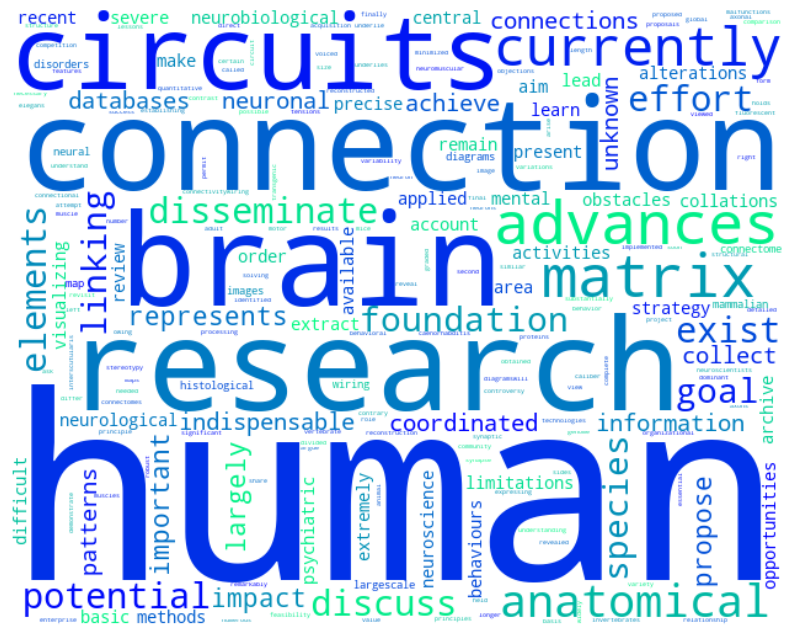

In [23]:
my_dpi = 92
fig = plt.figure(figsize=(1000/my_dpi,1000/my_dpi),dpi=my_dpi)

plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

fig.savefig('brain1',dpi=my_dpi * 10, bbox_inches='tight')
# como mejorar calidad de las wc?

# Attempts

In [ ]:
membership_vector = clusters.membership
print(len(membership_vector))
# This is wrong because the correspondance does not match (id-community id)
"""
names_vector = g.vs['name']
print(len(names_vector))
dic = {'IDs':names_vector,'2020_modules':membership_vector}
df = pd.DataFrame(data=dic,dtype=np.int)
print(df)
"""

6082
6082
           IDs  2020_modules
0     29784759             0
1     31256864             0
2     30268923             0
3     31703899             0
4     29962025             1
...        ...           ...
6077  24989351             1
6078  24860494             4
6079  24719857             1
6080  23585869             4
6081  22066005             3

[6082 rows x 2 columns]


In [ ]:
df.loc[df['2020_modules'] == 1]

,IDs,2020_modules
4,29962025,1
10,29999567,1
26,26228398,1
35,26212146,1
39,30988201,1
...,...,...
6063,28384269,1
6069,27872591,1
6075,24792358,1
6077,24989351,1


# JS

In [ ]:
# Data import
approach = "Stop_Fixed"
matrix = np.loadtxt("/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Stop_Fixed/JS_Results/JS_49_Topics_2020.txt", delimiter = ',')
matrix[np.isnan(matrix)] = 0

In [ ]:
matrix.shape

(6082, 6082)

# Graph plot

Reading package lists... Done
Building dependency tree       
Reading state information... Done
build-essential is already the newest version (12.4ubuntu1).
python-dev is already the newest version (2.7.15~rc1-1).
zlib1g-dev is already the newest version (1:1.2.11.dfsg-0ubuntu2).
zlib1g-dev set to manually installed.
libxml2 is already the newest version (2.9.4+dfsg1-6.1ubuntu1.4).
libxml2 set to manually installed.
libxml2-dev is already the newest version (2.9.4+dfsg1-6.1ubuntu1.4).
The following additional packages will be installed:
  libcairo-script-interpreter2 libpixman-1-dev libxcb-shm0-dev
Suggested packages:
  libcairo2-doc
The following NEW packages will be installed:
  libcairo-script-interpreter2 libcairo2-dev libpixman-1-dev libxcb-shm0-dev
0 upgraded, 4 newly installed, 0 to remove and 37 not upgraded.
Need to get 930 kB of archives.
After this operation, 3,986 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu bionic-updates/main amd64 libc

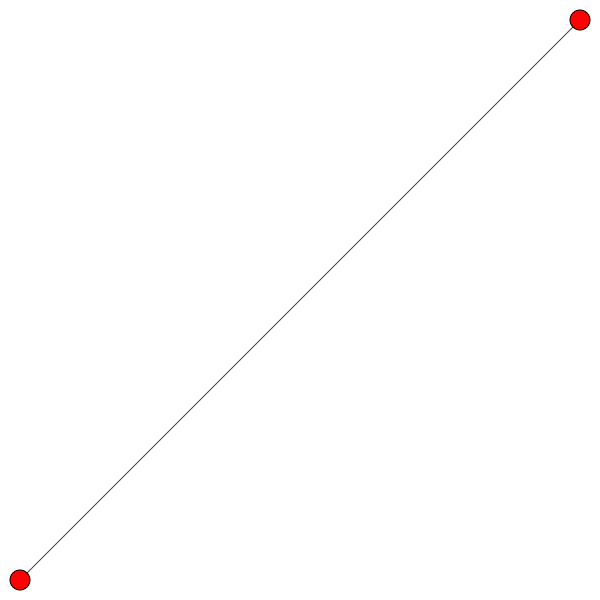

In [14]:
!sudo apt install build-essential python-dev libxml2 libxml2-dev zlib1g-dev libcairo2-dev
!pip install cairocffi python-igraph
import igraph as ig
g = ig.Graph(edges=[(0,1)])
ig.plot(g)

In [24]:
# Data import
filename = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Graph_Results/Graphs/2008_Graph_05_Topics.gml"
g = Graph.Load(filename, format='gml') # Reads graph

c_filename = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/Clusterings/2008_Clustering.pkl"
with open(c_filename, 'rb') as f:
    c = pickle.load(f)
print(c.summary)
#clustering = g.community_multilevel() # Applies community method

<bound method Clustering.summary of <igraph.clustering.VertexClustering object at 0x7fa9eb295150>>


In [25]:
layout = g.layout

In [26]:
pal = ig.drawing.colors.ClusterColoringPalette(len(c))
g.vs['color'] = pal.get_many(c.membership)
#g.vs['color'] = 'blue'

In [ ]:
color_list = g.vs['color']
names_list = g.vs['name']

membership_filename = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/Membership_Vectors/2020_Membership_Vector.pkl"
with open(membership_filename, 'rb') as f:
  membership_list = pickle.load(f)
membership_vector = flatten(membership_list)

nodes_filename = "/content/drive/MyDrive/semantic_browser/NLP_Pubmed_Database/Results/Clean_Variable/Comm_Analysis_Results/Nodes_IDs_Lists/2020_Nodes_IDs_List.pkl"
with open(nodes_filename, 'rb') as f:
  nodes_list = pickle.load(f)
nodes = flatten(nodes_list)

DF = pd.DataFrame(color_list, columns=["c1","c2","c3","c4"])
DF["names"] = names_list
#DF["membership"] = membership_vector
#DF["real_names"] = nodes
DF
#DF.to_csv("color_DF.csv")

,c1,c2,c3,c4,names
0,1.000000,0.000000,0.000000,1.0,29784759.0
1,0.000000,1.000000,0.000000,1.0,31256864.0
2,1.000000,0.000000,0.000000,1.0,30268923.0
3,0.000000,0.000000,1.000000,1.0,31703899.0
4,1.000000,1.000000,0.000000,1.0,29962025.0
...,...,...,...,...,...
6077,0.501961,0.501961,0.501961,1.0,24989351.0
6078,0.501961,0.501961,0.501961,1.0,24860494.0
6079,0.501961,0.501961,0.501961,1.0,24719857.0
6080,0.501961,0.501961,0.501961,1.0,23585869.0


In [ ]:
cosa = DF.groupby(["c1","c2","c3","c4"],as_index=False).size()
cosa

,c1,c2,c3,c4,size
0,0.000000,0.000000,1.000000,1.0,540
1,0.000000,1.000000,0.000000,1.0,481
2,0.000000,1.000000,1.000000,1.0,719
3,0.500000,0.000000,0.000000,1.0,9
4,0.501961,0.501961,0.501961,1.0,1356
5,1.000000,0.000000,0.000000,1.0,860
6,1.000000,0.000000,1.000000,1.0,1287
7,1.000000,1.000000,0.000000,1.0,830


In [ ]:
ig.drawing.colors.rgba_to_hsla(1,0,1,alpha=1)

(0.8333333333333334, 1.0, 0.5, 1.0)

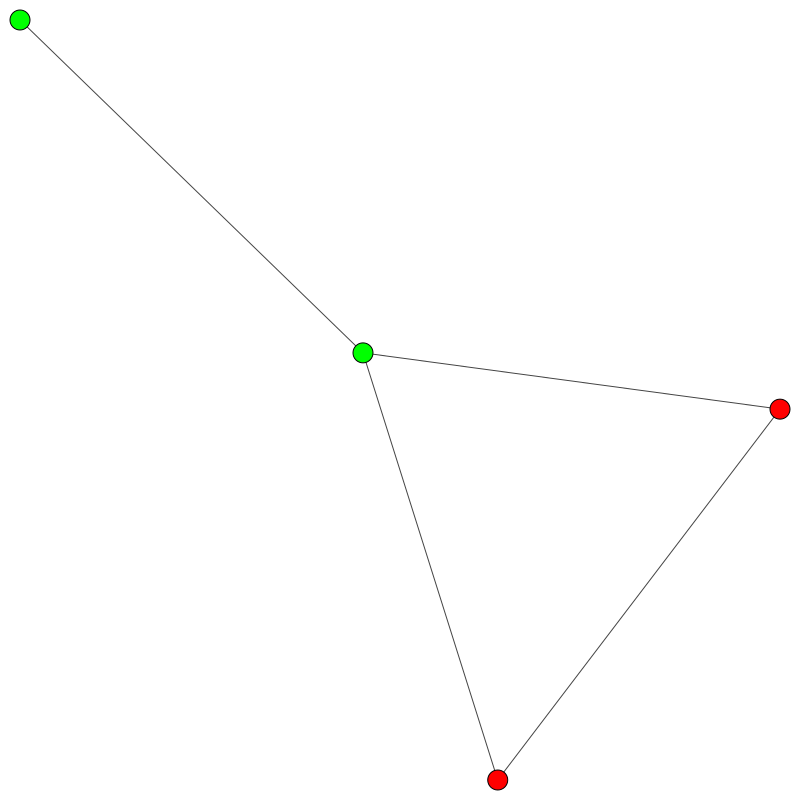

In [27]:
visual_style = {}
out_name = "graph08.png"# Set bbox and margin
visual_style["bbox"] = (800,800)
visual_style["edge_curved"] = False# Set the layout
my_layout = g.layout_lgl()
visual_style["layout"] = my_layout# Plot the graph
ig.plot(g, out_name, **visual_style)

In [ ]:
# plot communities without shaded regions
ig.plot(g,target='graph.png')